# CS3244 Group 17 Project: IMDb Spoiler Detection from Movie Reviews

This notebook focuses on the model-training stage for binary spoiler classification on IMDb reviews. It loads preprocessed artifact splits and precomputed feature sets to tune, train, and evaluate classifiers.

Workflow: setup and artifact loading, model training and hyperparameter tuning, model evaluation.

## 0. Setup 

In [21]:
# imports
import pandas as pd
import numpy as np
import joblib, pickle
import matplotlib.pyplot as plt
import gc
from pathlib import Path
from scipy import sparse
from sklearn import set_config
from sklearn.model_selection import ParameterSampler
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, fbeta_score, precision_score, recall_score, accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

# Force scikit-learn to use 1GB chunks instead of trying to process everything at once
set_config(working_memory=1024) 

In [3]:
# # Read review dataset
# df = pd.read_json("IMDB_reviews.json", lines=True)

## 2. Data Cleaning and Preprocessing
This section performs cleaning and preprocessing to build the master dataset used across all downstream modeling steps.

In [4]:
# # create master dataset
# df_master = df.copy()

In [5]:
# # Remove duplicate reviews which have different label assigned to the same text
# conflicts = df_master.groupby("review_text")["is_spoiler"].nunique()
# conflicts = conflicts[conflicts > 1].index

# df_master = df_master[~df_master["review_text"].isin(conflicts)]

# # Remove exact duplicate reviews to avoid redundancy and data leakage
# df_master = df_master.drop_duplicates(subset=["review_text"])

# # Remove extremely short reviews that are likely low-information or noisy
# df_master = df_master[df_master["review_text"].str.len() > 25]

# # Remove extremely long reviews that may distort feature distributions and increase computational cost
# df_master = df_master[df_master["review_text"].str.len() < 10000]

# # Add review length as a feature due to strong correlation with spoiler labels
# df_master["length"] = df_master["review_text"].str.len()

# # Reset index after row removals to keep the cleaned dataset tidy and consistent
# df_master = df_master.reset_index(drop=True)

In [6]:
# # Review date stored as object, convert to datetime
# df_master["review_date"] = pd.to_datetime(df_master["review_date"])

In [7]:
# # Basic data cleaning function
# def basic_clean(text):
#     text = str(text) # Forces text to be a String
#     text = html.unescape(text) # Converts HTML to normal text
#     text = unicodedata.normalize("NFKC", text) # Normalizes unicode into a consistent canonical form
#     text = re.sub(r"<[^>]+>", " ", text) # Removes HTML tags 
#     text = text.lower() # Converts all text to lowercase
#     text = re.sub(r"\s+", " ", text) # Collapses all whitespace into a single space
#     text = text.strip() # Removes whitespace in front and behind of text
#     return text

In [8]:
# # Clean "clean_text" in master dataframe
# df_master["clean_text"] = df_master["review_text"].apply(basic_clean)

## 3. Data Splitting
This notebook reuses the grouped movie-level train/test split and the artifact-specific train, validation, and fulltrain datasets created in the preprocessing notebook.
The commented cells below are kept only as reference for how those splits were originally constructed.

In [9]:
# # Function for splitting data into training and testing sets
# def group_data_split(df, group_col="movie_id", test_size=0.2, random_state=42):
#     """
#     Split a dataframe into train and test sets using group-based splitting.

#     Parameters
#     ----------
#     df : pandas.DataFrame
#         Input dataframe.
#     group_col : str, default="movie_id"
#         Column used to define groups that must not be split across train and test.
#     test_size : float, default=0.2
#         Proportion of groups to place in the test set.
#     random_state : int, default=42
#         Random seed for reproducibility.

#     Returns
#     -------
#     df_train : pandas.DataFrame
#         Training subset.
#     df_test : pandas.DataFrame
#         Test subset.
#     """
#     gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)

#     train_idx, test_idx = next(gss.split(df, groups=df[group_col]))

#     df_train = df.iloc[train_idx].reset_index(drop=True)
#     df_test = df.iloc[test_idx].reset_index(drop=True)

#     return df_train, df_test

In [10]:
# # Splitting data into training set and testing set (grouped by movie_id)
# df_train, df_test = group_data_split(
#     df_master, 
#     group_col="movie_id", 
#     test_size=0.2, 
#     random_state=42
# )

In [11]:
# # Create Stratified Group K-Fold splits on the training set
# N_SPLITS = 5
# CV_SEED = 42
# cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=CV_SEED)

# cv_splits = list(
#     cv.split(
#         df_train["clean_text"],
#         df_train["is_spoiler"],
#         groups=df_train["movie_id"],
#     )
# )
# print("Number of CV folds:", len(cv_splits))

## 1. Modeling Framework and Validation Policy

This section begins by loading the shared feature artifacts used throughout the model-development workflow, then fits a simple Logistic Regression baseline, uses validation-only threshold analysis to justify the threshold choice for that baseline, and finally applies the broader workflow across the remaining model families.

- Each artifact stream provides a train split for fitting and a validation split for model selection.
- Chosen hyperparameters are then retrained on the corresponding fulltrain split.
- The held-out df_test split is reserved for final evaluation in Section 5.

For each model family, the workflow is:
1. Load the relevant artifact split.
2. Train on the artifact-specific train split.
3. Select hyperparameters on the validation split when needed.
4. Refit on the corresponding fulltrain split.
5. Evaluate once on the held-out test split in Section 5.

### 1.1 Feature Artifact Loading

Run the next cell to load the two active artifact streams, `artifacts_1` and `artifacts_2`, into memory. TF-IDF and TF-IDF + lemmatization artifacts are stored at the top level of each artifact directory, while SBERT and RoBERTa artifacts are stored by split under `train_sub`, `train_full`, `val`, and `test`. Each split folder contains its own `bert_window_data.pkl` together with the corresponding `X_sbert.npy` and `X_roberta.npy` files.

In [22]:
ARTIFACT_DIRS = {
    "artifacts_1": Path("artifacts_1"),
    "artifacts_2": Path("artifacts_2"),
}

def _require(path: Path):
    return path


def _load_array(path: Path):
    return np.load(_require(path))


def _load_sparse_matrix(path: Path):
    return sparse.load_npz(_require(path))


def _load_optional_joblib(path: Path):
    return joblib.load(path) if path.exists() else None


def load_artifact_bundle(artifact_name: str):
    artifact_dir = ARTIFACT_DIRS[artifact_name]

    return {
        "artifact_dir": artifact_dir,
        "labels_train": _load_array(artifact_dir / "labels_train.npy"),
        "labels_val": _load_array(artifact_dir / "labels_val.npy"),
        "labels_test": _load_array(artifact_dir / "labels_test.npy"),
        "labels_fulltrain": _load_array(artifact_dir / "labels_fulltrain.npy"),
        "X_tfidf_train": _load_sparse_matrix(artifact_dir / "X_tfidf_train.npz"),
        "X_tfidf_val": _load_sparse_matrix(artifact_dir / "X_tfidf_val.npz"),
        "X_tfidf_test": _load_sparse_matrix(artifact_dir / "X_tfidf_test.npz"),
        "X_tfidf_fulltrain": _load_sparse_matrix(artifact_dir / "X_tfidf_fulltrain.npz"),
        "X_tfidf_test_fulltrain": _load_sparse_matrix(artifact_dir / "X_tfidf_test_fulltrain.npz"),
        "X_tfidf_lemma_train": _load_sparse_matrix(artifact_dir / "X_tfidf_lemma_train.npz"),
        "X_tfidf_lemma_val": _load_sparse_matrix(artifact_dir / "X_tfidf_lemma_val.npz"),
        "X_tfidf_lemma_test": _load_sparse_matrix(artifact_dir / "X_tfidf_lemma_test.npz"),
        "X_tfidf_lemma_fulltrain": _load_sparse_matrix(artifact_dir / "X_tfidf_lemma_fulltrain.npz"),
        "X_tfidf_lemma_test_fulltrain": _load_sparse_matrix(artifact_dir / "X_tfidf_lemma_test_fulltrain.npz"),
        "tfidf_vectorizer": _load_optional_joblib(artifact_dir / "tfidf_vectorizer.joblib"),
        "tfidf_vectorizer_fulltrain": _load_optional_joblib(artifact_dir / "tfidf_vectorizer_fulltrain.joblib"),
        "tfidf_lemma_vectorizer": _load_optional_joblib(artifact_dir / "tfidf_lemma_vectorizer.joblib"),
        "tfidf_lemma_vectorizer_fulltrain": _load_optional_joblib(artifact_dir / "tfidf_lemma_vectorizer_fulltrain.joblib"),
    }


def load_all_artifacts():
    return {name: load_artifact_bundle(name) for name in ARTIFACT_DIRS}


ARTIFACT_STORE = load_all_artifacts()


def load_validation_split(artifact_name="artifacts_1"):
    b = ARTIFACT_STORE[artifact_name]
    return {
        "y_train": b["labels_train"],
        "y_val": b["labels_val"],
        "X_tfidf_train": b["X_tfidf_train"],
        "X_tfidf_val": b["X_tfidf_val"],
        "X_tfidf_lemma_train": b["X_tfidf_lemma_train"],
        "X_tfidf_lemma_val": b["X_tfidf_lemma_val"],
    }


def load_full_train_test(artifact_name="artifacts_1", use_fulltrain=True):
    b = ARTIFACT_STORE[artifact_name]
    if use_fulltrain:
        return {
            "y_train_full": b["labels_fulltrain"],
            "y_test": b["labels_test"],
            "X_tfidf_train_full": b["X_tfidf_fulltrain"],
            "X_tfidf_test": b["X_tfidf_test_fulltrain"],
            "X_tfidf_lemma_train_full": b["X_tfidf_lemma_fulltrain"],
            "X_tfidf_lemma_test": b["X_tfidf_lemma_test_fulltrain"],
        }

    return {
        "y_train_full": b["labels_train"],
        "y_test": b["labels_test"],
        "X_tfidf_train_full": b["X_tfidf_train"],
        "X_tfidf_test": b["X_tfidf_test"],
        "X_tfidf_lemma_train_full": b["X_tfidf_lemma_train"],
        "X_tfidf_lemma_test": b["X_tfidf_lemma_test"],
    }


def load_transformer_artifact_split(artifact_name: str, split_name: str, model_type: str):
    artifact_dir = ARTIFACT_DIRS[artifact_name]
    split_dir = artifact_dir / split_name

    with open(_require(split_dir / "bert_window_data.pkl"), "rb") as f:
        bert_window_data = pickle.load(f)

    feature_file = "X_sbert.npy" if model_type == "sbert" else "X_roberta.npy"
    X = np.load(_require(split_dir / feature_file))

    return {
        "X": X,
        "labels": np.asarray(bert_window_data["labels"], dtype=np.int64),
        "review_ids": np.asarray(bert_window_data["review_ids"]),
        "review_label_map": bert_window_data["review_label_map"],
        "bert_window_data": bert_window_data,
    }


def load_transformer_validation_splits(artifact_name: str, model_type: str):
    train_split = load_transformer_artifact_split(artifact_name, "train_sub", model_type)
    val_split = load_transformer_artifact_split(artifact_name, "val", model_type)
    return {
        "X_train": train_split["X"],
        "y_train": train_split["labels"],
        "X_val": val_split["X"],
        "y_val": val_split["labels"],
        "review_ids_val": val_split["review_ids"],
        "review_label_map_val": val_split["review_label_map"],
    }


def load_transformer_fulltrain_test_splits(artifact_name: str, model_type: str):
    train_full_split = load_transformer_artifact_split(artifact_name, "train_full", model_type)
    test_split = load_transformer_artifact_split(artifact_name, "test", model_type)
    return {
        "X_train_full": train_full_split["X"],
        "y_train_full": train_full_split["labels"],
        "X_test": test_split["X"],
        "y_test": test_split["labels"],
        "review_ids_test": test_split["review_ids"],
        "review_label_map_test": test_split["review_label_map"],
    }


SUBSET_TO_ARTIFACT = {
    "1": "artifacts_1",
    "2": "artifacts_2",
}

C:\Users\brchu\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\brchu\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


### 1.2 Baseline Model (TF-IDF)

In [13]:
from sklearn.linear_model import LogisticRegression

LOGREG_BASELINE_C = 1.0
metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
baseline_logreg_tfidf_best_c_by_subset = {}
baseline_logreg_tfidf_models = {}
baseline_logreg_tfidf_val_probs_by_subset = {}
baseline_logreg_tfidf_rows = []

for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
    print(f"\n===== Logistic Regression TF-IDF Baseline | subset {subset_name} ({artifact_name}) =====")

    validation_artifacts = load_validation_split(artifact_name=artifact_name)
    X_train = validation_artifacts["X_tfidf_train"]
    X_val = validation_artifacts["X_tfidf_val"]
    y_train = validation_artifacts["y_train"]
    y_val = validation_artifacts["y_val"]

    baseline_model = LogisticRegression(
        C=LOGREG_BASELINE_C,
        solver="saga",
        max_iter=2000,
        random_state=42,
    )
    baseline_model.fit(X_train, y_train)

    y_val_prob = baseline_model.predict_proba(X_val)[:, 1]
    baseline_logreg_tfidf_val_probs_by_subset[subset_name] = {
        "y_true": y_val,
        "y_prob": y_val_prob,
    }
    baseline_logreg_tfidf_best_c_by_subset[subset_name] = LOGREG_BASELINE_C

    baseline_logreg_tfidf_rows.append(
        {
            "subset": subset_name,
            "C": LOGREG_BASELINE_C,
            "auc": roc_auc_score(y_val, y_val_prob),
            "average_precision": average_precision_score(y_val, y_val_prob),
            "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "f1.5": fbeta_score(y_val, y_val_prob >= 0.5, beta=1.5, zero_division=0),
            "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
            "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
        }
    )

    full_artifacts = load_full_train_test(artifact_name=artifact_name, use_fulltrain=True)
    X_train_full = full_artifacts["X_tfidf_train_full"]
    y_train_full = full_artifacts["y_train_full"]

    final_model = LogisticRegression(
        C=LOGREG_BASELINE_C,
        solver="saga",
        max_iter=2000,
        random_state=42,
    )
    final_model.fit(X_train_full, y_train_full)
    baseline_logreg_tfidf_models[subset_name] = final_model

baseline_logreg_tfidf_validation_metrics_df = pd.DataFrame(baseline_logreg_tfidf_rows)
baseline_logreg_tfidf_validation_summary = baseline_logreg_tfidf_validation_metrics_df[metric_cols].mean().to_frame().T

print("Baseline Logistic Regression TF-IDF validation metrics by subset:")
display(
    baseline_logreg_tfidf_validation_metrics_df[["subset", "C"] + metric_cols]
    .rename(columns={"average_precision": "pr-auc"})
    .round(6)
)

print("Average baseline Logistic Regression TF-IDF validation metrics across subsets:")
display(
    baseline_logreg_tfidf_validation_summary.rename(columns={"average_precision": "pr-auc"}).round(6)
)


===== Logistic Regression TF-IDF Baseline | subset 1 (artifacts_1) =====

===== Logistic Regression TF-IDF Baseline | subset 2 (artifacts_2) =====
Baseline Logistic Regression TF-IDF validation metrics by subset:


,subset,C,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,1,1.0,0.772898,0.570804,0.537427,0.536498,0.535979,0.539857,0.535018,0.762218
1,2,1.0,0.772117,0.569807,0.537698,0.536664,0.536087,0.540404,0.535018,0.762476


Average baseline Logistic Regression TF-IDF validation metrics across subsets:


,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.772508,0.570306,0.537562,0.536581,0.536033,0.540131,0.535018,0.762347


### 1.3 Threshold Analysis and Selection Logic

#### 1.3.1 Threshold Analysis

We first examine how precision, recall, and the F-score family change across candidate validation thresholds for the baseline Logistic Regression TF-IDF model. The aim of this subsection is to understand the threshold trade-offs and use the baseline validation pattern to derive a heuristic minimum mean precision floor for later shared model-specific threshold searches.

This subsection can be run independently of Section 4.2. If the baseline validation probabilities are not already present in memory, the next code cell rebuilds them directly from the shared artifact loaders before performing the threshold sweep.

We do this in three steps. First, we look at how the metrics change across candidate thresholds. Second, we compare the practical threshold steps from `0.50` down to `0.30`. Third, we use the baseline elbow to derive a heuristic minimum mean precision floor.

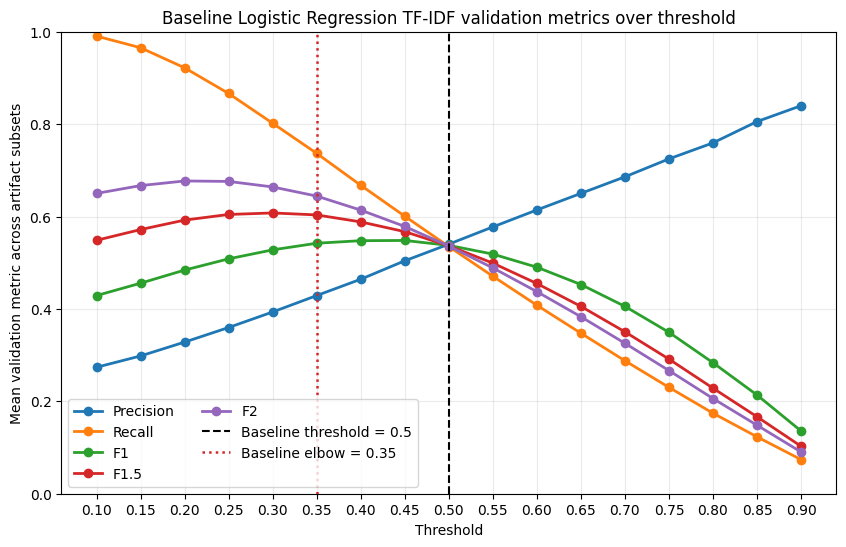

Step 1: baseline validation threshold comparison in the practical range from 0.50 to 0.30


,threshold,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.50,0.772508,0.570306,0.537562,0.536581,0.536033,0.540131,0.535018,0.762347
1,0.45,0.772508,0.570306,0.548191,0.567257,0.578525,0.504134,0.600685,0.744366
2,0.40,0.772508,0.570306,0.547701,0.588367,0.613892,0.464269,0.667687,0.715288
3,0.35,0.772508,0.570306,0.542179,0.603476,0.644267,0.428907,0.736750,0.678764
4,0.30,0.772508,0.570306,0.527831,0.607720,0.663999,0.393380,0.801915,0.629592


Step 2: metric changes when the threshold is lowered by 0.05 from the 0.50 baseline


,from_threshold,to_threshold,delta_precision,delta_recall,delta_f1,delta_f1.5,delta_f2,benefit_score,cost_score,marginal_utility_ratio
0,0.50,0.45,-0.035997,0.065667,0.010629,0.030676,0.042492,0.118788,0.035997,3.299942
1,0.45,0.40,-0.039865,0.067002,-0.000490,0.021110,0.035367,0.102369,0.040355,2.536712
2,0.40,0.35,-0.035362,0.069063,-0.005522,0.015109,0.030375,0.099438,0.040884,2.432198
3,0.35,0.30,-0.035527,0.065165,-0.014348,0.004244,0.019732,0.084897,0.049875,1.702195


Step 3: threshold steps ranked by marginal utility ratio


,from_threshold,to_threshold,delta_precision,delta_recall,delta_f1,delta_f1.5,delta_f2,benefit_score,cost_score,marginal_utility_ratio
3,0.35,0.30,-0.035527,0.065165,-0.014348,0.004244,0.019732,0.084897,0.049875,1.702195
2,0.40,0.35,-0.035362,0.069063,-0.005522,0.015109,0.030375,0.099438,0.040884,2.432198
1,0.45,0.40,-0.039865,0.067002,-0.000490,0.021110,0.035367,0.102369,0.040355,2.536712
0,0.50,0.45,-0.035997,0.065667,0.010629,0.030676,0.042492,0.118788,0.035997,3.299942


Step 4: heuristic minimum precision floor derived from the baseline elbow (0.35)


,baseline_elbow_threshold,mean_precision_at_elbow,heuristic_min_precision_floor
0,0.35,0.428907,0.4


In [ ]:
from sklearn.linear_model import LogisticRegression

LOGREG_BASELINE_C = 1.0

if (
    "baseline_logreg_tfidf_val_probs_by_subset" not in globals()
    or not baseline_logreg_tfidf_val_probs_by_subset
):
    baseline_logreg_tfidf_val_probs_by_subset = {}

    for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
        validation_artifacts = load_validation_split(artifact_name=artifact_name)
        X_train = validation_artifacts["X_tfidf_train"]
        X_val = validation_artifacts["X_tfidf_val"]
        y_train = validation_artifacts["y_train"]
        y_val = validation_artifacts["y_val"]

        baseline_model = LogisticRegression(
            C=LOGREG_BASELINE_C,
            solver="saga",
            max_iter=2000,
            random_state=42,
        )
        baseline_model.fit(X_train, y_train)

        baseline_logreg_tfidf_val_probs_by_subset[subset_name] = {
            "y_true": y_val,
            "y_prob": baseline_model.predict_proba(X_val)[:, 1],
        }

logreg_tfidf_threshold_grid = np.round(np.arange(0.1, 0.91, 0.05), 2)
logreg_tfidf_threshold_metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
logreg_tfidf_threshold_metrics_by_subset = []

for subset_name, val_data in baseline_logreg_tfidf_val_probs_by_subset.items():
    y_val = val_data["y_true"]
    y_val_prob = val_data["y_prob"]
    base_metrics = {
        "auc": roc_auc_score(y_val, y_val_prob),
        "average_precision": average_precision_score(y_val, y_val_prob),
    }

    for threshold in logreg_tfidf_threshold_grid:
        y_val_pred = (y_val_prob >= threshold).astype(int)
        logreg_tfidf_threshold_metrics_by_subset.append(
            {
                "subset": subset_name,
                "threshold": float(threshold),
                **base_metrics,
                "f1": f1_score(y_val, y_val_pred, zero_division=0),
                "f1.5": fbeta_score(y_val, y_val_pred, beta=1.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_pred, beta=2, zero_division=0),
                "precision": precision_score(y_val, y_val_pred, zero_division=0),
                "recall": recall_score(y_val, y_val_pred, zero_division=0),
                "accuracy": accuracy_score(y_val, y_val_pred),
            }
        )

logreg_tfidf_threshold_metrics_by_subset_df = pd.DataFrame(logreg_tfidf_threshold_metrics_by_subset)
logreg_tfidf_threshold_analysis_df = (
    logreg_tfidf_threshold_metrics_by_subset_df.groupby("threshold", as_index=False)[logreg_tfidf_threshold_metric_cols]
    .mean()
    .rename(columns={column: f"mean_{column}" for column in logreg_tfidf_threshold_metric_cols})
)

practical_thresholds = [
    threshold for threshold in np.round(np.arange(0.5, 0.29, -0.05), 2)
    if threshold in set(logreg_tfidf_threshold_analysis_df["threshold"])
]

logreg_tfidf_threshold_comparison_df = (
    logreg_tfidf_threshold_analysis_df[
        logreg_tfidf_threshold_analysis_df["threshold"].isin(practical_thresholds)
    ]
    .rename(columns={f"mean_{column}": column for column in logreg_tfidf_threshold_metric_cols})
    .rename(columns={"average_precision": "pr-auc"})
    .round(6)
    .sort_values("threshold", ascending=False)
    .reset_index(drop=True)
)

logreg_tfidf_threshold_step_rows = []
for row_idx in range(len(logreg_tfidf_threshold_comparison_df) - 1):
    from_row = logreg_tfidf_threshold_comparison_df.iloc[row_idx]
    to_row = logreg_tfidf_threshold_comparison_df.iloc[row_idx + 1]
    delta_precision = float(to_row["precision"] - from_row["precision"])
    delta_recall = float(to_row["recall"] - from_row["recall"])
    delta_f1 = float(to_row["f1"] - from_row["f1"])
    delta_f15 = float(to_row["f1.5"] - from_row["f1.5"])
    delta_f2 = float(to_row["f2"] - from_row["f2"])

    benefit_score = delta_recall + delta_f2 + max(delta_f1, 0.0)
    cost_score = abs(delta_precision) + abs(min(delta_f1, 0.0))
    marginal_utility_ratio = benefit_score / cost_score if cost_score > 0 else np.inf

    logreg_tfidf_threshold_step_rows.append(
        {
            "from_threshold": float(from_row["threshold"]),
            "to_threshold": float(to_row["threshold"]),
            "delta_precision": delta_precision,
            "delta_recall": delta_recall,
            "delta_f1": delta_f1,
            "delta_f1.5": delta_f15,
            "delta_f2": delta_f2,
            "benefit_score": benefit_score,
            "cost_score": cost_score,
            "marginal_utility_ratio": marginal_utility_ratio,
        }
    )

logreg_tfidf_threshold_step_change_df = pd.DataFrame(logreg_tfidf_threshold_step_rows)

logreg_tfidf_knee_threshold = float(
    logreg_tfidf_threshold_step_change_df.sort_values(
        ["marginal_utility_ratio", "from_threshold"],
        ascending=[True, False],
    ).iloc[0]["from_threshold"]
)
logreg_tfidf_knee_row = logreg_tfidf_threshold_comparison_df[
    logreg_tfidf_threshold_comparison_df["threshold"] == logreg_tfidf_knee_threshold
].iloc[0]
logreg_tfidf_knee_precision = float(logreg_tfidf_knee_row["precision"])
logreg_tfidf_heuristic_min_precision = float(np.floor(logreg_tfidf_knee_precision / 0.05) * 0.05)
logreg_tfidf_precision_floor_summary_df = pd.DataFrame(
    [
        {
            "baseline_elbow_threshold": logreg_tfidf_knee_threshold,
            "mean_precision_at_elbow": logreg_tfidf_knee_precision,
            "heuristic_min_precision_floor": logreg_tfidf_heuristic_min_precision,
        }
    ]
).round(6)

plot_metric_map = {
    "Precision": "mean_precision",
    "Recall": "mean_recall",
    "F1": "mean_f1",
    "F1.5": "mean_f1.5",
    "F2": "mean_f2",
}

fig, ax = plt.subplots(figsize=(10, 6))
for label, column in plot_metric_map.items():
    ax.plot(
        logreg_tfidf_threshold_analysis_df["threshold"],
        logreg_tfidf_threshold_analysis_df[column],
        marker="o",
        linewidth=2,
        label=label,
    )

ax.axvline(0.5, color="black", linestyle="--", linewidth=1.5, label="Baseline threshold = 0.5")
ax.axvline(
    logreg_tfidf_knee_threshold,
    color="tab:red",
    linestyle=":",
    linewidth=1.8,
    label=f"Baseline elbow = {logreg_tfidf_knee_threshold:.2f}",
)
ax.set_title("Baseline Logistic Regression TF-IDF validation metrics over threshold")
ax.set_xlabel("Threshold")
ax.set_ylabel("Mean validation metric across artifact subsets")
ax.set_xticks(logreg_tfidf_threshold_grid)
ax.set_ylim(0, 1)
ax.grid(alpha=0.25)
ax.legend(ncol=2)
plt.show()

print("Step 1: baseline validation threshold comparison in the practical range from 0.50 to 0.30")
display(logreg_tfidf_threshold_comparison_df)

print("Step 2: metric changes when the threshold is lowered by 0.05 from the 0.50 baseline")
display(logreg_tfidf_threshold_step_change_df.round(6))

print("Step 3: threshold steps ranked by marginal utility ratio")
display(
    logreg_tfidf_threshold_step_change_df.sort_values(
        ["marginal_utility_ratio", "from_threshold"],
        ascending=[True, False],
    ).round(6)
)

print(f"Step 4: heuristic minimum precision floor derived from the baseline elbow ({logreg_tfidf_knee_threshold:.2f})")
display(logreg_tfidf_precision_floor_summary_df)

#### 1.3.2 Threshold Selection Rule

- In the baseline validation sweep, the elbow appears around threshold `0.35`, where mean precision is about `0.429`. For simplicity and consistency, we round this down to the nearest `0.05` and use `0.40` as the shared minimum mean precision floor.
- Later models can still choose different validation thresholds using their own validation probabilities. However, any threshold we accept must satisfy this shared precision-floor constraint.
- Among the thresholds that satisfy the floor, we select primarily by mean `F1.5`. This gives recall more weight than standard `F1`, while still keeping precision more involved in the decision than `F2` would.
- If several thresholds perform almost the same, we apply a `0.01` tolerance and then choose the highest threshold. This keeps the final choice slightly more conservative.
- We use this shared rule for simplicity and consistency across the later threshold-selection sections.

In [23]:
THRESHOLD_RULE_SELECTION_METRIC = "f1.5"
THRESHOLD_RULE_SELECTION_TOLERANCE = 0.01
THRESHOLD_RULE_MIN_PRECISION = 0.40
THRESHOLD_RULE_TIE_BREAK = "highest_threshold"

### 1.4 Shared Tuning Settings

All models in Section 4 select hyperparameters primarily by validation AUC using a shared tuning setup. The search ranges are defined once below for consistency, while feature-specific implementation details such as sparse versus dense preprocessing remain inside the individual model cells.

This subsection contains the shared random seed and search ranges used during model selection. The fast-rerun fixed hyperparameters are separated into the next subsection.

In [24]:
RANDOM_STATE = 42
CLASS_WEIGHT = "balanced"
SHARED_THRESHOLD_GRID = np.round(np.arange(0.1, 0.91, 0.05), 2)

# Logistic Regression
LR_C_GRID = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]
SBERT_LR_C_GRID = [0.001, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]
ROBERTA_LR_C_GRID = SBERT_LR_C_GRID
LR_MAX_ITER = 2000

# SVM
SVM_C_GRID = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]
SVM_LOSS = "squared_hinge"
SVM_TOL = 1e-2
SVM_MAX_ITER = 1000
SVM_TFIDF_DUAL = "auto"
SVM_SBERT_DUAL = False
SVM_CALIBRATION_CV = 3
SVM_CALIBRATION_METHOD = "sigmoid"

# Tree-based models
DT_PARAM_GRID = {
    "max_depth": [5, 10, 15],
    "min_samples_split": [10, 25, 50],
    "min_samples_leaf": [5, 10, 20],
    "ccp_alpha": [0.0, 1e-4, 1e-3, 1e-2],
}
DT_RANDOM_SEARCH_ITER = 10

RF_PARAM_GRID = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt"]
}
RF_RANDOM_SEARCH_ITER = 5

XGB_PARAM_GRID = {
    "n_estimators": [100, 200, 400],
    "max_depth": [3, 4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1.0, 3.0, 5.0],
}
XGB_RANDOM_SEARCH_ITER = 10

# Naive Bayes
NB_ALPHA_GRID = [0.005, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0]
NB_THRESHOLD_GRID = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
NB_SBERT_TOPK = 9
NB_SBERT_VAR_SMOOTHING_GRID = [1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6]
NB_SBERT_THRESHOLD_GRID = NB_THRESHOLD_GRID

### 1.5 Fast Rerun Settings

This subsection stores fixed hyperparameters and fixed thresholds from earlier results so repeated runs can skip retuning and go straight to refitting on the full training split.

Set `USE_FIXED_BEST_PARAMS = True` to use the saved values below when they are available. Leave a value as `None` if that model has not completed its first run yet.

We use a two-item list to indicate the chosen parameters for each artifact, where the first entry is for `artifacts_1` and the second entry is for `artifacts_2`.

In [25]:
USE_FIXED_BEST_PARAMS = True

# Logistic Regression
LR_TFIDF_FIXED_C = [0.3, 0.3]
LR_TFIDF_FIXED_THRESHOLD = 0.45
LR_TFIDF_LEMMA_FIXED_C = [0.3, 0.3]
LR_TFIDF_LEMMA_FIXED_THRESHOLD = 0.45
LR_SBERT_FIXED_C = [0.3, 10.0]
LR_SBERT_FIXED_THRESHOLD = 0.55
# LR_ROBERTA_FIXED_C = [0.001, None]  # e.g. [0.001, 0.003]
# LR_ROBERTA_FIXED_THRESHOLD = None

# SVM
SVM_TFIDF_FIXED_C = [0.03, 0.03]
SVM_TFIDF_FIXED_THRESHOLD = 0.35
SVM_SBERT_FIXED_C = [0.01, None]
SVM_SBERT_FIXED_THRESHOLD = None

# Tree-based models
DT_TFIDF_FIXED_PARAMS = None
# [{"max_depth": 15, "min_samples_split": 10, "min_samples_leaf": 5, "ccp_alpha": 0.0001},
# {"max_depth": 15, "min_samples_split": 10, "min_samples_leaf": 5, "ccp_alpha": 0.0001},]
DT_TFIDF_FIXED_THRESHOLD = None
DT_SBERT_FIXED_PARAMS = [None, None]  # e.g. [{"max_depth": 15, "min_samples_split": 10, "min_samples_leaf": 5, "ccp_alpha": 0.0001}, {...}]
DT_SBERT_FIXED_THRESHOLD = None

RF_TFIDF_FIXED_PARAMS = None
# [{"n_estimators": 100, "max_depth": 20, "min_samples_split": 5, "min_samples_leaf": 2},
# {"n_estimators": 100, "max_depth": 20, "min_samples_split": 5, "min_samples_leaf": 2},]
RF_TFIDF_FIXED_THRESHOLD = None
RF_SBERT_FIXED_PARAMS = [None, None]  # e.g. [{"n_estimators": 100, "max_depth": 20, "min_samples_split": 5, "min_samples_leaf": 2}, {...}]
RF_SBERT_FIXED_THRESHOLD = None

XGB_TFIDF_FIXED_PARAMS = [None, None]  # e.g. [{"n_estimators": 100, "max_depth": 4, "learning_rate": 0.05, "subsample": 0.85, "colsample_bytree": 0.8, "min_child_weight": 1.0}, {...}]
XGB_TFIDF_FIXED_THRESHOLD = None
XGB_SBERT_FIXED_PARAMS = [None, None]  # e.g. [{"n_estimators": 200, "max_depth": 6, "learning_rate": 0.03, "subsample": 0.85, "colsample_bytree": 0.8, "min_child_weight": 3.0}, {...}]
XGB_SBERT_FIXED_THRESHOLD = None

# Naive Bayes
MNB_TFIDF_FIXED_ALPHA = 0.005
MNB_TFIDF_FIXED_THRESHOLD = 0.4
CNB_TFIDF_FIXED_ALPHA = 0.005
CNB_TFIDF_FIXED_THRESHOLD = 0.5
GNB_SBERT_FIXED_VAR_SMOOTHING = 1e-12
GNB_SBERT_FIXED_THRESHOLD = 0.4

### 1.6 Shared Transformer Review-Level Utilities

The transformer-based sections below evaluate window-level predictions at the review level rather than directly at the window level. The shared smoothing and top-k review aggregation helpers are defined once here and reused across the later SBERT-based model sections.

In [6]:
# Review-level pooling for transformer validation and test splits
from collections import defaultdict
import numpy as np

''' Convolution '''
def smooth_probs_reflect(probs, kernel):
    '''
    Applies convolution kernel over probabilities of adjacent windows
    '''
    
    pad = len(kernel) // 2
    padded = np.pad(probs, pad, mode='reflect')
    return np.convolve(padded, kernel, mode='valid')


'''
Top k = 9 windows are considered
'''


def predict_per_review_topk_smooth(
    y_probs, review_ids, review_label_map, threshold=0.5, k=9
):
    from collections import defaultdict
    import numpy as np

    review_probs = defaultdict(list)

    # Collect probs per review
    for rid, prob in zip(review_ids, y_probs):
        spoiler_prob = prob
        review_probs[rid].append(spoiler_prob)

    review_agg = {}
    KERNEL = np.array([0.2, 0.6, 0.2])

    for rid, probs in review_probs.items():
        probs = np.array(probs)

        smoothed_probs = smooth_probs_reflect(probs, KERNEL)

        topk = np.sort(smoothed_probs)[::-1][:k]
        review_agg[rid] = np.mean(topk)

    sorted_review_ids = sorted(review_agg.keys())

    y_review_scores = [
        review_agg[rid]
        for rid in sorted_review_ids
    ]

    y_review_pred = [
        1 if score > threshold else 0
        for score in y_review_scores
    ]

    y_review_true = [
        review_label_map[rid]
        for rid in sorted_review_ids
    ]

    return y_review_scores, y_review_pred, y_review_true

### 2 Logistic Regression

#### 2.1 TF-IDF

In [18]:
# Model Training and Validation Tuning
from sklearn.linear_model import LogisticRegression

metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
logreg_tfidf_best_c_by_subset = {}
logreg_tfidf_models = {}
logreg_tfidf_val_probs_by_subset = {}
logreg_tfidf_tuning_results = {}
tfidf_validation_rows = []

for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
    print(f"\n===== Logistic Regression TF-IDF | subset {subset_name} ({artifact_name}) =====")

    validation_artifacts = load_validation_split(artifact_name=artifact_name)
    X_train = validation_artifacts["X_tfidf_train"]
    X_val = validation_artifacts["X_tfidf_val"]
    y_train = validation_artifacts["y_train"]
    y_val = validation_artifacts["y_val"]

    artifact_idx = int(subset_name) - 1
    fixed_c = LR_TFIDF_FIXED_C[artifact_idx] if artifact_idx < len(LR_TFIDF_FIXED_C) else None

    if USE_FIXED_BEST_PARAMS and fixed_c is not None:
        candidate_cs = [float(fixed_c)]
        print(f"Using fixed C for subset {subset_name}: {candidate_cs[0]}")
    else:
        candidate_cs = LR_C_GRID

    tuning_rows = []
    for c_value in tqdm(candidate_cs, desc=f"subset {subset_name} C search", leave=False):
        model = LogisticRegression(
            C=float(c_value),
            solver="saga",
            max_iter=LR_MAX_ITER,
            random_state=RANDOM_STATE,
            class_weight=CLASS_WEIGHT,
        )
        model.fit(X_train, y_train)

        y_val_prob = model.predict_proba(X_val)[:, 1]
        tuning_rows.append(
            {
                "C": float(c_value),
                "auc": roc_auc_score(y_val, y_val_prob),
                "average_precision": average_precision_score(y_val, y_val_prob),
                "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "f1.5": fbeta_score(y_val, y_val_prob >= 0.5, beta=1.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
                "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
            }
        )

    tuning_df = pd.DataFrame(tuning_rows).sort_values("auc", ascending=False).reset_index(drop=True)
    best_c = float(tuning_df.loc[0, "C"])

    logreg_tfidf_tuning_results[subset_name] = tuning_df
    logreg_tfidf_best_c_by_subset[subset_name] = best_c

    print(f"Selected C for subset {subset_name}: {best_c}")
    display(
        tuning_df[["C"] + metric_cols]
        .rename(columns={"average_precision": "pr-auc"})
        .round(6)
    )

    selected_row = tuning_df.loc[0, ["C"] + metric_cols].to_dict()
    tfidf_validation_rows.append({"subset": subset_name, **selected_row})

    selected_val_model = LogisticRegression(
        C=best_c,
        solver="saga",
        max_iter=LR_MAX_ITER,
        random_state=RANDOM_STATE,
        class_weight=CLASS_WEIGHT,
    )
    selected_val_model.fit(X_train, y_train)
    logreg_tfidf_val_probs_by_subset[subset_name] = {
        "y_true": y_val,
        "y_prob": selected_val_model.predict_proba(X_val)[:, 1],
    }

    full_artifacts = load_full_train_test(artifact_name=artifact_name, use_fulltrain=True)
    X_train_full = full_artifacts["X_tfidf_train_full"]
    y_train_full = full_artifacts["y_train_full"]

    final_model = LogisticRegression(
        C=best_c,
        solver="saga",
        max_iter=LR_MAX_ITER,
        random_state=RANDOM_STATE,
        class_weight=CLASS_WEIGHT,
    )
    final_model.fit(X_train_full, y_train_full)
    logreg_tfidf_models[subset_name] = final_model

tfidf_validation_metrics_df = pd.DataFrame(tfidf_validation_rows)
print("Validation metrics for selected C by subset:")
display(
    tfidf_validation_metrics_df[["subset", "C"] + metric_cols]
    .rename(columns={"average_precision": "pr-auc"})
    .round(6)
)

validation_details_tfidf = tfidf_validation_metrics_df.copy()
validation_summary_tfidf = tfidf_validation_metrics_df[metric_cols].mean().to_frame().T

print("Average validation metrics across subsets:")
display(
    validation_summary_tfidf.rename(columns={"average_precision": "pr-auc"}).round(6)
)

logreg_tfidf_best_c = logreg_tfidf_best_c_by_subset["1"]
logreg_tfidf_model = logreg_tfidf_models["1"]


===== Logistic Regression TF-IDF | subset 1 (artifacts_1) =====
Using fixed C for subset 1: 0.3


subset 1 C search:   0%|          | 0/1 [00:00<?, ?it/s]

Selected C for subset 1: 0.3


,C,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.3,0.774593,0.567331,0.550689,0.589864,0.614338,0.469599,0.665627,0.719571



===== Logistic Regression TF-IDF | subset 2 (artifacts_2) =====
Using fixed C for subset 2: 0.3


...

,C,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.3,0.774111,0.566724,0.550474,0.589157,0.613291,0.470205,0.66379,0.720103


Validation metrics for selected C by subset:


,subset,C,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,1,0.3,0.774593,0.567331,0.550689,0.589864,0.614338,0.469599,0.665627,0.719571
1,2,0.3,0.774111,0.566724,0.550474,0.589157,0.613291,0.470205,0.663790,0.720103


Average validation metrics across subsets:


,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.774352,0.567028,0.550581,0.589511,0.613815,0.469902,0.664709,0.719837


In [ ]:
# Threshold Tuning
logreg_tfidf_tuned_threshold_metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
logreg_tfidf_tuned_threshold_metrics_by_subset = []

fixed_threshold = None
if USE_FIXED_BEST_PARAMS and LR_TFIDF_FIXED_THRESHOLD is not None:
    fixed_threshold = float(LR_TFIDF_FIXED_THRESHOLD)
    threshold_candidates = [fixed_threshold]
    print(f"Using fixed Logistic Regression TF-IDF threshold: {fixed_threshold}")
else:
    threshold_candidates = SHARED_THRESHOLD_GRID

for subset_name, val_data in logreg_tfidf_val_probs_by_subset.items():
    y_val = val_data["y_true"]
    y_val_prob = val_data["y_prob"]
    base_metrics = {
        "auc": roc_auc_score(y_val, y_val_prob),
        "average_precision": average_precision_score(y_val, y_val_prob),
    }

    for threshold in threshold_candidates:
        y_val_pred = (y_val_prob >= threshold).astype(int)
        logreg_tfidf_tuned_threshold_metrics_by_subset.append(
            {
                "subset": subset_name, "threshold": float(threshold), **base_metrics,
                "f1": f1_score(y_val, y_val_pred, zero_division=0), "f1.5": fbeta_score(y_val, y_val_pred, beta=1.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_pred, beta=2, zero_division=0), "precision": precision_score(y_val, y_val_pred, zero_division=0),
                "recall": recall_score(y_val, y_val_pred, zero_division=0), "accuracy": accuracy_score(y_val, y_val_pred),
            }
        )

logreg_tfidf_tuned_threshold_metrics_by_subset_df = pd.DataFrame(logreg_tfidf_tuned_threshold_metrics_by_subset)
logreg_tfidf_tuned_threshold_analysis_df = (
    logreg_tfidf_tuned_threshold_metrics_by_subset_df.groupby("threshold", as_index=False)[logreg_tfidf_tuned_threshold_metric_cols]
    .mean()
    .rename(columns={column: f"mean_{column}" for column in logreg_tfidf_tuned_threshold_metric_cols})
)

if fixed_threshold is not None:
    logreg_tfidf_best_threshold = fixed_threshold
    logreg_tfidf_threshold_selection_df = logreg_tfidf_tuned_threshold_analysis_df.copy().sort_values("threshold").reset_index(drop=True)
else:
    eligible_thresholds_df = logreg_tfidf_tuned_threshold_analysis_df[
        logreg_tfidf_tuned_threshold_analysis_df["mean_precision"] >= THRESHOLD_RULE_MIN_PRECISION
    ].copy()
    if eligible_thresholds_df.empty:
        eligible_thresholds_df = logreg_tfidf_tuned_threshold_analysis_df.copy()

    best_metric_value = eligible_thresholds_df[f"mean_{THRESHOLD_RULE_SELECTION_METRIC}"].max()
    near_optimal_thresholds_df = eligible_thresholds_df[
        eligible_thresholds_df[f"mean_{THRESHOLD_RULE_SELECTION_METRIC}"]
        >= best_metric_value - THRESHOLD_RULE_SELECTION_TOLERANCE
    ].copy()

    logreg_tfidf_best_threshold = float(near_optimal_thresholds_df["threshold"].max())
    logreg_tfidf_threshold_selection_df = near_optimal_thresholds_df.sort_values("threshold").reset_index(drop=True)

logreg_tfidf_validation_summary_by_threshold = logreg_tfidf_tuned_threshold_metrics_by_subset_df[
    logreg_tfidf_tuned_threshold_metrics_by_subset_df["threshold"] == logreg_tfidf_best_threshold
].copy()
logreg_tfidf_validation_summary_selected_threshold = (
    logreg_tfidf_validation_summary_by_threshold[logreg_tfidf_tuned_threshold_metric_cols].mean().to_frame().T
)

available_thresholds = set(logreg_tfidf_tuned_threshold_analysis_df["threshold"])
comparison_thresholds = [
    threshold for threshold in [0.70, 0.65, 0.60, 0.55, 0.50, 0.45, 0.40, 0.35, 0.30]
    if threshold in available_thresholds
]
if fixed_threshold is not None and fixed_threshold not in comparison_thresholds:
    comparison_thresholds = [fixed_threshold]

logreg_tfidf_tuned_threshold_comparison_df = (
    logreg_tfidf_tuned_threshold_analysis_df[
        logreg_tfidf_tuned_threshold_analysis_df["threshold"].isin(comparison_thresholds)
    ]
    .rename(columns={f"mean_{column}": column for column in logreg_tfidf_tuned_threshold_metric_cols})
    .rename(columns={"average_precision": "pr-auc"})
    .sort_values("threshold", ascending=False)
    .reset_index(drop=True)
    .round(6)
)

print("Threshold comparison for the tuned Logistic Regression TF-IDF model:")
display(logreg_tfidf_tuned_threshold_comparison_df)

if fixed_threshold is None:
    print(f"Threshold candidates that satisfy the shared threshold rule (mean {THRESHOLD_RULE_SELECTION_METRIC}):")
    display(
        logreg_tfidf_threshold_selection_df.rename(columns={"mean_average_precision": "mean_pr-auc"}).round(6)
    )
else:
    print("Using the fixed threshold from Section 4.5:")
    display(
        logreg_tfidf_threshold_selection_df.rename(columns={"mean_average_precision": "mean_pr-auc"}).round(6)
    )

print(f"Selected Logistic Regression TF-IDF threshold: {logreg_tfidf_best_threshold}")

print("Validation metrics by subset for the selected threshold:")
display(
    logreg_tfidf_validation_summary_by_threshold.rename(columns={"average_precision": "pr-auc"}).round(6)
)

print("Average validation metrics across subsets for the selected threshold:")
display(
    logreg_tfidf_validation_summary_selected_threshold.rename(columns={"average_precision": "pr-auc"}).round(6)
)

Using fixed Logistic Regression TF-IDF threshold: 0.45
Threshold comparison for the tuned Logistic Regression TF-IDF model:


,threshold,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.45,0.774352,0.567028,0.54552,0.607037,0.647955,0.431759,0.740675,0.681373


Using the fixed threshold from Section 4.5:


,threshold,mean_auc,mean_pr-auc,mean_f1,mean_f1.5,mean_f2,mean_precision,mean_recall,mean_accuracy
0,0.45,0.774352,0.567028,0.54552,0.607037,0.647955,0.431759,0.740675,0.681373


Selected Logistic Regression TF-IDF threshold: 0.45
Validation metrics by subset for the selected threshold:


,subset,threshold,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,1,0.45,0.774593,0.567331,0.546316,0.607830,0.648736,0.432511,0.741399,0.682085
1,2,0.45,0.774111,0.566724,0.544724,0.606243,0.647173,0.431008,0.739951,0.680662


Average validation metrics across subsets for the selected threshold:


,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.774352,0.567028,0.54552,0.607037,0.647955,0.431759,0.740675,0.681373


#### 2.2 TF-IDF + Lemmatization

In [ ]:
# Model Training and Validation Tuning
from sklearn.linear_model import LogisticRegression

metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
logreg_tfidf_lemma_best_c_by_subset = {}
logreg_tfidf_lemma_models = {}
logreg_tfidf_lemma_val_probs_by_subset = {}
logreg_tfidf_lemma_tuning_results = {}
tfidf_lemma_validation_rows = []

for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
    print(f"\n===== Logistic Regression TF-IDF + Lemma | subset {subset_name} ({artifact_name}) =====")
    
    # Validation split for model selection.
    validation_artifacts = load_validation_split(artifact_name=artifact_name)
    X_train = validation_artifacts["X_tfidf_lemma_train"]
    X_val = validation_artifacts["X_tfidf_lemma_val"]
    y_train = validation_artifacts["y_train"]
    y_val = validation_artifacts["y_val"]

    artifact_idx = int(subset_name) - 1
    fixed_c = LR_TFIDF_LEMMA_FIXED_C[artifact_idx] if artifact_idx < len(LR_TFIDF_LEMMA_FIXED_C) else None

    if USE_FIXED_BEST_PARAMS and fixed_c is not None:
        candidate_cs = [float(fixed_c)]
        print(f"Using fixed C for subset {subset_name}: {candidate_cs[0]}")
    else:
        candidate_cs = LR_C_GRID

    tuning_rows = []
    for c_value in tqdm(candidate_cs, desc=f"subset {subset_name} C search", leave=False):
        model = LogisticRegression(
            C=float(c_value),
            solver="saga",
            max_iter=LR_MAX_ITER,
            random_state=RANDOM_STATE,
            class_weight=CLASS_WEIGHT,
        )
        model.fit(X_train, y_train)

        y_val_prob = model.predict_proba(X_val)[:, 1]
        tuning_rows.append(
            {
                "C": float(c_value), "auc": roc_auc_score(y_val, y_val_prob),
                "average_precision": average_precision_score(y_val, y_val_prob),
                "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0), "f1.5": fbeta_score(y_val, y_val_prob >= 0.5, beta=1.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0), "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0), "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
            }
        )

    tuning_df = pd.DataFrame(tuning_rows).sort_values("auc", ascending=False).reset_index(drop=True)
    best_c = float(tuning_df.loc[0, "C"])

    logreg_tfidf_lemma_tuning_results[subset_name] = tuning_df
    logreg_tfidf_lemma_best_c_by_subset[subset_name] = best_c

    print(f"Selected C for subset {subset_name}: {best_c}")
    display(
        tuning_df[["C"] + metric_cols]
        .rename(columns={"average_precision": "pr-auc"})
        .round(6)
    )

    selected_row = tuning_df.loc[0, ["C"] + metric_cols].to_dict()
    tfidf_lemma_validation_rows.append({"subset": subset_name, **selected_row})

    # Full-train refit for final evaluation.
    selected_val_model = LogisticRegression(
        C=best_c,
        solver="saga",
        max_iter=LR_MAX_ITER,
        random_state=RANDOM_STATE,
        class_weight=CLASS_WEIGHT,
    )
    selected_val_model.fit(X_train, y_train)
    logreg_tfidf_lemma_val_probs_by_subset[subset_name] = {
        "y_true": y_val,
        "y_prob": selected_val_model.predict_proba(X_val)[:, 1],
    }

    full_artifacts = load_full_train_test(artifact_name=artifact_name, use_fulltrain=True)
    X_train_full = full_artifacts["X_tfidf_lemma_train_full"]
    y_train_full = full_artifacts["y_train_full"]

    final_model = LogisticRegression(
        C=best_c,
        solver="saga",
        max_iter=LR_MAX_ITER,
        random_state=RANDOM_STATE,
        class_weight=CLASS_WEIGHT,
    )
    final_model.fit(X_train_full, y_train_full)
    logreg_tfidf_lemma_models[subset_name] = final_model

tfidf_lemma_validation_metrics_df = pd.DataFrame(tfidf_lemma_validation_rows)
print("Validation metrics for selected C by subset:")
display(
    tfidf_lemma_validation_metrics_df[["subset", "C"] + metric_cols]
    .rename(columns={"average_precision": "pr-auc"})
    .round(6)
)

validation_details_tfidf_lemma = tfidf_lemma_validation_metrics_df.copy()
validation_summary_tfidf_lemma = tfidf_lemma_validation_metrics_df[metric_cols].mean().to_frame().T

print("Average validation metrics across subsets:")
display(
    validation_summary_tfidf_lemma.rename(columns={"average_precision": "pr-auc"}).round(6)
)

logreg_tfidf_lemma_best_c = logreg_tfidf_lemma_best_c_by_subset["1"]
logreg_tfidf_lemma_model = logreg_tfidf_lemma_models["1"]


===== Logistic Regression TF-IDF + Lemma | subset 1 (artifacts_1) =====
Using fixed C for subset 1: 0.3


subset 1 C search:   0%|          | 0/1 [00:00<?, ?it/s]

Selected C for subset 1: 0.3


,C,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.3,0.773946,0.56855,0.551146,0.590321,0.614793,0.470043,0.666073,0.719902



===== Logistic Regression TF-IDF + Lemma | subset 2 (artifacts_2) =====
Using fixed C for subset 2: 0.3


...

,C,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.3,0.773613,0.568027,0.549902,0.588433,0.612465,0.469901,0.662732,0.719902


Validation metrics for selected C by subset:


,subset,C,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,1,0.3,0.773946,0.568550,0.551146,0.590321,0.614793,0.470043,0.666073,0.719902
1,2,0.3,0.773613,0.568027,0.549902,0.588433,0.612465,0.469901,0.662732,0.719902


Average validation metrics across subsets:


,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.77378,0.568288,0.550524,0.589377,0.613629,0.469972,0.664403,0.719902


In [ ]:
# Threshold Tuning
logreg_tfidf_lemma_tuned_threshold_metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
logreg_tfidf_lemma_tuned_threshold_metrics_by_subset = []

fixed_threshold = None
if USE_FIXED_BEST_PARAMS and LR_TFIDF_LEMMA_FIXED_THRESHOLD is not None:
    fixed_threshold = float(LR_TFIDF_LEMMA_FIXED_THRESHOLD)
    threshold_candidates = [fixed_threshold]
    print(f"Using fixed Logistic Regression TF-IDF + Lemma threshold: {fixed_threshold}")
else:
    threshold_candidates = SHARED_THRESHOLD_GRID

for subset_name, val_data in logreg_tfidf_lemma_val_probs_by_subset.items():
    y_val = val_data["y_true"]
    y_val_prob = val_data["y_prob"]
    base_metrics = {
        "auc": roc_auc_score(y_val, y_val_prob),
        "average_precision": average_precision_score(y_val, y_val_prob),
    }

    for threshold in threshold_candidates:
        y_val_pred = (y_val_prob >= threshold).astype(int)
        logreg_tfidf_lemma_tuned_threshold_metrics_by_subset.append(
            {
                "subset": subset_name, "threshold": float(threshold), **base_metrics,
                "f1": f1_score(y_val, y_val_pred, zero_division=0), "f1.5": fbeta_score(y_val, y_val_pred, beta=1.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_pred, beta=2, zero_division=0), "precision": precision_score(y_val, y_val_pred, zero_division=0),
                "recall": recall_score(y_val, y_val_pred, zero_division=0), "accuracy": accuracy_score(y_val, y_val_pred),
            }
        )

logreg_tfidf_lemma_tuned_threshold_metrics_by_subset_df = pd.DataFrame(logreg_tfidf_lemma_tuned_threshold_metrics_by_subset)
logreg_tfidf_lemma_tuned_threshold_analysis_df = (
    logreg_tfidf_lemma_tuned_threshold_metrics_by_subset_df.groupby("threshold", as_index=False)[logreg_tfidf_lemma_tuned_threshold_metric_cols]
    .mean()
    .rename(columns={column: f"mean_{column}" for column in logreg_tfidf_lemma_tuned_threshold_metric_cols})
)

if fixed_threshold is not None:
    logreg_tfidf_lemma_best_threshold = fixed_threshold
    logreg_tfidf_lemma_threshold_selection_df = (
        logreg_tfidf_lemma_tuned_threshold_analysis_df.copy().sort_values("threshold").reset_index(drop=True)
    )
else:
    eligible_thresholds_df = logreg_tfidf_lemma_tuned_threshold_analysis_df[
        logreg_tfidf_lemma_tuned_threshold_analysis_df["mean_precision"] >= THRESHOLD_RULE_MIN_PRECISION
    ].copy()
    if eligible_thresholds_df.empty:
        eligible_thresholds_df = logreg_tfidf_lemma_tuned_threshold_analysis_df.copy()

    best_metric_value = eligible_thresholds_df[f"mean_{THRESHOLD_RULE_SELECTION_METRIC}"].max()
    near_optimal_thresholds_df = eligible_thresholds_df[
        eligible_thresholds_df[f"mean_{THRESHOLD_RULE_SELECTION_METRIC}"]
        >= best_metric_value - THRESHOLD_RULE_SELECTION_TOLERANCE
    ].copy()

    logreg_tfidf_lemma_best_threshold = float(near_optimal_thresholds_df["threshold"].max())
    logreg_tfidf_lemma_threshold_selection_df = near_optimal_thresholds_df.sort_values("threshold").reset_index(drop=True)

logreg_tfidf_lemma_validation_summary_by_threshold = logreg_tfidf_lemma_tuned_threshold_metrics_by_subset_df[
    logreg_tfidf_lemma_tuned_threshold_metrics_by_subset_df["threshold"] == logreg_tfidf_lemma_best_threshold
].copy()
logreg_tfidf_lemma_validation_summary_selected_threshold = (
    logreg_tfidf_lemma_validation_summary_by_threshold[logreg_tfidf_lemma_tuned_threshold_metric_cols].mean().to_frame().T
)

available_thresholds = set(logreg_tfidf_lemma_tuned_threshold_analysis_df["threshold"])
comparison_thresholds = [
    threshold for threshold in [0.70, 0.65, 0.60, 0.55, 0.50, 0.45, 0.40, 0.35, 0.30]
    if threshold in available_thresholds
]
if fixed_threshold is not None and fixed_threshold not in comparison_thresholds:
    comparison_thresholds = [fixed_threshold]

logreg_tfidf_lemma_tuned_threshold_comparison_df = (
    logreg_tfidf_lemma_tuned_threshold_analysis_df[
        logreg_tfidf_lemma_tuned_threshold_analysis_df["threshold"].isin(comparison_thresholds)
    ]
    .rename(columns={f"mean_{column}": column for column in logreg_tfidf_lemma_tuned_threshold_metric_cols})
    .rename(columns={"average_precision": "pr-auc"})
    .sort_values("threshold", ascending=False)
    .reset_index(drop=True)
    .round(6)
)

print("Threshold comparison for the tuned Logistic Regression TF-IDF + Lemma model:")
display(logreg_tfidf_lemma_tuned_threshold_comparison_df)

if fixed_threshold is None:
    print(f"Threshold candidates that satisfy the shared threshold rule (mean {THRESHOLD_RULE_SELECTION_METRIC}):")
    display(
        logreg_tfidf_lemma_threshold_selection_df.rename(columns={"mean_average_precision": "mean_pr-auc"}).round(6)
    )
else:
    print("Using the fixed threshold from Section 4.5:")
    display(
        logreg_tfidf_lemma_threshold_selection_df.rename(columns={"mean_average_precision": "mean_pr-auc"}).round(6)
    )

print(f"Selected Logistic Regression TF-IDF + Lemma threshold: {logreg_tfidf_lemma_best_threshold}")

print("Validation metrics by subset for the selected threshold:")
display(
    logreg_tfidf_lemma_validation_summary_by_threshold.rename(columns={"average_precision": "pr-auc"}).round(6)
)

print("Average validation metrics across subsets for the selected threshold:")
display(
    logreg_tfidf_lemma_validation_summary_selected_threshold.rename(columns={"average_precision": "pr-auc"}).round(6)
)

Using fixed Logistic Regression TF-IDF + Lemma threshold: 0.45
Threshold comparison for the tuned Logistic Regression TF-IDF + Lemma model:


,threshold,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.45,0.77378,0.568288,0.544473,0.606116,0.647146,0.430609,0.740202,0.680231


Using the fixed threshold from Section 4.5:


,threshold,mean_auc,mean_pr-auc,mean_f1,mean_f1.5,mean_f2,mean_precision,mean_recall,mean_accuracy
0,0.45,0.77378,0.568288,0.544473,0.606116,0.647146,0.430609,0.740202,0.680231


Selected Logistic Regression TF-IDF + Lemma threshold: 0.45
Validation metrics by subset for the selected threshold:


,subset,threshold,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,1,0.45,0.773946,0.568550,0.544893,0.606803,0.648035,0.430654,0.741621,0.680159
1,2,0.45,0.773613,0.568027,0.544053,0.605430,0.646258,0.430565,0.738782,0.680302


Average validation metrics across subsets for the selected threshold:


,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.77378,0.568288,0.544473,0.606116,0.647146,0.430609,0.740202,0.680231


#### 2.3 SBERT

In [20]:
# Prediction pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, fbeta_score,
    precision_score, recall_score, accuracy_score
)

# Shared only across transformer-based Logistic Regression variants.
def run_transformer_logreg_hypertuning(
    X_train_sub,
    X_val,
    y_train_sub,
    val_review_ids,
    val_review_label_map,
    candidate_cs,
    label,
 ):
    tuning_rows = []

    for c_value in tqdm(candidate_cs, desc=label, leave=False):
        model = make_pipeline(
            StandardScaler(),
            LogisticRegression(
                C=float(c_value),
                solver="saga",
                max_iter=LR_MAX_ITER,
                random_state=RANDOM_STATE,
                class_weight=CLASS_WEIGHT,
            ),
        )
        model.fit(X_train_sub, y_train_sub)

        y_scores, y_pred, y_true = predict_per_review_topk_smooth(
            model.predict_proba(X_val)[:, 1],
            val_review_ids,
            val_review_label_map,
        )

        tuning_rows.append(
            {
                "C": float(c_value),
                "auc": roc_auc_score(y_true, y_scores),
                "average_precision": average_precision_score(y_true, y_scores),
                "f1": f1_score(y_true, y_pred, zero_division=0),
                "f1.5": fbeta_score(y_true, y_pred, beta=1.5, zero_division=0),
                "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
                "precision": precision_score(y_true, y_pred, zero_division=0),
                "recall": recall_score(y_true, y_pred, zero_division=0),
                "accuracy": accuracy_score(y_true, y_pred),
            }
        )

    tuning_df = pd.DataFrame(tuning_rows).sort_values("auc", ascending=False).reset_index(drop=True)
    best_c = float(tuning_df.loc[0, "C"])

    print(f"Selected C: {best_c}")
    display(
        tuning_df[["C", "auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]]
        .rename(columns={"average_precision": "pr-auc"})
        .round(6)
    )

    return best_c, tuning_df

In [ ]:
# Model Training and Validation Tuning
metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
logreg_sbert_best_c_by_subset = {}
logreg_sbert_models = {}
logreg_sbert_val_scores_by_subset = {}
logreg_sbert_tuning_results = {}
sbert_validation_rows = []

for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
    print(f"\n===== Logistic Regression SBERT | subset {subset_name} ({artifact_name}) =====")

    # SBERT validation split for model selection.
    validation_data = load_transformer_validation_splits(
        artifact_name=artifact_name,
        model_type="sbert",
    )
    X_sbert_train_sub = validation_data["X_train"]
    y_sbert_train_sub = validation_data["y_train"]
    X_sbert_val = validation_data["X_val"]
    review_ids_val = validation_data["review_ids_val"]
    review_label_map_val = validation_data["review_label_map_val"]

    # SBERT hyperparameter search on the validation split.
    artifact_idx = int(subset_name) - 1
    fixed_c = LR_SBERT_FIXED_C[artifact_idx] if artifact_idx < len(LR_SBERT_FIXED_C) else None

    if USE_FIXED_BEST_PARAMS and fixed_c is not None:
        candidate_cs = [float(fixed_c)]
        print(f"Using fixed C for subset {subset_name}: {candidate_cs[0]}")
    else:
        candidate_cs = SBERT_LR_C_GRID

    best_c_sbert, tuning_df = run_transformer_logreg_hypertuning(
        X_sbert_train_sub,
        X_sbert_val,
        y_sbert_train_sub,
        review_ids_val,
        review_label_map_val,
        candidate_cs,
        label=f"SBERT subset {subset_name} C search",
    )

    logreg_sbert_best_c_by_subset[subset_name] = best_c_sbert
    logreg_sbert_tuning_results[subset_name] = tuning_df

    selected_row = tuning_df.loc[0, ["C"] + metric_cols].to_dict()
    sbert_validation_rows.append({"subset": subset_name, **selected_row})

    # SBERT full-train refit for final evaluation.
    selected_val_model = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            C=best_c_sbert,
            solver="saga",
            max_iter=LR_MAX_ITER,
            random_state=RANDOM_STATE,
            class_weight=CLASS_WEIGHT,
        ),
    )
    selected_val_model.fit(X_sbert_train_sub, y_sbert_train_sub)
    y_val_scores, _, y_val_true = predict_per_review_topk_smooth(
        selected_val_model.predict_proba(X_sbert_val)[:, 1],
        review_ids_val,
        review_label_map_val,
    )
    logreg_sbert_val_scores_by_subset[subset_name] = {
        "y_true": np.asarray(y_val_true),
        "y_score": np.asarray(y_val_scores),
    }

    fulltrain_data = load_transformer_fulltrain_test_splits(
        artifact_name=artifact_name,
        model_type="sbert",
    )
    X_sbert_train_full = fulltrain_data["X_train_full"]
    y_sbert_train_full = fulltrain_data["y_train_full"]

    final_model_sbert = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            C=best_c_sbert,
            solver="saga",
            max_iter=LR_MAX_ITER,
            random_state=RANDOM_STATE,
            class_weight=CLASS_WEIGHT,
        ),
    )
    final_model_sbert.fit(X_sbert_train_full, y_sbert_train_full)
    logreg_sbert_models[subset_name] = final_model_sbert

sbert_validation_metrics_df = pd.DataFrame(sbert_validation_rows)
print("Validation metrics for selected C by subset:")
display(
    sbert_validation_metrics_df[["subset", "C"] + metric_cols]
    .rename(columns={"average_precision": "pr-auc"})
    .round(6)
)

validation_details_sbert = sbert_validation_metrics_df.copy()
validation_summary_sbert = sbert_validation_metrics_df[metric_cols].mean().to_frame().T
print("Average validation metrics across subsets:")
display(
    validation_summary_sbert.rename(columns={"average_precision": "pr-auc"}).round(6)
)

logreg_sbert_best_c = logreg_sbert_best_c_by_subset["1"]
logreg_sbert_model = logreg_sbert_models["1"]


===== Logistic Regression SBERT | subset 1 (artifacts_1) =====
Using fixed C for subset 1: 0.3


SBERT subset 1 C search:   0%|          | 0/1 [00:00<?, ?it/s]

Selected C: 0.3


,C,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.3,0.736767,0.495091,0.500012,0.571578,0.621383,0.377214,0.741352,0.6298



===== Logistic Regression SBERT | subset 2 (artifacts_2) =====
Using fixed C for subset 2: 10.0


...

,C,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,10.0,0.736921,0.494959,0.500157,0.571892,0.621836,0.377156,0.742213,0.629585


Validation metrics for selected C by subset:


,subset,C,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,1,0.3,0.736767,0.495091,0.500012,0.571578,0.621383,0.377214,0.741352,0.629800
1,2,10.0,0.736921,0.494959,0.500157,0.571892,0.621836,0.377156,0.742213,0.629585


Average validation metrics across subsets:


,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.736844,0.495025,0.500085,0.571735,0.62161,0.377185,0.741783,0.629693


In [ ]:
# Threshold Tuning
logreg_sbert_tuned_threshold_metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
logreg_sbert_tuned_threshold_metrics_by_subset = []

fixed_threshold = None
if USE_FIXED_BEST_PARAMS and LR_SBERT_FIXED_THRESHOLD is not None:
    fixed_threshold = float(LR_SBERT_FIXED_THRESHOLD)
    threshold_candidates = [fixed_threshold]
    print(f"Using fixed Logistic Regression SBERT threshold: {fixed_threshold}")
else:
    threshold_candidates = SHARED_THRESHOLD_GRID

for subset_name, val_data in logreg_sbert_val_scores_by_subset.items():
    y_val = val_data["y_true"]
    y_val_score = val_data["y_score"]
    base_metrics = {
        "auc": roc_auc_score(y_val, y_val_score),
        "average_precision": average_precision_score(y_val, y_val_score),
    }

    for threshold in threshold_candidates:
        y_val_pred = (y_val_score >= threshold).astype(int)
        logreg_sbert_tuned_threshold_metrics_by_subset.append(
            {
                "subset": subset_name, "threshold": float(threshold), **base_metrics,
                "f1": f1_score(y_val, y_val_pred, zero_division=0), "f1.5": fbeta_score(y_val, y_val_pred, beta=1.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_pred, beta=2, zero_division=0), "precision": precision_score(y_val, y_val_pred, zero_division=0),
                "recall": recall_score(y_val, y_val_pred, zero_division=0), "accuracy": accuracy_score(y_val, y_val_pred),
            }
        )

logreg_sbert_tuned_threshold_metrics_by_subset_df = pd.DataFrame(logreg_sbert_tuned_threshold_metrics_by_subset)
logreg_sbert_tuned_threshold_analysis_df = (
    logreg_sbert_tuned_threshold_metrics_by_subset_df.groupby("threshold", as_index=False)[logreg_sbert_tuned_threshold_metric_cols]
    .mean()
    .rename(columns={column: f"mean_{column}" for column in logreg_sbert_tuned_threshold_metric_cols})
)

if fixed_threshold is not None:
    logreg_sbert_best_threshold = fixed_threshold
    logreg_sbert_threshold_selection_df = (
        logreg_sbert_tuned_threshold_analysis_df.copy().sort_values("threshold").reset_index(drop=True)
    )
else:
    eligible_thresholds_df = logreg_sbert_tuned_threshold_analysis_df[
        logreg_sbert_tuned_threshold_analysis_df["mean_precision"] >= THRESHOLD_RULE_MIN_PRECISION
    ].copy()
    if eligible_thresholds_df.empty:
        eligible_thresholds_df = logreg_sbert_tuned_threshold_analysis_df.copy()

    best_metric_value = eligible_thresholds_df[f"mean_{THRESHOLD_RULE_SELECTION_METRIC}"].max()
    near_optimal_thresholds_df = eligible_thresholds_df[
        eligible_thresholds_df[f"mean_{THRESHOLD_RULE_SELECTION_METRIC}"]
        >= best_metric_value - THRESHOLD_RULE_SELECTION_TOLERANCE
    ].copy()

    logreg_sbert_best_threshold = float(near_optimal_thresholds_df["threshold"].max())
    logreg_sbert_threshold_selection_df = near_optimal_thresholds_df.sort_values("threshold").reset_index(drop=True)

logreg_sbert_validation_summary_by_threshold = logreg_sbert_tuned_threshold_metrics_by_subset_df[
    logreg_sbert_tuned_threshold_metrics_by_subset_df["threshold"] == logreg_sbert_best_threshold
].copy()
logreg_sbert_validation_summary_selected_threshold = (
    logreg_sbert_validation_summary_by_threshold[logreg_sbert_tuned_threshold_metric_cols].mean().to_frame().T
)

available_thresholds = set(logreg_sbert_tuned_threshold_analysis_df["threshold"])
comparison_thresholds = [
    threshold for threshold in [0.70, 0.65, 0.60, 0.55, 0.50, 0.45, 0.40, 0.35, 0.30]
    if threshold in available_thresholds
]
if fixed_threshold is not None and fixed_threshold not in comparison_thresholds:
    comparison_thresholds = [fixed_threshold]

logreg_sbert_tuned_threshold_comparison_df = (
    logreg_sbert_tuned_threshold_analysis_df[
        logreg_sbert_tuned_threshold_analysis_df["threshold"].isin(comparison_thresholds)
    ]
    .rename(columns={f"mean_{column}": column for column in logreg_sbert_tuned_threshold_metric_cols})
    .rename(columns={"average_precision": "pr-auc"})
    .sort_values("threshold", ascending=False)
    .reset_index(drop=True)
    .round(6)
)

print("Threshold comparison for the tuned Logistic Regression SBERT model:")
display(logreg_sbert_tuned_threshold_comparison_df)

if fixed_threshold is None:
    print(f"Threshold candidates that satisfy the shared threshold rule (mean {THRESHOLD_RULE_SELECTION_METRIC}):")
    display(
        logreg_sbert_threshold_selection_df.rename(columns={"mean_average_precision": "mean_pr-auc"}).round(6)
    )
else:
    print("Using the fixed threshold from Section 4.5:")
    display(
        logreg_sbert_threshold_selection_df.rename(columns={"mean_average_precision": "mean_pr-auc"}).round(6)
    )

print(f"Selected Logistic Regression SBERT threshold: {logreg_sbert_best_threshold}")

print("Validation metrics by subset for the selected threshold:")
display(
    logreg_sbert_validation_summary_by_threshold.rename(columns={"average_precision": "pr-auc"}).round(6)
)

print("Average validation metrics across subsets for the selected threshold:")
display(
    logreg_sbert_validation_summary_selected_threshold.rename(columns={"average_precision": "pr-auc"}).round(6)
)

#### 2.4 RoBERTa

In [ ]:
# # Model Training and Validation Tuning
# metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
# logreg_roberta_best_c_by_subset = {}
# logreg_roberta_models = {}
# logreg_roberta_val_scores_by_subset = {}
# logreg_roberta_tuning_results = {}
# roberta_validation_rows = []

# for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
#     print(f"\n===== Logistic Regression RoBERTa | subset {subset_name} ({artifact_name}) =====")

#     # RoBERTa validation split for model selection.
#     validation_data = load_transformer_validation_splits(
#         artifact_name=artifact_name,
#         model_type="roberta",
#     )
#     X_roberta_train_sub = validation_data["X_train"]
#     y_roberta_train_sub = validation_data["y_train"]
#     X_roberta_val = validation_data["X_val"]
#     review_ids_val = validation_data["review_ids_val"]
#     review_label_map_val = validation_data["review_label_map_val"]

#     # RoBERTa hyperparameter search on the validation split.
#     artifact_idx = int(subset_name) - 1
#     fixed_c = LR_ROBERTA_FIXED_C[artifact_idx] if artifact_idx < len(LR_ROBERTA_FIXED_C) else None

#     if USE_FIXED_BEST_PARAMS and fixed_c is not None:
#         candidate_cs = [float(fixed_c)]
#         print(f"Using fixed C for subset {subset_name}: {candidate_cs[0]}")
#     else:
#         candidate_cs = ROBERTA_LR_C_GRID

#     best_c_roberta, tuning_df = run_transformer_logreg_hypertuning(
#         X_roberta_train_sub,
#         X_roberta_val,
#         y_roberta_train_sub,
#         review_ids_val,
#         review_label_map_val,
#         candidate_cs,
#         label=f"RoBERTa subset {subset_name} C search",
#     )

#     logreg_roberta_best_c_by_subset[subset_name] = best_c_roberta
#     logreg_roberta_tuning_results[subset_name] = tuning_df

#     selected_row = tuning_df.loc[0, ["C"] + metric_cols].to_dict()
#     roberta_validation_rows.append({"subset": subset_name, **selected_row})
    
#     # RoBERTa full-train refit for final evaluation.
#     selected_val_model = make_pipeline(
#         StandardScaler(),
#         LogisticRegression(
#             C=best_c_roberta,
#             solver="saga",
#             max_iter=LR_MAX_ITER,
#             random_state=RANDOM_STATE,
#             class_weight=CLASS_WEIGHT,
#         ),
#     )
#     selected_val_model.fit(X_roberta_train_sub, y_roberta_train_sub)
#     y_val_scores, _, y_val_true = predict_per_review_topk_smooth(
#         selected_val_model.predict_proba(X_roberta_val)[:, 1],
#         review_ids_val,
#         review_label_map_val,
#     )
#     logreg_roberta_val_scores_by_subset[subset_name] = {
#         "y_true": np.asarray(y_val_true),
#         "y_score": np.asarray(y_val_scores),
#     }

#     fulltrain_data = load_transformer_fulltrain_test_splits(
#         artifact_name=artifact_name,
#         model_type="roberta",
#     )
#     X_roberta_train_full = fulltrain_data["X_train_full"]
#     y_roberta_train_full = fulltrain_data["y_train_full"]

#     final_model_roberta = make_pipeline(
#         StandardScaler(),
#         LogisticRegression(
#             C=best_c_roberta,
#             solver="saga",
#             max_iter=LR_MAX_ITER,
#             random_state=RANDOM_STATE,
#             class_weight=CLASS_WEIGHT,
#         ),
#     )
#     final_model_roberta.fit(X_roberta_train_full, y_roberta_train_full)
#     logreg_roberta_models[subset_name] = final_model_roberta

# roberta_validation_metrics_df = pd.DataFrame(roberta_validation_rows)
# print("Validation metrics for selected C by subset:")
# display(
#     roberta_validation_metrics_df[["subset", "C"] + metric_cols]
#     .rename(columns={"average_precision": "pr-auc"})
#     .round(6)
# )

# validation_details_roberta = roberta_validation_metrics_df.copy()
# validation_summary_roberta = roberta_validation_metrics_df[metric_cols].mean().to_frame().T
# print("Average validation metrics across subsets:")
# display(
#     validation_summary_roberta.rename(columns={"average_precision": "pr-auc"}).round(6)
# )

# logreg_roberta_best_c = logreg_roberta_best_c_by_subset["1"]
# logreg_roberta_model = logreg_roberta_models["1"]

In [ ]:
# # Threshold Tuning
# logreg_roberta_tuned_threshold_metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
# logreg_roberta_tuned_threshold_metrics_by_subset = []

# fixed_threshold = None
# if USE_FIXED_BEST_PARAMS and LR_ROBERTA_FIXED_THRESHOLD is not None:
#     fixed_threshold = float(LR_ROBERTA_FIXED_THRESHOLD)
#     threshold_candidates = [fixed_threshold]
#     print(f"Using fixed Logistic Regression RoBERTa threshold: {fixed_threshold}")
# else:
#     threshold_candidates = SHARED_THRESHOLD_GRID

# for subset_name, val_data in logreg_roberta_val_scores_by_subset.items():
#     y_val = val_data["y_true"]
#     y_val_score = val_data["y_score"]
#     base_metrics = {
#         "auc": roc_auc_score(y_val, y_val_score),
#         "average_precision": average_precision_score(y_val, y_val_score),
#     }

#     for threshold in threshold_candidates:
#         y_val_pred = (y_val_score >= threshold).astype(int)
#         logreg_roberta_tuned_threshold_metrics_by_subset.append(
#             {
#                 "subset": subset_name, "threshold": float(threshold), **base_metrics,
#                 "f1": f1_score(y_val, y_val_pred, zero_division=0), "f1.5": fbeta_score(y_val, y_val_pred, beta=1.5, zero_division=0),
#                 "f2": fbeta_score(y_val, y_val_pred, beta=2, zero_division=0), "precision": precision_score(y_val, y_val_pred, zero_division=0),
#                 "recall": recall_score(y_val, y_val_pred, zero_division=0), "accuracy": accuracy_score(y_val, y_val_pred),
#             }
#         )

# logreg_roberta_tuned_threshold_metrics_by_subset_df = pd.DataFrame(logreg_roberta_tuned_threshold_metrics_by_subset)
# logreg_roberta_tuned_threshold_analysis_df = (
#     logreg_roberta_tuned_threshold_metrics_by_subset_df.groupby("threshold", as_index=False)[logreg_roberta_tuned_threshold_metric_cols]
#     .mean()
#     .rename(columns={column: f"mean_{column}" for column in logreg_roberta_tuned_threshold_metric_cols})
# )

# if fixed_threshold is not None:
#     logreg_roberta_best_threshold = fixed_threshold
#     logreg_roberta_threshold_selection_df = (
#         logreg_roberta_tuned_threshold_analysis_df.copy().sort_values("threshold").reset_index(drop=True)
#     )
# else:
#     eligible_thresholds_df = logreg_roberta_tuned_threshold_analysis_df[
#         logreg_roberta_tuned_threshold_analysis_df["mean_precision"] >= THRESHOLD_RULE_MIN_PRECISION
#     ].copy()
#     if eligible_thresholds_df.empty:
#         eligible_thresholds_df = logreg_roberta_tuned_threshold_analysis_df.copy()

#     best_metric_value = eligible_thresholds_df[f"mean_{THRESHOLD_RULE_SELECTION_METRIC}"].max()
#     near_optimal_thresholds_df = eligible_thresholds_df[
#         eligible_thresholds_df[f"mean_{THRESHOLD_RULE_SELECTION_METRIC}"]
#         >= best_metric_value - THRESHOLD_RULE_SELECTION_TOLERANCE
#     ].copy()

#     logreg_roberta_best_threshold = float(near_optimal_thresholds_df["threshold"].max())
#     logreg_roberta_threshold_selection_df = near_optimal_thresholds_df.sort_values("threshold").reset_index(drop=True)

# logreg_roberta_validation_summary_by_threshold = logreg_roberta_tuned_threshold_metrics_by_subset_df[
#     logreg_roberta_tuned_threshold_metrics_by_subset_df["threshold"] == logreg_roberta_best_threshold
# ].copy()
# logreg_roberta_validation_summary_selected_threshold = (
#     logreg_roberta_validation_summary_by_threshold[logreg_roberta_tuned_threshold_metric_cols].mean().to_frame().T
# )

# available_thresholds = set(logreg_roberta_tuned_threshold_analysis_df["threshold"])
# comparison_thresholds = [
#     threshold for threshold in [0.70, 0.65, 0.60, 0.55, 0.50, 0.45, 0.40, 0.35, 0.30]
#     if threshold in available_thresholds
# ]
# if fixed_threshold is not None and fixed_threshold not in comparison_thresholds:
#     comparison_thresholds = [fixed_threshold]

# logreg_roberta_tuned_threshold_comparison_df = (
#     logreg_roberta_tuned_threshold_analysis_df[
#         logreg_roberta_tuned_threshold_analysis_df["threshold"].isin(comparison_thresholds)
#     ]
#     .rename(columns={f"mean_{column}": column for column in logreg_roberta_tuned_threshold_metric_cols})
#     .rename(columns={"average_precision": "pr-auc"})
#     .sort_values("threshold", ascending=False)
#     .reset_index(drop=True)
#     .round(6)
# )

# print("Threshold comparison for the tuned Logistic Regression RoBERTa model:")
# display(logreg_roberta_tuned_threshold_comparison_df)

# if fixed_threshold is None:
#     print(f"Threshold candidates that satisfy the shared threshold rule (mean {THRESHOLD_RULE_SELECTION_METRIC}):")
#     display(
#         logreg_roberta_threshold_selection_df.rename(columns={"mean_average_precision": "mean_pr-auc"}).round(6)
#     )
# else:
#     print("Using the fixed threshold from Section 4.5:")
#     display(
#         logreg_roberta_threshold_selection_df.rename(columns={"mean_average_precision": "mean_pr-auc"}).round(6)
#     )

# print(f"Selected Logistic Regression RoBERTa threshold: {logreg_roberta_best_threshold}")

# print("Validation metrics by subset for the selected threshold:")
# display(
#     logreg_roberta_validation_summary_by_threshold.rename(columns={"average_precision": "pr-auc"}).round(6)
# )

# print("Average validation metrics across subsets for the selected threshold:")
# display(
#     logreg_roberta_validation_summary_selected_threshold.rename(columns={"average_precision": "pr-auc"}).round(6)
# )

#### 2.5 Validation Summary

In [27]:
LOGREG_METRIC_COLUMNS = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]

validation_summaries = {
    "TF-IDF": {
        "threshold": logreg_tfidf_best_threshold,
        "summary": logreg_tfidf_validation_summary_selected_threshold,
    },
    "TF-IDF+Lemma": {
        "threshold": logreg_tfidf_lemma_best_threshold,
        "summary": logreg_tfidf_lemma_validation_summary_selected_threshold,
    },
    "SBERT": {
        "threshold": logreg_sbert_best_threshold,
        "summary": logreg_sbert_validation_summary_selected_threshold,
    },
    # "RoBERTa": {
    #     "threshold": logreg_roberta_best_threshold,
    #     "summary": logreg_roberta_validation_summary_selected_threshold,
    # },
}

logreg_train_metrics_df = pd.DataFrame(
    [
        {
            "feature": feature_name,
            "threshold": summary_info["threshold"],
            **summary_info["summary"].iloc[0].to_dict(),
        }
        for feature_name, summary_info in validation_summaries.items()
    ]
).rename(columns={"average_precision": "pr-auc"})

print("Logistic Regression validation metrics at the selected threshold:")
display(
    logreg_train_metrics_df[["feature", "threshold", "auc", "pr-auc", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]]
    .round(6)
)

Logistic Regression validation metrics at the selected threshold:


,feature,threshold,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,TF-IDF,0.45,0.774352,0.567028,0.545520,0.607037,0.647955,0.431759,0.740675,0.681373
1,TF-IDF+Lemma,0.45,0.773780,0.568288,0.544473,0.606116,0.647146,0.430609,0.740202,0.680231
2,SBERT,0.55,0.736844,0.495025,0.505921,0.538214,0.558166,0.437647,0.599433,0.707661


### 3 Support Vector Machine

#### 3.1 TF-IDF

In [ ]:
# Model Training and Validation Tuning
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
svm_tfidf_best_c_by_subset = {}
svm_tfidf_models = {}
svm_tfidf_val_probs_by_subset = {}
svm_tfidf_tuning_results = {}
tfidf_validation_rows = []

for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
    print(f"\n===== SVM TF-IDF | subset {subset_name} ({artifact_name}) =====")

    # Validation split for model selection.
    validation_artifacts = load_validation_split(artifact_name=artifact_name)
    X_train = validation_artifacts["X_tfidf_train"]
    X_val = validation_artifacts["X_tfidf_val"]
    y_train = validation_artifacts["y_train"]
    y_val = validation_artifacts["y_val"]

    artifact_idx = int(subset_name) - 1
    fixed_c = SVM_TFIDF_FIXED_C[artifact_idx] if artifact_idx < len(SVM_TFIDF_FIXED_C) else None

    if USE_FIXED_BEST_PARAMS and fixed_c is not None:
        candidate_cs = [float(fixed_c)]
        print(f"Using fixed C for subset {subset_name}: {candidate_cs[0]}")
    else:
        candidate_cs = SVM_C_GRID

    tuning_rows = []
    for c_value in tqdm(candidate_cs, desc=f"subset {subset_name} C search", leave=False):
        base_model = LinearSVC(
            C=float(c_value),
            loss=SVM_LOSS,
            tol=SVM_TOL,
            max_iter=SVM_MAX_ITER,
            dual=SVM_TFIDF_DUAL,
            random_state=RANDOM_STATE,
            class_weight=CLASS_WEIGHT,
        )
        base_model.fit(X_train, y_train)

        y_val_score = base_model.decision_function(X_val)
        y_val_pred = (y_val_score >= 0).astype(int)
        tuning_rows.append(
            {
                "C": float(c_value), "auc": roc_auc_score(y_val, y_val_score),
                "average_precision": average_precision_score(y_val, y_val_score),
                "f1": f1_score(y_val, y_val_pred, zero_division=0), "f1.5": fbeta_score(y_val, y_val_pred, beta=1.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_pred, beta=2, zero_division=0), "precision": precision_score(y_val, y_val_pred, zero_division=0),
                "recall": recall_score(y_val, y_val_pred, zero_division=0), "accuracy": accuracy_score(y_val, y_val_pred),
            }
        )

    tuning_df = pd.DataFrame(tuning_rows).sort_values("auc", ascending=False).reset_index(drop=True)
    best_c = float(tuning_df.loc[0, "C"])

    svm_tfidf_tuning_results[subset_name] = tuning_df
    svm_tfidf_best_c_by_subset[subset_name] = best_c

    print(f"Selected C for subset {subset_name}: {best_c}")
    display(
        tuning_df[["C"] + metric_cols]
        .rename(columns={"average_precision": "pr-auc"})
        .round(6)
    )

    selected_row = tuning_df.loc[0, ["C"] + metric_cols].to_dict()
    tfidf_validation_rows.append({"subset": subset_name, **selected_row})

    # Refit on the validation-train split for threshold tuning.
    selected_base_model = LinearSVC(
        C=best_c,
        loss=SVM_LOSS,
        tol=SVM_TOL,
        max_iter=SVM_MAX_ITER,
        dual=SVM_TFIDF_DUAL,
        random_state=RANDOM_STATE,
        class_weight=CLASS_WEIGHT,
    )
    selected_val_model = CalibratedClassifierCV(
        selected_base_model,
        cv=SVM_CALIBRATION_CV,
        method=SVM_CALIBRATION_METHOD,
    )
    selected_val_model.fit(X_train, y_train)
    svm_tfidf_val_probs_by_subset[subset_name] = {
        "y_true": y_val,
        "y_prob": selected_val_model.predict_proba(X_val)[:, 1],
    }

    full_artifacts = load_full_train_test(artifact_name=artifact_name, use_fulltrain=True)
    X_train_full = full_artifacts["X_tfidf_train_full"]
    y_train_full = full_artifacts["y_train_full"]

    final_base_model = LinearSVC(
        C=best_c,
        loss=SVM_LOSS,
        tol=SVM_TOL,
        max_iter=SVM_MAX_ITER,
        dual=SVM_TFIDF_DUAL,
        random_state=RANDOM_STATE,
        class_weight=CLASS_WEIGHT,
    )
    final_model = CalibratedClassifierCV(
        final_base_model,
        cv=SVM_CALIBRATION_CV,
        method=SVM_CALIBRATION_METHOD,
    )
    final_model.fit(X_train_full, y_train_full)
    svm_tfidf_models[subset_name] = final_model

tfidf_validation_metrics_df = pd.DataFrame(tfidf_validation_rows)
print("Validation metrics for selected C by subset:")
display(
    tfidf_validation_metrics_df[["subset", "C"] + metric_cols]
    .rename(columns={"average_precision": "pr-auc"})
    .round(6)
)

validation_details_svm_tfidf = tfidf_validation_metrics_df.copy()
validation_summary_svm_tfidf = tfidf_validation_metrics_df[metric_cols].mean().to_frame().T
print("Average validation metrics across subsets:")
display(
    validation_summary_svm_tfidf.rename(columns={"average_precision": "pr-auc"}).round(6)
)

svm_tfidf_best_c = svm_tfidf_best_c_by_subset["1"]
svm_tfidf_model = svm_tfidf_models["1"]


===== SVM TF-IDF | subset 1 (artifacts_1) =====


subset 1 C search:   0%|          | 0/7 [00:00<?, ?it/s]

Selected C for subset 1: 0.03


,C,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.03,0.774052,0.565344,0.550047,0.587212,0.610305,0.472322,0.658390,0.721900
1,0.10,0.772358,0.567664,0.549709,0.586430,0.609219,0.472743,0.656608,0.722273
2,0.01,0.767239,0.550918,0.543641,0.582316,0.606476,0.463590,0.657109,0.715173
3,0.30,0.761410,0.556524,0.538007,0.576420,0.600427,0.458554,0.650763,0.711450
4,1.00,0.744607,0.536454,0.519306,0.559759,0.585292,0.437162,0.639461,0.694360
5,3.00,0.732316,0.520641,0.509612,0.551385,0.577914,0.425749,0.634618,0.684672
6,10.00,0.724645,0.510482,0.502344,0.544625,0.571566,0.417976,0.629384,0.678046



===== SVM TF-IDF | subset 2 (artifacts_2) =====


...

,C,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.03,0.773627,0.564783,0.549824,0.586698,0.609592,0.472597,0.657221,0.722144
1,0.10,0.771674,0.566801,0.547274,0.583682,0.606269,0.470902,0.653212,0.720980
2,0.01,0.767011,0.550584,0.544784,0.583425,0.607557,0.464753,0.658112,0.716050
3,0.30,0.760493,0.555428,0.537706,0.575686,0.599395,0.458976,0.649037,0.711867
4,1.00,0.743614,0.534934,0.520098,0.560177,0.585442,0.438522,0.638960,0.695567
5,3.00,0.730991,0.518396,0.508706,0.550183,0.576506,0.425337,0.632725,0.684471
6,10.00,0.723294,0.508030,0.500501,0.542185,0.568710,0.417121,0.625543,0.677643


Validation metrics for selected C by subset:


,subset,C,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,1,0.03,0.774052,0.565344,0.550047,0.587212,0.610305,0.472322,0.658390,0.721900
1,2,0.03,0.773627,0.564783,0.549824,0.586698,0.609592,0.472597,0.657221,0.722144


Average validation metrics across subsets:


,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.77384,0.565064,0.549935,0.586955,0.609949,0.47246,0.657805,0.722022


In [ ]:
# Threshold Tuning
svm_tfidf_tuned_threshold_metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
svm_tfidf_tuned_threshold_metrics_by_subset = []

fixed_threshold = None
if USE_FIXED_BEST_PARAMS and SVM_TFIDF_FIXED_THRESHOLD is not None:
    fixed_threshold = float(SVM_TFIDF_FIXED_THRESHOLD)
    threshold_candidates = [fixed_threshold]
    print(f"Using fixed SVM TF-IDF threshold: {fixed_threshold}")
else:
    threshold_candidates = SHARED_THRESHOLD_GRID

for subset_name, val_data in svm_tfidf_val_probs_by_subset.items():
    y_val = val_data["y_true"]
    y_val_prob = val_data["y_prob"]
    base_metrics = {
        "auc": roc_auc_score(y_val, y_val_prob),
        "average_precision": average_precision_score(y_val, y_val_prob),
    }

    for threshold in threshold_candidates:
        y_val_pred = (y_val_prob >= threshold).astype(int)
        svm_tfidf_tuned_threshold_metrics_by_subset.append(
            {
                "subset": subset_name, "threshold": float(threshold), **base_metrics,
                "f1": f1_score(y_val, y_val_pred, zero_division=0), "f1.5": fbeta_score(y_val, y_val_pred, beta=1.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_pred, beta=2, zero_division=0), "precision": precision_score(y_val, y_val_pred, zero_division=0),
                "recall": recall_score(y_val, y_val_pred, zero_division=0), "accuracy": accuracy_score(y_val, y_val_pred),
            }
        )

svm_tfidf_tuned_threshold_metrics_by_subset_df = pd.DataFrame(svm_tfidf_tuned_threshold_metrics_by_subset)
svm_tfidf_tuned_threshold_analysis_df = (
    svm_tfidf_tuned_threshold_metrics_by_subset_df.groupby("threshold", as_index=False)[svm_tfidf_tuned_threshold_metric_cols]
    .mean()
    .rename(columns={column: f"mean_{column}" for column in svm_tfidf_tuned_threshold_metric_cols})
)

if fixed_threshold is not None:
    svm_tfidf_best_threshold = fixed_threshold
    svm_tfidf_threshold_selection_df = svm_tfidf_tuned_threshold_analysis_df.copy().sort_values("threshold").reset_index(drop=True)
else:
    eligible_thresholds_df = svm_tfidf_tuned_threshold_analysis_df[
        svm_tfidf_tuned_threshold_analysis_df["mean_precision"] >= THRESHOLD_RULE_MIN_PRECISION
    ].copy()
    if eligible_thresholds_df.empty:
        eligible_thresholds_df = svm_tfidf_tuned_threshold_analysis_df.copy()

    best_metric_value = eligible_thresholds_df[f"mean_{THRESHOLD_RULE_SELECTION_METRIC}"].max()
    near_optimal_thresholds_df = eligible_thresholds_df[
        eligible_thresholds_df[f"mean_{THRESHOLD_RULE_SELECTION_METRIC}"]
        >= best_metric_value - THRESHOLD_RULE_SELECTION_TOLERANCE
    ].copy()

    svm_tfidf_best_threshold = float(near_optimal_thresholds_df["threshold"].max())
    svm_tfidf_threshold_selection_df = near_optimal_thresholds_df.sort_values("threshold").reset_index(drop=True)

svm_tfidf_validation_summary_by_threshold = svm_tfidf_tuned_threshold_metrics_by_subset_df[
    svm_tfidf_tuned_threshold_metrics_by_subset_df["threshold"] == svm_tfidf_best_threshold
].copy()
svm_tfidf_validation_summary_selected_threshold = (
    svm_tfidf_validation_summary_by_threshold[svm_tfidf_tuned_threshold_metric_cols].mean().to_frame().T
)

available_thresholds = set(svm_tfidf_tuned_threshold_analysis_df["threshold"])
comparison_thresholds = [
    threshold for threshold in [0.70, 0.65, 0.60, 0.55, 0.50, 0.45, 0.40, 0.35, 0.30]
    if threshold in available_thresholds
]
if fixed_threshold is not None and fixed_threshold not in comparison_thresholds:
    comparison_thresholds = [fixed_threshold]

svm_tfidf_tuned_threshold_comparison_df = (
    svm_tfidf_tuned_threshold_analysis_df[
        svm_tfidf_tuned_threshold_analysis_df["threshold"].isin(comparison_thresholds)
    ]
    .rename(columns={f"mean_{column}": column for column in svm_tfidf_tuned_threshold_metric_cols})
    .rename(columns={"average_precision": "pr-auc"})
    .sort_values("threshold", ascending=False)
    .reset_index(drop=True)
    .round(6)
)

print("Threshold comparison for the tuned SVM TF-IDF model:")
display(svm_tfidf_tuned_threshold_comparison_df)

if fixed_threshold is None:
    print(f"Threshold candidates that satisfy the shared threshold rule (mean {THRESHOLD_RULE_SELECTION_METRIC}):")
    display(
        svm_tfidf_threshold_selection_df.rename(columns={"mean_average_precision": "mean_pr-auc"}).round(6)
    )
else:
    print("Using the fixed threshold from Section 4.5:")
    display(
        svm_tfidf_threshold_selection_df.rename(columns={"mean_average_precision": "mean_pr-auc"}).round(6)
    )

print(f"Selected SVM TF-IDF threshold: {svm_tfidf_best_threshold}")

print("Validation metrics by subset for the selected threshold:")
display(
    svm_tfidf_validation_summary_by_threshold.rename(columns={"average_precision": "pr-auc"}).round(6)
)

print("Average validation metrics across subsets for the selected threshold:")
display(
    svm_tfidf_validation_summary_selected_threshold.rename(columns={"average_precision": "pr-auc"}).round(6)
)

Threshold comparison for the tuned SVM TF-IDF model:


,threshold,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.70,0.772091,0.560898,0.378346,0.323412,0.299093,0.677594,0.262443,0.777339
1,0.65,0.772091,0.560898,0.436687,0.388542,0.365948,0.644242,0.330281,0.780005
2,0.60,0.772091,0.560898,0.481792,0.445490,0.427454,0.611309,0.397562,0.779200
3,0.55,0.772091,0.560898,0.510987,0.491183,0.480750,0.570825,0.462504,0.771453
4,0.50,0.772091,0.560898,0.533048,0.532316,0.531907,0.534961,0.531149,0.759745
5,0.45,0.772091,0.560898,0.546151,0.566670,0.578848,0.499159,0.602912,0.741297
6,0.40,0.772091,0.560898,0.548310,0.590670,0.617379,0.462140,0.673978,0.713311
7,0.35,0.772091,0.560898,0.543855,0.607433,0.649984,0.427515,0.747189,0.676407
8,0.30,0.772091,0.560898,0.527641,0.610077,0.668572,0.390462,0.813412,0.623994


Threshold candidates that satisfy the shared threshold rule (mean f1.5):


,threshold,mean_auc,mean_pr-auc,mean_f1,mean_f1.5,mean_f2,mean_precision,mean_recall,mean_accuracy
0,0.35,0.772091,0.560898,0.543855,0.607433,0.649984,0.427515,0.747189,0.676407


Selected SVM TF-IDF threshold: 0.35
Validation metrics by subset for the selected threshold:


,subset,threshold,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
5,1,0.35,0.772260,0.561120,0.544593,0.608353,0.651037,0.427971,0.748580,0.676767
22,2,0.35,0.771922,0.560676,0.543118,0.606513,0.648930,0.427059,0.745797,0.676048


Average validation metrics across subsets for the selected threshold:


,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.772091,0.560898,0.543855,0.607433,0.649984,0.427515,0.747189,0.676407


#### 3.2 SBERT

In [ ]:
# Model Training and Validation Tuning
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
svm_sbert_best_c_by_subset = {}
svm_sbert_models = {}
svm_sbert_val_scores_by_subset = {}
svm_sbert_tuning_results = {}
sbert_validation_rows = []

for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
    print(f"\n===== SVM SBERT | subset {subset_name} ({artifact_name}) =====")

    # SBERT validation split for model selection.
    validation_data = load_transformer_validation_splits(
        artifact_name=artifact_name,
        model_type="sbert",
    )
    X_sbert_train_sub = validation_data["X_train"]
    y_sbert_train_sub = validation_data["y_train"]
    X_sbert_val = validation_data["X_val"]
    review_ids_val = validation_data["review_ids_val"]
    review_label_map_val = validation_data["review_label_map_val"]

    # Scale once per subset instead of inside every search fit.
    val_scaler = StandardScaler()
    X_sbert_train_sub_scaled = val_scaler.fit_transform(X_sbert_train_sub)
    X_sbert_val_scaled = val_scaler.transform(X_sbert_val)

    artifact_idx = int(subset_name) - 1
    fixed_c = SVM_SBERT_FIXED_C[artifact_idx] if artifact_idx < len(SVM_SBERT_FIXED_C) else None

    if USE_FIXED_BEST_PARAMS and fixed_c is not None:
        candidate_cs = [float(fixed_c)]
        print(f"Using fixed C for subset {subset_name}: {candidate_cs[0]}")
    else:
        candidate_cs = SVM_C_GRID

    tuning_rows = []
    for c_value in tqdm(candidate_cs, desc=f"SBERT subset {subset_name} C search", leave=False):
        base_model = LinearSVC(
            C=float(c_value),
            loss=SVM_LOSS,
            tol=SVM_TOL,
            max_iter=SVM_MAX_ITER,
            dual=SVM_SBERT_DUAL,
            random_state=RANDOM_STATE,
            class_weight=CLASS_WEIGHT,
        )
        base_model.fit(X_sbert_train_sub_scaled, y_sbert_train_sub)

        y_val_window_score = base_model.decision_function(X_sbert_val_scaled)
        y_scores, y_pred, y_true = predict_per_review_topk_smooth(
            y_val_window_score,
            review_ids_val,
            review_label_map_val,
            threshold=0.0,
        )
        tuning_rows.append(
            {
                "C": float(c_value), "auc": roc_auc_score(y_true, y_scores),
                "average_precision": average_precision_score(y_true, y_scores),
                "f1": f1_score(y_true, y_pred, zero_division=0), "f1.5": fbeta_score(y_true, y_pred, beta=1.5, zero_division=0),
                "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0), "precision": precision_score(y_true, y_pred, zero_division=0),
                "recall": recall_score(y_true, y_pred, zero_division=0), "accuracy": accuracy_score(y_true, y_pred),
            }
        )

    tuning_df = pd.DataFrame(tuning_rows).sort_values("auc", ascending=False).reset_index(drop=True)
    best_c = float(tuning_df.loc[0, "C"])

    svm_sbert_tuning_results[subset_name] = tuning_df
    svm_sbert_best_c_by_subset[subset_name] = best_c

    print(f"Selected C for subset {subset_name}: {best_c}")
    display(
        tuning_df[["C"] + metric_cols]
        .rename(columns={"average_precision": "pr-auc"})
        .round(6)
    )

    selected_row = tuning_df.loc[0, ["C"] + metric_cols].to_dict()
    sbert_validation_rows.append({"subset": subset_name, **selected_row})
    
    # Refit on the validation-train split for threshold tuning.
    selected_base_model = LinearSVC(
        C=best_c,
        loss=SVM_LOSS,
        tol=SVM_TOL,
        max_iter=SVM_MAX_ITER,
        dual=SVM_SBERT_DUAL,
        random_state=RANDOM_STATE,
        class_weight=CLASS_WEIGHT,
    )
    selected_val_model = CalibratedClassifierCV(
        selected_base_model,
        cv=SVM_CALIBRATION_CV,
        method=SVM_CALIBRATION_METHOD,
    )
    selected_val_model.fit(X_sbert_train_sub_scaled, y_sbert_train_sub)
    y_val_scores, _, y_val_true = predict_per_review_topk_smooth(
        selected_val_model.predict_proba(X_sbert_val_scaled)[:, 1],
        review_ids_val,
        review_label_map_val,
    )
    svm_sbert_val_scores_by_subset[subset_name] = {
        "y_true": np.asarray(y_val_true),
        "y_score": np.asarray(y_val_scores),
    }

    fulltrain_data = load_transformer_fulltrain_test_splits(
        artifact_name=artifact_name,
        model_type="sbert",
    )
    X_sbert_train_full = fulltrain_data["X_train_full"]
    y_sbert_train_full = fulltrain_data["y_train_full"]

    # Keep the final model as a pipeline so Section 5 can still score raw test features directly.
    final_base_model = make_pipeline(
        StandardScaler(),
        LinearSVC(
            C=best_c,
            loss=SVM_LOSS,
            tol=SVM_TOL,
            max_iter=SVM_MAX_ITER,
            dual=SVM_SBERT_DUAL,
            random_state=RANDOM_STATE,
            class_weight=CLASS_WEIGHT,
        ),
    )
    final_model = CalibratedClassifierCV(
        final_base_model,
        cv=SVM_CALIBRATION_CV,
        method=SVM_CALIBRATION_METHOD,
    )
    final_model.fit(X_sbert_train_full, y_sbert_train_full)
    svm_sbert_models[subset_name] = final_model

sbert_validation_metrics_df = pd.DataFrame(sbert_validation_rows)
print("Validation metrics for selected C by subset:")
display(
    sbert_validation_metrics_df[["subset", "C"] + metric_cols]
    .rename(columns={"average_precision": "pr-auc"})
    .round(6)
)

validation_details_svm_sbert = sbert_validation_metrics_df.copy()
validation_summary_svm_sbert = sbert_validation_metrics_df[metric_cols].mean().to_frame().T
print("Average validation metrics across subsets:")
display(
    validation_summary_svm_sbert.rename(columns={"average_precision": "pr-auc"}).round(6)
)

svm_sbert_best_c = svm_sbert_best_c_by_subset["1"]
svm_sbert_model = svm_sbert_models["1"]


===== SVM SBERT | subset 1 (artifacts_1) =====


SBERT subset 1 C search:   0%|          | 0/7 [00:00<?, ?it/s]

Selected C for subset 1: 0.01


,C,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.01,0.736815,0.495444,0.500474,0.571472,0.620789,0.378282,0.739271,0.631520
1,0.10,0.736814,0.495447,0.500413,0.571423,0.620752,0.378213,0.739271,0.631431
2,3.00,0.736814,0.495448,0.500389,0.571404,0.620737,0.378185,0.739271,0.631395
3,1.00,0.736814,0.495448,0.500401,0.571413,0.620744,0.378199,0.739271,0.631413
4,10.00,0.736814,0.495448,0.500389,0.571404,0.620737,0.378185,0.739271,0.631395
5,0.30,0.736814,0.495448,0.500401,0.571413,0.620744,0.378199,0.739271,0.631413
6,0.03,0.736814,0.495448,0.500376,0.571377,0.620699,0.378190,0.739199,0.631413


KeyboardInterrupt: 

In [ ]:
# Threshold Tuning
svm_sbert_tuned_threshold_metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
svm_sbert_tuned_threshold_metrics_by_subset = []

fixed_threshold = None
if USE_FIXED_BEST_PARAMS and SVM_SBERT_FIXED_THRESHOLD is not None:
    fixed_threshold = float(SVM_SBERT_FIXED_THRESHOLD)
    threshold_candidates = [fixed_threshold]
    print(f"Using fixed SVM SBERT threshold: {fixed_threshold}")
else:
    threshold_candidates = SHARED_THRESHOLD_GRID

for subset_name, val_data in svm_sbert_val_scores_by_subset.items():
    y_val = val_data["y_true"]
    y_val_score = val_data["y_score"]
    base_metrics = {
        "auc": roc_auc_score(y_val, y_val_score),
        "average_precision": average_precision_score(y_val, y_val_score),
    }

    for threshold in threshold_candidates:
        y_val_pred = (y_val_score >= threshold).astype(int)
        svm_sbert_tuned_threshold_metrics_by_subset.append(
            {
                "subset": subset_name, "threshold": float(threshold), **base_metrics,
                "f1": f1_score(y_val, y_val_pred, zero_division=0), "f1.5": fbeta_score(y_val, y_val_pred, beta=1.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_pred, beta=2, zero_division=0), "precision": precision_score(y_val, y_val_pred, zero_division=0),
                "recall": recall_score(y_val, y_val_pred, zero_division=0), "accuracy": accuracy_score(y_val, y_val_pred),
            }
        )

svm_sbert_tuned_threshold_metrics_by_subset_df = pd.DataFrame(svm_sbert_tuned_threshold_metrics_by_subset)
svm_sbert_tuned_threshold_analysis_df = (
    svm_sbert_tuned_threshold_metrics_by_subset_df.groupby("threshold", as_index=False)[svm_sbert_tuned_threshold_metric_cols]
    .mean()
    .rename(columns={column: f"mean_{column}" for column in svm_sbert_tuned_threshold_metric_cols})
)

if fixed_threshold is not None:
    svm_sbert_best_threshold = fixed_threshold
    svm_sbert_threshold_selection_df = svm_sbert_tuned_threshold_analysis_df.copy().sort_values("threshold").reset_index(drop=True)
else:
    eligible_thresholds_df = svm_sbert_tuned_threshold_analysis_df[
        svm_sbert_tuned_threshold_analysis_df["mean_precision"] >= THRESHOLD_RULE_MIN_PRECISION
    ].copy()
    if eligible_thresholds_df.empty:
        eligible_thresholds_df = svm_sbert_tuned_threshold_analysis_df.copy()

    best_metric_value = eligible_thresholds_df[f"mean_{THRESHOLD_RULE_SELECTION_METRIC}"].max()
    near_optimal_thresholds_df = eligible_thresholds_df[
        eligible_thresholds_df[f"mean_{THRESHOLD_RULE_SELECTION_METRIC}"]
        >= best_metric_value - THRESHOLD_RULE_SELECTION_TOLERANCE
    ].copy()

    svm_sbert_best_threshold = float(near_optimal_thresholds_df["threshold"].max())
    svm_sbert_threshold_selection_df = near_optimal_thresholds_df.sort_values("threshold").reset_index(drop=True)

svm_sbert_validation_summary_by_threshold = svm_sbert_tuned_threshold_metrics_by_subset_df[
    svm_sbert_tuned_threshold_metrics_by_subset_df["threshold"] == svm_sbert_best_threshold
].copy()
svm_sbert_validation_summary_selected_threshold = (
    svm_sbert_validation_summary_by_threshold[svm_sbert_tuned_threshold_metric_cols].mean().to_frame().T
)

available_thresholds = set(svm_sbert_tuned_threshold_analysis_df["threshold"])
comparison_thresholds = [
    threshold for threshold in [0.70, 0.65, 0.60, 0.55, 0.50, 0.45, 0.40, 0.35, 0.30]
    if threshold in available_thresholds
]
if fixed_threshold is not None and fixed_threshold not in comparison_thresholds:
    comparison_thresholds = [fixed_threshold]

svm_sbert_tuned_threshold_comparison_df = (
    svm_sbert_tuned_threshold_analysis_df[
        svm_sbert_tuned_threshold_analysis_df["threshold"].isin(comparison_thresholds)
    ]
    .rename(columns={f"mean_{column}": column for column in svm_sbert_tuned_threshold_metric_cols})
    .rename(columns={"average_precision": "pr-auc"})
    .sort_values("threshold", ascending=False)
    .reset_index(drop=True)
    .round(6)
)

print("Threshold comparison for the tuned SVM SBERT model:")
display(svm_sbert_tuned_threshold_comparison_df)

if fixed_threshold is None:
    print(f"Threshold candidates that satisfy the shared threshold rule (mean {THRESHOLD_RULE_SELECTION_METRIC}):")
    display(
        svm_sbert_threshold_selection_df.rename(columns={"mean_average_precision": "mean_pr-auc"}).round(6)
    )
else:
    print("Using the fixed threshold from Section 4.5:")
    display(
        svm_sbert_threshold_selection_df.rename(columns={"mean_average_precision": "mean_pr-auc"}).round(6)
    )

print(f"Selected SVM SBERT threshold: {svm_sbert_best_threshold}")

print("Validation metrics by subset for the selected threshold:")
display(
    svm_sbert_validation_summary_by_threshold.rename(columns={"average_precision": "pr-auc"}).round(6)
)

print("Average validation metrics across subsets for the selected threshold:")
display(
    svm_sbert_validation_summary_selected_threshold.rename(columns={"average_precision": "pr-auc"}).round(6)
)

#### 3.3 Validation Summary

In [ ]:
SVM_METRIC_COLUMNS = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]

validation_summaries = {
    "TF-IDF": {
        "threshold": svm_tfidf_best_threshold,
        "summary": svm_tfidf_validation_summary_selected_threshold,
    },
    "SBERT": {
        "threshold": svm_sbert_best_threshold,
        "summary": svm_sbert_validation_summary_selected_threshold,
    },
}

svm_train_metrics_df = pd.DataFrame(
    [
        {
            "feature": feature_name,
            "threshold": summary_info["threshold"],
            **summary_info["summary"].iloc[0].to_dict(),
        }
        for feature_name, summary_info in validation_summaries.items()
    ]
).rename(columns={"average_precision": "pr-auc"})

print("SVM validation metrics at the selected threshold:")
display(
    svm_train_metrics_df[["feature", "threshold", "auc", "pr-auc", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]]
    .round(6)
)

### 4.1 Standard Decision Tree

#### 4.1.1 TF-IDF

In [7]:
DT_INT_PARAMS = ["max_depth", "min_samples_split", "min_samples_leaf"]
DT_FLOAT_PARAMS = ["ccp_alpha"]

def normalize_dt_params(params_like):
    params = dict(params_like)
    for name in DT_INT_PARAMS:
        value = params.get(name)
        params[name] = None if value is None or pd.isna(value) else int(value)
    for name in DT_FLOAT_PARAMS:
        value = params.get(name)
        params[name] = float(value)
    return params

In [ ]:
# Model Training and Validation Tuning
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import ParameterSampler

metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
dt_param_cols = ["max_depth", "min_samples_split", "min_samples_leaf", "ccp_alpha"]
dt_tfidf_best_params_by_subset = {}
dt_tfidf_models = {}
dt_tfidf_val_probs_by_subset = {}
dt_tfidf_tuning_results = {}
tfidf_validation_rows = []

for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
    print(f"\n===== Decision Tree TF-IDF | subset {subset_name} ({artifact_name}) =====")

    validation_artifacts = load_validation_split(artifact_name=artifact_name)
    X_train = validation_artifacts["X_tfidf_train"]
    X_val = validation_artifacts["X_tfidf_val"]
    y_train = validation_artifacts["y_train"]
    y_val = validation_artifacts["y_val"]

    artifact_idx = int(subset_name) - 1
    fixed_params = DT_TFIDF_FIXED_PARAMS[artifact_idx] if artifact_idx < len(DT_TFIDF_FIXED_PARAMS) else None

    if USE_FIXED_BEST_PARAMS and fixed_params is not None:
        candidate_param_sets = [normalize_dt_params(fixed_params)]
        print(f"Using fixed params for subset {subset_name}: {candidate_param_sets[0]}")
    else:
        candidate_param_sets = [
            normalize_dt_params(params)
            for params in ParameterSampler(
                DT_PARAM_GRID,
                n_iter=min(DT_RANDOM_SEARCH_ITER, int(np.prod([len(values) for values in DT_PARAM_GRID.values()]))),
                random_state=RANDOM_STATE,
            )
        ]

    tuning_rows = []
    for candidate_params in tqdm(candidate_param_sets, desc=f"DT TF-IDF search {subset_name}", leave=False):
        model = DecisionTreeClassifier(
            **candidate_params,
            random_state=RANDOM_STATE,
            class_weight=CLASS_WEIGHT,
        )
        model.fit(X_train, y_train)

        y_val_prob = model.predict_proba(X_val)[:, 1]
        tuning_rows.append(
            {
                **candidate_params, "auc": roc_auc_score(y_val, y_val_prob),
                "average_precision": average_precision_score(y_val, y_val_prob),
                "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0), "f1.5": fbeta_score(y_val, y_val_prob >= 0.5, beta=1.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0), "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0), "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
            }
        )

    tuning_df = pd.DataFrame(tuning_rows).sort_values("auc", ascending=False).reset_index(drop=True)
    best_params = normalize_dt_params(tuning_df.loc[0, dt_param_cols])

    dt_tfidf_tuning_results[subset_name] = tuning_df
    dt_tfidf_best_params_by_subset[subset_name] = best_params

    print(f"Selected params for subset {subset_name}: {best_params}")
    display(
        tuning_df[dt_param_cols + metric_cols]
        .rename(columns={"average_precision": "pr-auc"})
        .round(6)
    )

    selected_row = tuning_df.loc[0, dt_param_cols + metric_cols].to_dict()
    tfidf_validation_rows.append({"subset": subset_name, **selected_row})

    selected_val_model = DecisionTreeClassifier(
        **best_params,
        random_state=RANDOM_STATE,
        class_weight=CLASS_WEIGHT,
    )
    selected_val_model.fit(X_train, y_train)
    dt_tfidf_val_probs_by_subset[subset_name] = {
        "y_true": y_val,
        "y_prob": selected_val_model.predict_proba(X_val)[:, 1],
    }

    full_artifacts = load_full_train_test(artifact_name=artifact_name, use_fulltrain=True)
    X_train_full = full_artifacts["X_tfidf_train_full"]
    y_train_full = full_artifacts["y_train_full"]

    final_model = DecisionTreeClassifier(
        **best_params,
        random_state=RANDOM_STATE,
        class_weight=CLASS_WEIGHT,
    )
    final_model.fit(X_train_full, y_train_full)
    dt_tfidf_models[subset_name] = final_model

tfidf_validation_metrics_df = pd.DataFrame(tfidf_validation_rows)
print("Validation metrics for selected params by subset:")
display(
    tfidf_validation_metrics_df[["subset"] + dt_param_cols + metric_cols]
    .rename(columns={"average_precision": "pr-auc"})
    .round(6)
)

validation_details_dt_tfidf = tfidf_validation_metrics_df.copy()
validation_summary_dt_tfidf = tfidf_validation_metrics_df[metric_cols].mean().to_frame().T
print("Average validation metrics across subsets:")
display(
    validation_summary_dt_tfidf.rename(columns={"average_precision": "pr-auc"}).round(6)
)

dt_tfidf_best_params = dt_tfidf_best_params_by_subset["1"]
dt_tfidf_model = dt_tfidf_models["1"]

In [ ]:
# Threshold Tuning
dt_tfidf_tuned_threshold_metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
dt_tfidf_tuned_threshold_metrics_by_subset = []

fixed_threshold = None
if USE_FIXED_BEST_PARAMS and DT_TFIDF_FIXED_THRESHOLD is not None:
    fixed_threshold = float(DT_TFIDF_FIXED_THRESHOLD)
    threshold_candidates = [fixed_threshold]
    print(f"Using fixed Decision Tree TF-IDF threshold: {fixed_threshold}")
else:
    threshold_candidates = SHARED_THRESHOLD_GRID

for subset_name, val_data in dt_tfidf_val_probs_by_subset.items():
    y_val = val_data["y_true"]
    y_val_prob = val_data["y_prob"]
    base_metrics = {
        "auc": roc_auc_score(y_val, y_val_prob),
        "average_precision": average_precision_score(y_val, y_val_prob),
    }

    for threshold in threshold_candidates:
        y_val_pred = (y_val_prob >= threshold).astype(int)
        dt_tfidf_tuned_threshold_metrics_by_subset.append(
            {
                "subset": subset_name, "threshold": float(threshold), **base_metrics,
                "f1": f1_score(y_val, y_val_pred, zero_division=0), "f1.5": fbeta_score(y_val, y_val_pred, beta=1.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_pred, beta=2, zero_division=0), "precision": precision_score(y_val, y_val_pred, zero_division=0),
                "recall": recall_score(y_val, y_val_pred, zero_division=0), "accuracy": accuracy_score(y_val, y_val_pred),
            }
        )

dt_tfidf_tuned_threshold_metrics_by_subset_df = pd.DataFrame(dt_tfidf_tuned_threshold_metrics_by_subset)
dt_tfidf_tuned_threshold_analysis_df = (
    dt_tfidf_tuned_threshold_metrics_by_subset_df.groupby("threshold", as_index=False)[dt_tfidf_tuned_threshold_metric_cols]
    .mean()
    .rename(columns={column: f"mean_{column}" for column in dt_tfidf_tuned_threshold_metric_cols})
)

if fixed_threshold is not None:
    dt_tfidf_best_threshold = fixed_threshold
    dt_tfidf_threshold_selection_df = dt_tfidf_tuned_threshold_analysis_df.copy().sort_values("threshold").reset_index(drop=True)
else:
    eligible_thresholds_df = dt_tfidf_tuned_threshold_analysis_df[
        dt_tfidf_tuned_threshold_analysis_df["mean_precision"] >= THRESHOLD_RULE_MIN_PRECISION
    ].copy()
    if eligible_thresholds_df.empty:
        eligible_thresholds_df = dt_tfidf_tuned_threshold_analysis_df.copy()

    best_metric_value = eligible_thresholds_df[f"mean_{THRESHOLD_RULE_SELECTION_METRIC}"].max()
    near_optimal_thresholds_df = eligible_thresholds_df[
        eligible_thresholds_df[f"mean_{THRESHOLD_RULE_SELECTION_METRIC}"]
        >= best_metric_value - THRESHOLD_RULE_SELECTION_TOLERANCE
    ].copy()

    dt_tfidf_best_threshold = float(near_optimal_thresholds_df["threshold"].max())
    dt_tfidf_threshold_selection_df = near_optimal_thresholds_df.sort_values("threshold").reset_index(drop=True)

dt_tfidf_validation_summary_by_threshold = dt_tfidf_tuned_threshold_metrics_by_subset_df[
    dt_tfidf_tuned_threshold_metrics_by_subset_df["threshold"] == dt_tfidf_best_threshold
].copy()
dt_tfidf_validation_summary_selected_threshold = (
    dt_tfidf_validation_summary_by_threshold[dt_tfidf_tuned_threshold_metric_cols].mean().to_frame().T
)

available_thresholds = set(dt_tfidf_tuned_threshold_analysis_df["threshold"])
comparison_thresholds = [
    threshold for threshold in [0.70, 0.65, 0.60, 0.55, 0.50, 0.45, 0.40, 0.35, 0.30]
    if threshold in available_thresholds
]
if fixed_threshold is not None and fixed_threshold not in comparison_thresholds:
    comparison_thresholds = [fixed_threshold]

dt_tfidf_tuned_threshold_comparison_df = (
    dt_tfidf_tuned_threshold_analysis_df[
        dt_tfidf_tuned_threshold_analysis_df["threshold"].isin(comparison_thresholds)
    ]
    .rename(columns={f"mean_{column}": column for column in dt_tfidf_tuned_threshold_metric_cols})
    .rename(columns={"average_precision": "pr-auc"})
    .sort_values("threshold", ascending=False)
    .reset_index(drop=True)
    .round(6)
)

print("Threshold comparison for the tuned Decision Tree TF-IDF model:")
display(dt_tfidf_tuned_threshold_comparison_df)

if fixed_threshold is None:
    print(f"Threshold candidates that satisfy the shared threshold rule (mean {THRESHOLD_RULE_SELECTION_METRIC}):")
    display(
        dt_tfidf_threshold_selection_df.rename(columns={"mean_average_precision": "mean_pr-auc"}).round(6)
    )
else:
    print("Using the fixed threshold from Section 4.5:")
    display(
        dt_tfidf_threshold_selection_df.rename(columns={"mean_average_precision": "mean_pr-auc"}).round(6)
    )

print(f"Selected Decision Tree TF-IDF threshold: {dt_tfidf_best_threshold}")

print("Validation metrics by subset for the selected threshold:")
display(
    dt_tfidf_validation_summary_by_threshold.rename(columns={"average_precision": "pr-auc"}).round(6)
)

print("Average validation metrics across subsets for the selected threshold:")
display(
    dt_tfidf_validation_summary_selected_threshold.rename(columns={"average_precision": "pr-auc"}).round(6)
)

#### 4.1.2 SBERT

In [ ]:
# Model Training and Validation Tuning
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import ParameterSampler

metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
dt_param_cols = ["max_depth", "min_samples_split", "min_samples_leaf", "ccp_alpha"]
dt_sbert_best_params_by_subset = {}
dt_sbert_models = {}
dt_sbert_val_scores_by_subset = {}
dt_sbert_tuning_results = {}
sbert_validation_rows = []

for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
    print(f"\n===== Decision Tree SBERT | subset {subset_name} ({artifact_name}) =====")

    validation_data = load_transformer_validation_splits(
        artifact_name=artifact_name,
        model_type="sbert",
    )
    X_sbert_train_sub = validation_data["X_train"]
    y_sbert_train_sub = validation_data["y_train"]
    X_sbert_val = validation_data["X_val"]
    review_ids_val = validation_data["review_ids_val"]
    review_label_map_val = validation_data["review_label_map_val"]

    artifact_idx = int(subset_name) - 1
    fixed_params = DT_SBERT_FIXED_PARAMS[artifact_idx] if artifact_idx < len(DT_SBERT_FIXED_PARAMS) else None

    if USE_FIXED_BEST_PARAMS and fixed_params is not None:
        candidate_param_sets = [normalize_dt_params(fixed_params)]
        print(f"Using fixed params for subset {subset_name}: {candidate_param_sets[0]}")
    else:
        candidate_param_sets = [
            normalize_dt_params(params)
            for params in ParameterSampler(
                DT_PARAM_GRID,
                n_iter=min(DT_RANDOM_SEARCH_ITER, int(np.prod([len(values) for values in DT_PARAM_GRID.values()]))),
                random_state=RANDOM_STATE,
            )
        ]

    tuning_rows = []
    for candidate_params in tqdm(candidate_param_sets, desc=f"DT SBERT search {subset_name}", leave=False):
        model = DecisionTreeClassifier(
            **candidate_params,
            random_state=RANDOM_STATE,
            class_weight=CLASS_WEIGHT,
        )
        model.fit(X_sbert_train_sub, y_sbert_train_sub)

        y_scores, y_pred, y_true = predict_per_review_topk_smooth(
            model.predict_proba(X_sbert_val)[:, 1],
            review_ids_val,
            review_label_map_val,
        )
        tuning_rows.append(
            {
                **candidate_params, "auc": roc_auc_score(y_true, y_scores),
                "average_precision": average_precision_score(y_true, y_scores),
                "f1": f1_score(y_true, y_pred, zero_division=0), "f1.5": fbeta_score(y_true, y_pred, beta=1.5, zero_division=0),
                "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0), "precision": precision_score(y_true, y_pred, zero_division=0),
                "recall": recall_score(y_true, y_pred, zero_division=0), "accuracy": accuracy_score(y_true, y_pred),
            }
        )

    tuning_df = pd.DataFrame(tuning_rows).sort_values("auc", ascending=False).reset_index(drop=True)
    best_params = normalize_dt_params(tuning_df.loc[0, dt_param_cols])

    dt_sbert_tuning_results[subset_name] = tuning_df
    dt_sbert_best_params_by_subset[subset_name] = best_params

    print(f"Selected params for subset {subset_name}: {best_params}")
    display(
        tuning_df[dt_param_cols + metric_cols]
        .rename(columns={"average_precision": "pr-auc"})
        .round(6)
    )

    selected_row = tuning_df.loc[0, dt_param_cols + metric_cols].to_dict()
    sbert_validation_rows.append({"subset": subset_name, **selected_row})

    selected_val_model = DecisionTreeClassifier(
        **best_params,
        random_state=RANDOM_STATE,
        class_weight=CLASS_WEIGHT,
    )
    selected_val_model.fit(X_sbert_train_sub, y_sbert_train_sub)
    y_val_scores, _, y_val_true = predict_per_review_topk_smooth(
        selected_val_model.predict_proba(X_sbert_val)[:, 1],
        review_ids_val,
        review_label_map_val,
    )
    dt_sbert_val_scores_by_subset[subset_name] = {
        "y_true": np.asarray(y_val_true),
        "y_score": np.asarray(y_val_scores),
    }

    fulltrain_data = load_transformer_fulltrain_test_splits(
        artifact_name=artifact_name,
        model_type="sbert",
    )
    X_sbert_train_full = fulltrain_data["X_train_full"]
    y_sbert_train_full = fulltrain_data["y_train_full"]

    final_model = DecisionTreeClassifier(
        **best_params,
        random_state=RANDOM_STATE,
        class_weight=CLASS_WEIGHT,
    )
    final_model.fit(X_sbert_train_full, y_sbert_train_full)
    dt_sbert_models[subset_name] = final_model

sbert_validation_metrics_df = pd.DataFrame(sbert_validation_rows)
print("Validation metrics for selected params by subset:")
display(
    sbert_validation_metrics_df[["subset"] + dt_param_cols + metric_cols]
    .rename(columns={"average_precision": "pr-auc"})
    .round(6)
)

validation_details_dt_sbert = sbert_validation_metrics_df.copy()
validation_summary_dt_sbert = sbert_validation_metrics_df[metric_cols].mean().to_frame().T
print("Average validation metrics across subsets:")
display(
    validation_summary_dt_sbert.rename(columns={"average_precision": "pr-auc"}).round(6)
)

dt_sbert_best_params = dt_sbert_best_params_by_subset["1"]
dt_sbert_model = dt_sbert_models["1"]

In [ ]:
# Threshold Tuning
dt_sbert_tuned_threshold_metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
dt_sbert_tuned_threshold_metrics_by_subset = []

fixed_threshold = None
if USE_FIXED_BEST_PARAMS and DT_SBERT_FIXED_THRESHOLD is not None:
    fixed_threshold = float(DT_SBERT_FIXED_THRESHOLD)
    threshold_candidates = [fixed_threshold]
    print(f"Using fixed Decision Tree SBERT threshold: {fixed_threshold}")
else:
    threshold_candidates = SHARED_THRESHOLD_GRID

for subset_name, val_data in dt_sbert_val_scores_by_subset.items():
    y_val = val_data["y_true"]
    y_val_score = val_data["y_score"]
    base_metrics = {
        "auc": roc_auc_score(y_val, y_val_score),
        "average_precision": average_precision_score(y_val, y_val_score),
    }

    for threshold in threshold_candidates:
        y_val_pred = (y_val_score >= threshold).astype(int)
        dt_sbert_tuned_threshold_metrics_by_subset.append(
            {
                "subset": subset_name, "threshold": float(threshold), **base_metrics,
                "f1": f1_score(y_val, y_val_pred, zero_division=0), "f1.5": fbeta_score(y_val, y_val_pred, beta=1.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_pred, beta=2, zero_division=0), "precision": precision_score(y_val, y_val_pred, zero_division=0),
                "recall": recall_score(y_val, y_val_pred, zero_division=0), "accuracy": accuracy_score(y_val, y_val_pred),
            }
        )

dt_sbert_tuned_threshold_metrics_by_subset_df = pd.DataFrame(dt_sbert_tuned_threshold_metrics_by_subset)
dt_sbert_tuned_threshold_analysis_df = (
    dt_sbert_tuned_threshold_metrics_by_subset_df.groupby("threshold", as_index=False)[dt_sbert_tuned_threshold_metric_cols]
    .mean()
    .rename(columns={column: f"mean_{column}" for column in dt_sbert_tuned_threshold_metric_cols})
)

if fixed_threshold is not None:
    dt_sbert_best_threshold = fixed_threshold
    dt_sbert_threshold_selection_df = dt_sbert_tuned_threshold_analysis_df.copy().sort_values("threshold").reset_index(drop=True)
else:
    eligible_thresholds_df = dt_sbert_tuned_threshold_analysis_df[
        dt_sbert_tuned_threshold_analysis_df["mean_precision"] >= THRESHOLD_RULE_MIN_PRECISION
    ].copy()
    if eligible_thresholds_df.empty:
        eligible_thresholds_df = dt_sbert_tuned_threshold_analysis_df.copy()

    best_metric_value = eligible_thresholds_df[f"mean_{THRESHOLD_RULE_SELECTION_METRIC}"].max()
    near_optimal_thresholds_df = eligible_thresholds_df[
        eligible_thresholds_df[f"mean_{THRESHOLD_RULE_SELECTION_METRIC}"]
        >= best_metric_value - THRESHOLD_RULE_SELECTION_TOLERANCE
    ].copy()

    dt_sbert_best_threshold = float(near_optimal_thresholds_df["threshold"].max())
    dt_sbert_threshold_selection_df = near_optimal_thresholds_df.sort_values("threshold").reset_index(drop=True)

dt_sbert_validation_summary_by_threshold = dt_sbert_tuned_threshold_metrics_by_subset_df[
    dt_sbert_tuned_threshold_metrics_by_subset_df["threshold"] == dt_sbert_best_threshold
].copy()
dt_sbert_validation_summary_selected_threshold = (
    dt_sbert_validation_summary_by_threshold[dt_sbert_tuned_threshold_metric_cols].mean().to_frame().T
)

available_thresholds = set(dt_sbert_tuned_threshold_analysis_df["threshold"])
comparison_thresholds = [
    threshold for threshold in [0.70, 0.65, 0.60, 0.55, 0.50, 0.45, 0.40, 0.35, 0.30]
    if threshold in available_thresholds
]
if fixed_threshold is not None and fixed_threshold not in comparison_thresholds:
    comparison_thresholds = [fixed_threshold]

dt_sbert_tuned_threshold_comparison_df = (
    dt_sbert_tuned_threshold_analysis_df[
        dt_sbert_tuned_threshold_analysis_df["threshold"].isin(comparison_thresholds)
    ]
    .rename(columns={f"mean_{column}": column for column in dt_sbert_tuned_threshold_metric_cols})
    .rename(columns={"average_precision": "pr-auc"})
    .sort_values("threshold", ascending=False)
    .reset_index(drop=True)
    .round(6)
)

print("Threshold comparison for the tuned Decision Tree SBERT model:")
display(dt_sbert_tuned_threshold_comparison_df)

if fixed_threshold is None:
    print(f"Threshold candidates that satisfy the shared threshold rule (mean {THRESHOLD_RULE_SELECTION_METRIC}):")
    display(
        dt_sbert_threshold_selection_df.rename(columns={"mean_average_precision": "mean_pr-auc"}).round(6)
    )
else:
    print("Using the fixed threshold from Section 4.5:")
    display(
        dt_sbert_threshold_selection_df.rename(columns={"mean_average_precision": "mean_pr-auc"}).round(6)
    )

print(f"Selected Decision Tree SBERT threshold: {dt_sbert_best_threshold}")

print("Validation metrics by subset for the selected threshold:")
display(
    dt_sbert_validation_summary_by_threshold.rename(columns={"average_precision": "pr-auc"}).round(6)
)

print("Average validation metrics across subsets for the selected threshold:")
display(
    dt_sbert_validation_summary_selected_threshold.rename(columns={"average_precision": "pr-auc"}).round(6)
)

#### 4.1.3 Validation Summary

In [ ]:
DT_METRIC_COLUMNS = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]

validation_summaries = {
    "TF-IDF": {
        "threshold": dt_tfidf_best_threshold,
        "summary": dt_tfidf_validation_summary_selected_threshold,
    },
    "SBERT": {
        "threshold": dt_sbert_best_threshold,
        "summary": dt_sbert_validation_summary_selected_threshold,
    },
}

dt_train_metrics_df = pd.DataFrame(
    [
        {
            "feature": feature_name,
            "threshold": summary_info["threshold"],
            **summary_info["summary"].iloc[0].to_dict(),
        }
        for feature_name, summary_info in validation_summaries.items()
    ]
).rename(columns={"average_precision": "pr-auc"})

print("Decision Tree validation metrics at the selected threshold:")
display(
    dt_train_metrics_df[["feature", "threshold", "auc", "pr-auc", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]]
    .round(6)
)

### 4.2 Random Forest

#### 4.2.1 TF-IDF

In [ ]:
# Model Training and Validation Tuning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterSampler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    fbeta_score, precision_score, recall_score, accuracy_score
)

RF_THRESHOLD = 0.5
metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
rf_param_cols = ["n_estimators", "max_depth", "min_samples_split", "min_samples_leaf", "max_features"]


def normalize_rf_params(params_like):
    params = {key: value for key, value in dict(params_like).items() if key in rf_param_cols}
    for name in ["n_estimators", "max_depth", "min_samples_split", "min_samples_leaf"]:
        if name in params and params[name] is not None:
            params[name] = int(params[name])
    return params


rf_tfidf_best_params_by_subset = {}
rf_tfidf_models = {}
rf_tfidf_val_probs_by_subset = {}
rf_tfidf_tuning_results = {}
rf_tfidf_validation_rows = []

for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
    print(f"\n===== Random Forest TF-IDF | subset {subset_name} ({artifact_name}) =====")

    validation_artifacts = load_validation_split(artifact_name=artifact_name)
    X_train = validation_artifacts["X_tfidf_train"]
    X_val = validation_artifacts["X_tfidf_val"]
    y_train = np.array(validation_artifacts["y_train"]).ravel()
    y_val = np.array(validation_artifacts["y_val"]).ravel()

    artifact_idx = int(subset_name) - 1
    fixed_params = RF_TFIDF_FIXED_PARAMS[artifact_idx] if artifact_idx < len(RF_TFIDF_FIXED_PARAMS) else None

    if USE_FIXED_BEST_PARAMS and fixed_params is not None:
        candidate_param_sets = [normalize_rf_params(fixed_params)]
        print(f"Using fixed params for subset {subset_name}: {candidate_param_sets[0]}")
    else:
        candidate_param_sets = [
            normalize_rf_params(params)
            for params in ParameterSampler(
                RF_PARAM_GRID,
                n_iter=RF_RANDOM_SEARCH_ITER,
                random_state=RANDOM_STATE,
            )
        ]

    tuning_rows = []
    for candidate_params in tqdm(candidate_param_sets, desc=f"RF TF-IDF search {subset_name}", leave=False):
        model = RandomForestClassifier(
            **candidate_params,
            random_state=RANDOM_STATE,
            class_weight=CLASS_WEIGHT,
            n_jobs=-1,
        )
        model.fit(X_train, y_train)

        y_val_prob = model.predict_proba(X_val)[:, 1]
        tuning_rows.append(
            {
                **candidate_params, "auc": roc_auc_score(y_val, y_val_prob),
                "average_precision": average_precision_score(y_val, y_val_prob),
                "f1": f1_score(y_val, y_val_prob >= RF_THRESHOLD, zero_division=0), "f1.5": fbeta_score(y_val, y_val_prob >= RF_THRESHOLD, beta=1.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_prob >= RF_THRESHOLD, beta=2, zero_division=0), "precision": precision_score(y_val, y_val_prob >= RF_THRESHOLD, zero_division=0),
                "recall": recall_score(y_val, y_val_prob >= RF_THRESHOLD, zero_division=0), "accuracy": accuracy_score(y_val, y_val_prob >= RF_THRESHOLD),
            }
        )
        gc.collect()

    tuning_df = pd.DataFrame(tuning_rows).sort_values("auc", ascending=False).reset_index(drop=True)
    best_params = normalize_rf_params(tuning_df.iloc[0])
    present_param_cols = [column for column in rf_param_cols if column in tuning_df.columns]

    rf_tfidf_tuning_results[subset_name] = tuning_df
    rf_tfidf_best_params_by_subset[subset_name] = best_params

    print(f"Selected RF parameters for subset {subset_name}: {best_params}")
    display(
        tuning_df[present_param_cols + metric_cols]
        .rename(columns={"average_precision": "pr-auc"})
        .round(6)
    )

    selected_row = tuning_df.loc[0, present_param_cols + metric_cols].to_dict()
    rf_tfidf_validation_rows.append({"subset": subset_name, **selected_row})

    selected_val_model = RandomForestClassifier(
        **best_params,
        random_state=RANDOM_STATE,
        class_weight=CLASS_WEIGHT,
        n_jobs=-1,
    )
    selected_val_model.fit(X_train, y_train)
    rf_tfidf_val_probs_by_subset[subset_name] = {
        "y_true": y_val,
        "y_prob": selected_val_model.predict_proba(X_val)[:, 1],
    }

    full_artifacts = load_full_train_test(artifact_name=artifact_name, use_fulltrain=True)
    X_train_full = full_artifacts["X_tfidf_train_full"]
    y_train_full = np.array(full_artifacts["y_train_full"]).ravel()

    final_model = RandomForestClassifier(
        **best_params,
        random_state=RANDOM_STATE,
        class_weight=CLASS_WEIGHT,
        n_jobs=-1,
    )
    final_model.fit(X_train_full, y_train_full)
    rf_tfidf_models[subset_name] = final_model

    del validation_artifacts, full_artifacts
    gc.collect()

rf_tfidf_validation_metrics_df = pd.DataFrame(rf_tfidf_validation_rows)
rf_tfidf_present_param_cols = [column for column in rf_param_cols if column in rf_tfidf_validation_metrics_df.columns]
print("Validation metrics for selected params by subset:")
display(
    rf_tfidf_validation_metrics_df[["subset"] + rf_tfidf_present_param_cols + metric_cols]
    .rename(columns={"average_precision": "pr-auc"})
    .round(6)
)

validation_details_rf_tfidf = rf_tfidf_validation_metrics_df.copy()
validation_summary_rf_tfidf = rf_tfidf_validation_metrics_df[metric_cols].mean().to_frame().T
print("Average validation metrics across subsets:")
display(
    validation_summary_rf_tfidf.rename(columns={"average_precision": "pr-auc"}).round(6)
)

rf_tfidf_best_params = rf_tfidf_best_params_by_subset["1"]
rf_tfidf_model = rf_tfidf_models["1"]

In [ ]:
# Threshold Tuning
rf_tfidf_tuned_threshold_metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
rf_tfidf_tuned_threshold_metrics_by_subset = []

fixed_threshold = None
if USE_FIXED_BEST_PARAMS and RF_TFIDF_FIXED_THRESHOLD is not None:
    fixed_threshold = float(RF_TFIDF_FIXED_THRESHOLD)
    threshold_candidates = [fixed_threshold]
    print(f"Using fixed Random Forest TF-IDF threshold: {fixed_threshold}")
else:
    threshold_candidates = SHARED_THRESHOLD_GRID

for subset_name, val_data in rf_tfidf_val_probs_by_subset.items():
    y_val = val_data["y_true"]
    y_val_prob = val_data["y_prob"]
    base_metrics = {
        "auc": roc_auc_score(y_val, y_val_prob),
        "average_precision": average_precision_score(y_val, y_val_prob),
    }

    for threshold in threshold_candidates:
        y_val_pred = (y_val_prob >= threshold).astype(int)
        rf_tfidf_tuned_threshold_metrics_by_subset.append(
            {
                "subset": subset_name, "threshold": float(threshold), **base_metrics,
                "f1": f1_score(y_val, y_val_pred, zero_division=0), "f1.5": fbeta_score(y_val, y_val_pred, beta=1.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_pred, beta=2, zero_division=0), "precision": precision_score(y_val, y_val_pred, zero_division=0),
                "recall": recall_score(y_val, y_val_pred, zero_division=0), "accuracy": accuracy_score(y_val, y_val_pred),
            }
        )

rf_tfidf_tuned_threshold_metrics_by_subset_df = pd.DataFrame(rf_tfidf_tuned_threshold_metrics_by_subset)
rf_tfidf_tuned_threshold_analysis_df = (
    rf_tfidf_tuned_threshold_metrics_by_subset_df.groupby("threshold", as_index=False)[rf_tfidf_tuned_threshold_metric_cols]
    .mean()
    .rename(columns={column: f"mean_{column}" for column in rf_tfidf_tuned_threshold_metric_cols})
)

if fixed_threshold is not None:
    rf_tfidf_best_threshold = fixed_threshold
    rf_tfidf_threshold_selection_df = rf_tfidf_tuned_threshold_analysis_df.copy().sort_values("threshold").reset_index(drop=True)
else:
    eligible_thresholds_df = rf_tfidf_tuned_threshold_analysis_df[
        rf_tfidf_tuned_threshold_analysis_df["mean_precision"] >= THRESHOLD_RULE_MIN_PRECISION
    ].copy()
    if eligible_thresholds_df.empty:
        eligible_thresholds_df = rf_tfidf_tuned_threshold_analysis_df.copy()

    best_metric_value = eligible_thresholds_df[f"mean_{THRESHOLD_RULE_SELECTION_METRIC}"].max()
    near_optimal_thresholds_df = eligible_thresholds_df[
        eligible_thresholds_df[f"mean_{THRESHOLD_RULE_SELECTION_METRIC}"]
        >= best_metric_value - THRESHOLD_RULE_SELECTION_TOLERANCE
    ].copy()

    rf_tfidf_best_threshold = float(near_optimal_thresholds_df["threshold"].max())
    rf_tfidf_threshold_selection_df = near_optimal_thresholds_df.sort_values("threshold").reset_index(drop=True)

rf_tfidf_validation_summary_by_threshold = rf_tfidf_tuned_threshold_metrics_by_subset_df[
    rf_tfidf_tuned_threshold_metrics_by_subset_df["threshold"] == rf_tfidf_best_threshold
].copy()
rf_tfidf_validation_summary_selected_threshold = (
    rf_tfidf_validation_summary_by_threshold[rf_tfidf_tuned_threshold_metric_cols].mean().to_frame().T
)

available_thresholds = set(rf_tfidf_tuned_threshold_analysis_df["threshold"])
comparison_thresholds = [
    threshold for threshold in [0.70, 0.65, 0.60, 0.55, 0.50, 0.45, 0.40, 0.35, 0.30]
    if threshold in available_thresholds
]
if fixed_threshold is not None and fixed_threshold not in comparison_thresholds:
    comparison_thresholds = [fixed_threshold]

rf_tfidf_tuned_threshold_comparison_df = (
    rf_tfidf_tuned_threshold_analysis_df[
        rf_tfidf_tuned_threshold_analysis_df["threshold"].isin(comparison_thresholds)
    ]
    .rename(columns={f"mean_{column}": column for column in rf_tfidf_tuned_threshold_metric_cols})
    .rename(columns={"average_precision": "pr-auc"})
    .sort_values("threshold", ascending=False)
    .reset_index(drop=True)
    .round(6)
)

print("Threshold comparison for the tuned Random Forest TF-IDF model:")
display(rf_tfidf_tuned_threshold_comparison_df)

if fixed_threshold is None:
    print(
        f"Threshold is selected by mean {THRESHOLD_RULE_SELECTION_METRIC} among thresholds that satisfy the shared threshold rule."
    )
    print("Threshold candidates that satisfy the shared threshold rule:")
    display(
        rf_tfidf_threshold_selection_df.rename(columns={"mean_average_precision": "mean_pr-auc"}).round(6)
    )
else:
    print("Using the fixed threshold from Section 4.5:")
    display(
        rf_tfidf_threshold_selection_df.rename(columns={"mean_average_precision": "mean_pr-auc"}).round(6)
    )

print(f"Selected Random Forest TF-IDF threshold: {rf_tfidf_best_threshold}")

print("Validation metrics by subset for the selected threshold:")
display(
    rf_tfidf_validation_summary_by_threshold.rename(columns={"average_precision": "pr-auc"}).round(6)
)

print("Average validation metrics across subsets for the selected threshold:")
display(
    rf_tfidf_validation_summary_selected_threshold.rename(columns={"average_precision": "pr-auc"}).round(6)
)

#### 4.2.2 SBERT

In [ ]:
# Model Training and Validation Tuning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterSampler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    fbeta_score, precision_score, recall_score, accuracy_score
)

RF_THRESHOLD = 0.5
metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
rf_param_cols = ["n_estimators", "max_depth", "min_samples_split", "min_samples_leaf", "max_features"]


def normalize_rf_params(params_like):
    params = {key: value for key, value in dict(params_like).items() if key in rf_param_cols}
    for name in ["n_estimators", "max_depth", "min_samples_split", "min_samples_leaf"]:
        if name in params and params[name] is not None:
            params[name] = int(params[name])
    return params


rf_sbert_best_params_by_subset = {}
rf_sbert_models = {}
rf_sbert_val_scores_by_subset = {}
rf_sbert_tuning_results = {}
rf_sbert_validation_rows = []

for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
    print(f"\n===== Random Forest SBERT | subset {subset_name} ({artifact_name}) =====")

    validation_data = load_transformer_validation_splits(
        artifact_name=artifact_name,
        model_type="sbert",
    )
    X_train = validation_data["X_train"]
    y_train = np.array(validation_data["y_train"]).ravel()
    X_val = validation_data["X_val"]
    review_ids_val = validation_data["review_ids_val"]
    review_label_map_val = validation_data["review_label_map_val"]

    artifact_idx = int(subset_name) - 1
    fixed_params = RF_SBERT_FIXED_PARAMS[artifact_idx] if artifact_idx < len(RF_SBERT_FIXED_PARAMS) else None

    if USE_FIXED_BEST_PARAMS and fixed_params is not None:
        candidate_param_sets = [normalize_rf_params(fixed_params)]
        print(f"Using fixed params for subset {subset_name}: {candidate_param_sets[0]}")
    else:
        candidate_param_sets = [
            normalize_rf_params(params)
            for params in ParameterSampler(
                RF_PARAM_GRID,
                n_iter=RF_RANDOM_SEARCH_ITER,
                random_state=RANDOM_STATE,
            )
        ]

    tuning_rows = []
    for candidate_params in tqdm(candidate_param_sets, desc=f"RF SBERT search {subset_name}", leave=False):
        model = RandomForestClassifier(
            **candidate_params,
            random_state=RANDOM_STATE,
            class_weight=CLASS_WEIGHT,
            n_jobs=-1,
        )
        model.fit(X_train, y_train)

        y_scores, y_pred, y_true = predict_per_review_topk_smooth(
            model.predict_proba(X_val)[:, 1],
            review_ids_val,
            review_label_map_val,
        )

        tuning_rows.append(
            {
                **candidate_params, "auc": roc_auc_score(y_true, y_scores),
                "average_precision": average_precision_score(y_true, y_scores),
                "f1": f1_score(y_true, y_pred, zero_division=0), "f1.5": fbeta_score(y_true, y_pred, beta=1.5, zero_division=0),
                "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0), "precision": precision_score(y_true, y_pred, zero_division=0),
                "recall": recall_score(y_true, y_pred, zero_division=0), "accuracy": accuracy_score(y_true, y_pred),
            }
        )
        gc.collect()

    tuning_df = pd.DataFrame(tuning_rows).sort_values("auc", ascending=False).reset_index(drop=True)
    best_params = normalize_rf_params(tuning_df.iloc[0])
    present_param_cols = [column for column in rf_param_cols if column in tuning_df.columns]

    rf_sbert_tuning_results[subset_name] = tuning_df
    rf_sbert_best_params_by_subset[subset_name] = best_params

    print(f"Selected RF parameters for subset {subset_name}: {best_params}")
    display(
        tuning_df[present_param_cols + metric_cols]
        .rename(columns={"average_precision": "pr-auc"})
        .round(6)
    )

    selected_row = tuning_df.loc[0, present_param_cols + metric_cols].to_dict()
    rf_sbert_validation_rows.append({"subset": subset_name, **selected_row})

    selected_val_model = RandomForestClassifier(
        **best_params,
        random_state=RANDOM_STATE,
        class_weight=CLASS_WEIGHT,
        n_jobs=-1,
    )
    selected_val_model.fit(X_train, y_train)
    y_val_scores, _, y_val_true = predict_per_review_topk_smooth(
        selected_val_model.predict_proba(X_val)[:, 1],
        review_ids_val,
        review_label_map_val,
    )
    rf_sbert_val_scores_by_subset[subset_name] = {
        "y_true": np.asarray(y_val_true),
        "y_score": np.asarray(y_val_scores),
    }

    fulltrain_data = load_transformer_fulltrain_test_splits(
        artifact_name=artifact_name,
        model_type="sbert",
    )
    X_train_full = fulltrain_data["X_train_full"]
    y_train_full = np.array(fulltrain_data["y_train_full"]).ravel()

    final_model = RandomForestClassifier(
        **best_params,
        random_state=RANDOM_STATE,
        class_weight=CLASS_WEIGHT,
        n_jobs=-1,
    )
    final_model.fit(X_train_full, y_train_full)
    rf_sbert_models[subset_name] = final_model

    del validation_data, fulltrain_data
    gc.collect()

rf_sbert_validation_metrics_df = pd.DataFrame(rf_sbert_validation_rows)
rf_sbert_present_param_cols = [column for column in rf_param_cols if column in rf_sbert_validation_metrics_df.columns]
print("Final RF SBERT validation summary:")
display(
    rf_sbert_validation_metrics_df[["subset"] + rf_sbert_present_param_cols + metric_cols]
    .rename(columns={"average_precision": "pr-auc"})
    .round(6)
)

validation_details_rf_sbert = rf_sbert_validation_metrics_df.copy()
validation_summary_rf_sbert = rf_sbert_validation_metrics_df[metric_cols].mean().to_frame().T
print("Average validation metrics across subsets:")
display(
    validation_summary_rf_sbert.rename(columns={"average_precision": "pr-auc"}).round(6)
)

rf_sbert_best_params = rf_sbert_best_params_by_subset["1"]
rf_sbert_model = rf_sbert_models["1"]

In [ ]:
# Threshold Tuning
rf_sbert_tuned_threshold_metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
rf_sbert_tuned_threshold_metrics_by_subset = []

fixed_threshold = None
if USE_FIXED_BEST_PARAMS and RF_SBERT_FIXED_THRESHOLD is not None:
    fixed_threshold = float(RF_SBERT_FIXED_THRESHOLD)
    threshold_candidates = [fixed_threshold]
    print(f"Using fixed Random Forest SBERT threshold: {fixed_threshold}")
else:
    threshold_candidates = SHARED_THRESHOLD_GRID

for subset_name, val_data in rf_sbert_val_scores_by_subset.items():
    y_val = val_data["y_true"]
    y_val_score = val_data["y_score"]
    base_metrics = {
        "auc": roc_auc_score(y_val, y_val_score),
        "average_precision": average_precision_score(y_val, y_val_score),
    }

    for threshold in threshold_candidates:
        y_val_pred = (y_val_score >= threshold).astype(int)
        rf_sbert_tuned_threshold_metrics_by_subset.append(
            {
                "subset": subset_name, "threshold": float(threshold), **base_metrics,
                "f1": f1_score(y_val, y_val_pred, zero_division=0), "f1.5": fbeta_score(y_val, y_val_pred, beta=1.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_pred, beta=2, zero_division=0), "precision": precision_score(y_val, y_val_pred, zero_division=0),
                "recall": recall_score(y_val, y_val_pred, zero_division=0), "accuracy": accuracy_score(y_val, y_val_pred),
            }
        )

rf_sbert_tuned_threshold_metrics_by_subset_df = pd.DataFrame(rf_sbert_tuned_threshold_metrics_by_subset)
rf_sbert_tuned_threshold_analysis_df = (
    rf_sbert_tuned_threshold_metrics_by_subset_df.groupby("threshold", as_index=False)[rf_sbert_tuned_threshold_metric_cols]
    .mean()
    .rename(columns={column: f"mean_{column}" for column in rf_sbert_tuned_threshold_metric_cols})
)

if fixed_threshold is not None:
    rf_sbert_best_threshold = fixed_threshold
    rf_sbert_threshold_selection_df = rf_sbert_tuned_threshold_analysis_df.copy().sort_values("threshold").reset_index(drop=True)
else:
    eligible_thresholds_df = rf_sbert_tuned_threshold_analysis_df[
        rf_sbert_tuned_threshold_analysis_df["mean_precision"] >= THRESHOLD_RULE_MIN_PRECISION
    ].copy()
    if eligible_thresholds_df.empty:
        eligible_thresholds_df = rf_sbert_tuned_threshold_analysis_df.copy()

    best_metric_value = eligible_thresholds_df[f"mean_{THRESHOLD_RULE_SELECTION_METRIC}"].max()
    near_optimal_thresholds_df = eligible_thresholds_df[
        eligible_thresholds_df[f"mean_{THRESHOLD_RULE_SELECTION_METRIC}"]
        >= best_metric_value - THRESHOLD_RULE_SELECTION_TOLERANCE
    ].copy()

    rf_sbert_best_threshold = float(near_optimal_thresholds_df["threshold"].max())
    rf_sbert_threshold_selection_df = near_optimal_thresholds_df.sort_values("threshold").reset_index(drop=True)

rf_sbert_validation_summary_by_threshold = rf_sbert_tuned_threshold_metrics_by_subset_df[
    rf_sbert_tuned_threshold_metrics_by_subset_df["threshold"] == rf_sbert_best_threshold
].copy()
rf_sbert_validation_summary_selected_threshold = (
    rf_sbert_validation_summary_by_threshold[rf_sbert_tuned_threshold_metric_cols].mean().to_frame().T
)

available_thresholds = set(rf_sbert_tuned_threshold_analysis_df["threshold"])
comparison_thresholds = [
    threshold for threshold in [0.70, 0.65, 0.60, 0.55, 0.50, 0.45, 0.40, 0.35, 0.30]
    if threshold in available_thresholds
]
if fixed_threshold is not None and fixed_threshold not in comparison_thresholds:
    comparison_thresholds = [fixed_threshold]

rf_sbert_tuned_threshold_comparison_df = (
    rf_sbert_tuned_threshold_analysis_df[
        rf_sbert_tuned_threshold_analysis_df["threshold"].isin(comparison_thresholds)
    ]
    .rename(columns={f"mean_{column}": column for column in rf_sbert_tuned_threshold_metric_cols})
    .rename(columns={"average_precision": "pr-auc"})
    .sort_values("threshold", ascending=False)
    .reset_index(drop=True)
    .round(6)
)

print("Threshold comparison for the tuned Random Forest SBERT model:")
display(rf_sbert_tuned_threshold_comparison_df)

if fixed_threshold is None:
    print(
        f"Threshold is selected by mean {THRESHOLD_RULE_SELECTION_METRIC} among thresholds that satisfy the shared threshold rule."
    )
    print("Threshold candidates that satisfy the shared threshold rule:")
    display(
        rf_sbert_threshold_selection_df.rename(columns={"mean_average_precision": "mean_pr-auc"}).round(6)
    )
else:
    print("Using the fixed threshold from Section 4.5:")
    display(
        rf_sbert_threshold_selection_df.rename(columns={"mean_average_precision": "mean_pr-auc"}).round(6)
    )

print(f"Selected Random Forest SBERT threshold: {rf_sbert_best_threshold}")

print("Validation metrics by subset for the selected threshold:")
display(
    rf_sbert_validation_summary_by_threshold.rename(columns={"average_precision": "pr-auc"}).round(6)
)

print("Average validation metrics across subsets for the selected threshold:")
display(
    rf_sbert_validation_summary_selected_threshold.rename(columns={"average_precision": "pr-auc"}).round(6)
)

#### 4.2.3 Validation Summary

In [ ]:
RF_METRIC_COLUMNS = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]

validation_summaries = {
    "TF-IDF": {
        "threshold": rf_tfidf_best_threshold,
        "summary": rf_tfidf_validation_summary_selected_threshold,
    },
    "SBERT": {
        "threshold": rf_sbert_best_threshold,
        "summary": rf_sbert_validation_summary_selected_threshold,
    },
}

rf_train_metrics_df = pd.DataFrame(
    [
        {
            "feature": feature_name,
            "threshold": summary_info["threshold"],
            **summary_info["summary"].iloc[0].to_dict(),
        }
        for feature_name, summary_info in validation_summaries.items()
    ]
).rename(columns={"average_precision": "pr-auc"})

print("Random Forest validation metrics at the selected threshold:")
display(
    rf_train_metrics_df[["feature", "threshold", "auc", "pr-auc", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]]
    .round(6)
)

### 4.3 XGBoost

#### 4.3.1 TF-IDF

In [ ]:
# Model Training and Validation Tuning
from xgboost import XGBClassifier

metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
xgb_param_casts = {
    "n_estimators": int,
    "max_depth": int,
    "learning_rate": float,
    "subsample": float,
    "colsample_bytree": float,
    "min_child_weight": float,
}

xgb_tfidf_best_params_by_subset = {}
xgb_tfidf_models = {}
xgb_tfidf_val_probs_by_subset = {}
xgb_tfidf_tuning_results = {}
xgb_tfidf_validation_rows = []

for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
    print(f"\n===== XGBoost TF-IDF | subset {subset_name} ({artifact_name}) =====")

    validation_artifacts = load_validation_split(artifact_name=artifact_name)
    X_train = validation_artifacts["X_tfidf_train"]
    X_val = validation_artifacts["X_tfidf_val"]
    y_train = validation_artifacts["y_train"]
    y_val = validation_artifacts["y_val"]

    train_positive_count = int(np.sum(y_train == 1))
    train_negative_count = int(np.sum(y_train == 0))
    train_scale_pos_weight = train_negative_count / max(train_positive_count, 1)

    artifact_idx = int(subset_name) - 1
    fixed_params = XGB_TFIDF_FIXED_PARAMS[artifact_idx] if artifact_idx < len(XGB_TFIDF_FIXED_PARAMS) else None

    if USE_FIXED_BEST_PARAMS and fixed_params is not None:
        candidate_param_sets = [
            {name: caster(fixed_params[name]) for name, caster in xgb_param_casts.items()}
        ]
        print(f"Using fixed XGBoost parameters for subset {subset_name}: {candidate_param_sets[0]}")
    else:
        candidate_param_sets = [
            {name: caster(params[name]) for name, caster in xgb_param_casts.items()}
            for params in ParameterSampler(
                XGB_PARAM_GRID,
                n_iter=XGB_RANDOM_SEARCH_ITER,
                random_state=RANDOM_STATE,
            )
        ]

    tuning_rows = []
    for candidate_params in tqdm(candidate_param_sets, desc=f"subset {subset_name} XGBoost search", leave=False):
        model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method="hist",
            verbosity=0,
            scale_pos_weight=train_scale_pos_weight,
            **candidate_params,
        )
        model.fit(X_train, y_train)

        y_val_prob = model.predict_proba(X_val)[:, 1]
        tuning_rows.append(
            {
                **candidate_params, "auc": roc_auc_score(y_val, y_val_prob),
                "average_precision": average_precision_score(y_val, y_val_prob),
                "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0), "f1.5": fbeta_score(y_val, y_val_prob >= 0.5, beta=1.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0), "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0), "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
            }
        )

    tuning_df = pd.DataFrame(tuning_rows).sort_values("auc", ascending=False).reset_index(drop=True)
    best_params = {
        name: caster(tuning_df.loc[0, name])
        for name, caster in xgb_param_casts.items()
    }

    xgb_tfidf_tuning_results[subset_name] = tuning_df
    xgb_tfidf_best_params_by_subset[subset_name] = best_params

    print(f"Selected XGBoost parameters for subset {subset_name}: {best_params}")
    display(
        tuning_df[list(xgb_param_casts) + metric_cols]
        .rename(columns={"average_precision": "pr-auc"})
        .round(6)
    )

    selected_row = tuning_df.loc[0, list(xgb_param_casts) + metric_cols].to_dict()
    xgb_tfidf_validation_rows.append({"subset": subset_name, **selected_row})

    selected_val_model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
        verbosity=0,
        scale_pos_weight=train_scale_pos_weight,
        **best_params,
    )
    selected_val_model.fit(X_train, y_train)
    xgb_tfidf_val_probs_by_subset[subset_name] = {
        "y_true": np.asarray(y_val),
        "y_prob": selected_val_model.predict_proba(X_val)[:, 1],
    }

    full_artifacts = load_full_train_test(artifact_name=artifact_name, use_fulltrain=True)
    X_train_full = full_artifacts["X_tfidf_train_full"]
    y_train_full = full_artifacts["y_train_full"]

    full_positive_count = int(np.sum(y_train_full == 1))
    full_negative_count = int(np.sum(y_train_full == 0))
    full_scale_pos_weight = full_negative_count / max(full_positive_count, 1)

    final_model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
        verbosity=0,
        scale_pos_weight=full_scale_pos_weight,
        **best_params,
    )
    final_model.fit(X_train_full, y_train_full)
    xgb_tfidf_models[subset_name] = final_model

xgb_tfidf_validation_metrics_df = pd.DataFrame(xgb_tfidf_validation_rows)
print("Validation metrics for selected XGBoost parameters by subset:")
display(
    xgb_tfidf_validation_metrics_df[["subset"] + list(xgb_param_casts) + metric_cols]
    .rename(columns={"average_precision": "pr-auc"})
    .round(6)
)

validation_details_xgb_tfidf = xgb_tfidf_validation_metrics_df.copy()
validation_summary_xgb_tfidf = xgb_tfidf_validation_metrics_df[metric_cols].mean().to_frame().T
print("Average validation metrics across subsets:")
display(
    validation_summary_xgb_tfidf.rename(columns={"average_precision": "pr-auc"}).round(6)
)

xgb_tfidf_best_params = xgb_tfidf_best_params_by_subset["1"]
xgb_tfidf_model = xgb_tfidf_models["1"]

In [ ]:
# Threshold Tuning
xgb_tfidf_tuned_threshold_metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
xgb_tfidf_tuned_threshold_metrics_by_subset = []

fixed_threshold = None
if USE_FIXED_BEST_PARAMS and XGB_TFIDF_FIXED_THRESHOLD is not None:
    fixed_threshold = float(XGB_TFIDF_FIXED_THRESHOLD)
    threshold_candidates = [fixed_threshold]
    print(f"Using fixed XGBoost TF-IDF threshold: {fixed_threshold}")
else:
    threshold_candidates = SHARED_THRESHOLD_GRID

for subset_name, val_data in xgb_tfidf_val_probs_by_subset.items():
    y_val = val_data["y_true"]
    y_val_prob = val_data["y_prob"]
    base_metrics = {
        "auc": roc_auc_score(y_val, y_val_prob),
        "average_precision": average_precision_score(y_val, y_val_prob),
    }

    for threshold in threshold_candidates:
        y_val_pred = (y_val_prob >= threshold).astype(int)
        xgb_tfidf_tuned_threshold_metrics_by_subset.append(
            {
                "subset": subset_name, "threshold": float(threshold), **base_metrics,
                "f1": f1_score(y_val, y_val_pred, zero_division=0), "f1.5": fbeta_score(y_val, y_val_pred, beta=1.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_pred, beta=2, zero_division=0), "precision": precision_score(y_val, y_val_pred, zero_division=0),
                "recall": recall_score(y_val, y_val_pred, zero_division=0), "accuracy": accuracy_score(y_val, y_val_pred),
            }
        )

xgb_tfidf_tuned_threshold_metrics_by_subset_df = pd.DataFrame(xgb_tfidf_tuned_threshold_metrics_by_subset)
xgb_tfidf_tuned_threshold_analysis_df = (
    xgb_tfidf_tuned_threshold_metrics_by_subset_df.groupby("threshold", as_index=False)[xgb_tfidf_tuned_threshold_metric_cols]
    .mean()
    .rename(columns={column: f"mean_{column}" for column in xgb_tfidf_tuned_threshold_metric_cols})
)

if fixed_threshold is not None:
    xgb_tfidf_best_threshold = fixed_threshold
    xgb_tfidf_threshold_selection_df = xgb_tfidf_tuned_threshold_analysis_df.copy().sort_values("threshold").reset_index(drop=True)
else:
    eligible_thresholds_df = xgb_tfidf_tuned_threshold_analysis_df[
        xgb_tfidf_tuned_threshold_analysis_df["mean_precision"] >= THRESHOLD_RULE_MIN_PRECISION
    ].copy()
    if eligible_thresholds_df.empty:
        eligible_thresholds_df = xgb_tfidf_tuned_threshold_analysis_df.copy()

    best_metric_value = eligible_thresholds_df[f"mean_{THRESHOLD_RULE_SELECTION_METRIC}"].max()
    near_optimal_thresholds_df = eligible_thresholds_df[
        eligible_thresholds_df[f"mean_{THRESHOLD_RULE_SELECTION_METRIC}"]
        >= best_metric_value - THRESHOLD_RULE_SELECTION_TOLERANCE
    ].copy()

    xgb_tfidf_best_threshold = float(near_optimal_thresholds_df["threshold"].max())
    xgb_tfidf_threshold_selection_df = near_optimal_thresholds_df.sort_values("threshold").reset_index(drop=True)

xgb_tfidf_validation_summary_by_threshold = xgb_tfidf_tuned_threshold_metrics_by_subset_df[
    xgb_tfidf_tuned_threshold_metrics_by_subset_df["threshold"] == xgb_tfidf_best_threshold
].copy()
xgb_tfidf_validation_summary_selected_threshold = (
    xgb_tfidf_validation_summary_by_threshold[xgb_tfidf_tuned_threshold_metric_cols].mean().to_frame().T
)

available_thresholds = set(xgb_tfidf_tuned_threshold_analysis_df["threshold"])
comparison_thresholds = [
    threshold for threshold in [0.70, 0.65, 0.60, 0.55, 0.50, 0.45, 0.40, 0.35, 0.30]
    if threshold in available_thresholds
]
if fixed_threshold is not None and fixed_threshold not in comparison_thresholds:
    comparison_thresholds = [fixed_threshold]

xgb_tfidf_tuned_threshold_comparison_df = (
    xgb_tfidf_tuned_threshold_analysis_df[
        xgb_tfidf_tuned_threshold_analysis_df["threshold"].isin(comparison_thresholds)
    ]
    .rename(columns={f"mean_{column}": column for column in xgb_tfidf_tuned_threshold_metric_cols})
    .rename(columns={"average_precision": "pr-auc"})
    .sort_values("threshold", ascending=False)
    .reset_index(drop=True)
    .round(6)
)

print("Threshold comparison for the tuned XGBoost TF-IDF model:")
display(xgb_tfidf_tuned_threshold_comparison_df)

if fixed_threshold is None:
    print(
        f"Threshold is selected by mean {THRESHOLD_RULE_SELECTION_METRIC} among thresholds that satisfy the shared threshold rule."
    )
    print("Threshold candidates that satisfy the shared threshold rule:")
    display(
        xgb_tfidf_threshold_selection_df.rename(columns={"mean_average_precision": "mean_pr-auc"}).round(6)
    )
else:
    print("Using the fixed threshold from Section 4.5:")
    display(
        xgb_tfidf_threshold_selection_df.rename(columns={"mean_average_precision": "mean_pr-auc"}).round(6)
    )

print(f"Selected XGBoost TF-IDF threshold: {xgb_tfidf_best_threshold}")

print("Validation metrics by subset for the selected threshold:")
display(
    xgb_tfidf_validation_summary_by_threshold.rename(columns={"average_precision": "pr-auc"}).round(6)
)

print("Average validation metrics across subsets for the selected threshold:")
display(
    xgb_tfidf_validation_summary_selected_threshold.rename(columns={"average_precision": "pr-auc"}).round(6)
)

#### 4.3.2 SBERT

In [ ]:
# Model Training and Validation Tuning
from xgboost import XGBClassifier

metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
xgb_sbert_param_casts = {
    "n_estimators": int,
    "max_depth": int,
    "learning_rate": float,
    "subsample": float,
    "colsample_bytree": float,
    "min_child_weight": float,
}

xgb_sbert_best_params_by_subset = {}
xgb_sbert_models = {}
xgb_sbert_val_scores_by_subset = {}
xgb_sbert_tuning_results = {}
xgb_sbert_validation_rows = []

for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
    print(f"\n===== XGBoost SBERT | subset {subset_name} ({artifact_name}) =====")

    validation_data = load_transformer_validation_splits(
        artifact_name=artifact_name,
        model_type="sbert",
    )
    X_sbert_train_sub = validation_data["X_train"]
    y_sbert_train_sub = validation_data["y_train"]
    X_sbert_val = validation_data["X_val"]
    review_ids_val = validation_data["review_ids_val"]
    review_label_map_val = validation_data["review_label_map_val"]

    train_positive_count = int(np.sum(y_sbert_train_sub == 1))
    train_negative_count = int(np.sum(y_sbert_train_sub == 0))
    train_scale_pos_weight = train_negative_count / max(train_positive_count, 1)

    artifact_idx = int(subset_name) - 1
    fixed_params = XGB_SBERT_FIXED_PARAMS[artifact_idx] if artifact_idx < len(XGB_SBERT_FIXED_PARAMS) else None

    if USE_FIXED_BEST_PARAMS and fixed_params is not None:
        candidate_param_sets = [
            {name: caster(fixed_params[name]) for name, caster in xgb_sbert_param_casts.items()}
        ]
        print(f"Using fixed XGBoost parameters for subset {subset_name}: {candidate_param_sets[0]}")
    else:
        candidate_param_sets = [
            {name: caster(params[name]) for name, caster in xgb_sbert_param_casts.items()}
            for params in ParameterSampler(
                XGB_PARAM_GRID,
                n_iter=XGB_RANDOM_SEARCH_ITER,
                random_state=RANDOM_STATE,
            )
        ]

    tuning_rows = []
    for candidate_params in tqdm(candidate_param_sets, desc=f"SBERT subset {subset_name} XGBoost search", leave=False):
        model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method="hist",
            verbosity=0,
            scale_pos_weight=train_scale_pos_weight,
            **candidate_params,
        )
        model.fit(X_sbert_train_sub, y_sbert_train_sub)

        y_scores, y_pred, y_true = predict_per_review_topk_smooth(
            model.predict_proba(X_sbert_val)[:, 1],
            review_ids_val,
            review_label_map_val,
        )
        tuning_rows.append(
            {
                **candidate_params, "auc": roc_auc_score(y_true, y_scores),
                "average_precision": average_precision_score(y_true, y_scores),
                "f1": f1_score(y_true, y_pred, zero_division=0), "f1.5": fbeta_score(y_true, y_pred, beta=1.5, zero_division=0),
                "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0), "precision": precision_score(y_true, y_pred, zero_division=0),
                "recall": recall_score(y_true, y_pred, zero_division=0), "accuracy": accuracy_score(y_true, y_pred),
            }
        )

    tuning_df = pd.DataFrame(tuning_rows).sort_values("auc", ascending=False).reset_index(drop=True)
    best_params = {
        name: caster(tuning_df.loc[0, name])
        for name, caster in xgb_sbert_param_casts.items()
    }

    xgb_sbert_tuning_results[subset_name] = tuning_df
    xgb_sbert_best_params_by_subset[subset_name] = best_params

    print(f"Selected XGBoost parameters for subset {subset_name}: {best_params}")
    display(
        tuning_df[list(xgb_sbert_param_casts) + metric_cols]
        .rename(columns={"average_precision": "pr-auc"})
        .round(6)
    )

    selected_row = tuning_df.loc[0, list(xgb_sbert_param_casts) + metric_cols].to_dict()
    xgb_sbert_validation_rows.append({"subset": subset_name, **selected_row})

    selected_val_model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
        verbosity=0,
        scale_pos_weight=train_scale_pos_weight,
        **best_params,
    )
    selected_val_model.fit(X_sbert_train_sub, y_sbert_train_sub)
    y_val_scores, _, y_val_true = predict_per_review_topk_smooth(
        selected_val_model.predict_proba(X_sbert_val)[:, 1],
        review_ids_val,
        review_label_map_val,
    )
    xgb_sbert_val_scores_by_subset[subset_name] = {
        "y_true": np.asarray(y_val_true),
        "y_score": np.asarray(y_val_scores),
    }

    fulltrain_data = load_transformer_fulltrain_test_splits(
        artifact_name=artifact_name,
        model_type="sbert",
    )
    X_sbert_train_full = fulltrain_data["X_train_full"]
    y_sbert_train_full = fulltrain_data["y_train_full"]

    full_positive_count = int(np.sum(y_sbert_train_full == 1))
    full_negative_count = int(np.sum(y_sbert_train_full == 0))
    full_scale_pos_weight = full_negative_count / max(full_positive_count, 1)

    final_model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
        verbosity=0,
        scale_pos_weight=full_scale_pos_weight,
        **best_params,
    )
    final_model.fit(X_sbert_train_full, y_sbert_train_full)
    xgb_sbert_models[subset_name] = final_model

xgb_sbert_validation_metrics_df = pd.DataFrame(xgb_sbert_validation_rows)
print("Validation metrics for selected XGBoost parameters by subset:")
display(
    xgb_sbert_validation_metrics_df[["subset"] + list(xgb_sbert_param_casts) + metric_cols]
    .rename(columns={"average_precision": "pr-auc"})
    .round(6)
)

validation_details_xgb_sbert = xgb_sbert_validation_metrics_df.copy()
validation_summary_xgb_sbert = xgb_sbert_validation_metrics_df[metric_cols].mean().to_frame().T
print("Average validation metrics across subsets:")
display(
    validation_summary_xgb_sbert.rename(columns={"average_precision": "pr-auc"}).round(6)
)

xgb_sbert_best_params = xgb_sbert_best_params_by_subset["1"]
xgb_sbert_model = xgb_sbert_models["1"]

In [ ]:
# Threshold Tuning
xgb_sbert_tuned_threshold_metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
xgb_sbert_tuned_threshold_metrics_by_subset = []

fixed_threshold = None
if USE_FIXED_BEST_PARAMS and XGB_SBERT_FIXED_THRESHOLD is not None:
    fixed_threshold = float(XGB_SBERT_FIXED_THRESHOLD)
    threshold_candidates = [fixed_threshold]
    print(f"Using fixed XGBoost SBERT threshold: {fixed_threshold}")
else:
    threshold_candidates = SHARED_THRESHOLD_GRID

for subset_name, val_data in xgb_sbert_val_scores_by_subset.items():
    y_val = val_data["y_true"]
    y_val_score = val_data["y_score"]
    base_metrics = {
        "auc": roc_auc_score(y_val, y_val_score),
        "average_precision": average_precision_score(y_val, y_val_score),
    }

    for threshold in threshold_candidates:
        y_val_pred = (y_val_score >= threshold).astype(int)
        xgb_sbert_tuned_threshold_metrics_by_subset.append(
            {
                "subset": subset_name, "threshold": float(threshold), **base_metrics,
                "f1": f1_score(y_val, y_val_pred, zero_division=0), "f1.5": fbeta_score(y_val, y_val_pred, beta=1.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_pred, beta=2, zero_division=0), "precision": precision_score(y_val, y_val_pred, zero_division=0),
                "recall": recall_score(y_val, y_val_pred, zero_division=0), "accuracy": accuracy_score(y_val, y_val_pred),
            }
        )

xgb_sbert_tuned_threshold_metrics_by_subset_df = pd.DataFrame(xgb_sbert_tuned_threshold_metrics_by_subset)
xgb_sbert_tuned_threshold_analysis_df = (
    xgb_sbert_tuned_threshold_metrics_by_subset_df.groupby("threshold", as_index=False)[xgb_sbert_tuned_threshold_metric_cols]
    .mean()
    .rename(columns={column: f"mean_{column}" for column in xgb_sbert_tuned_threshold_metric_cols})
)

if fixed_threshold is not None:
    xgb_sbert_best_threshold = fixed_threshold
    xgb_sbert_threshold_selection_df = xgb_sbert_tuned_threshold_analysis_df.copy().sort_values("threshold").reset_index(drop=True)
else:
    eligible_thresholds_df = xgb_sbert_tuned_threshold_analysis_df[
        xgb_sbert_tuned_threshold_analysis_df["mean_precision"] >= THRESHOLD_RULE_MIN_PRECISION
    ].copy()
    if eligible_thresholds_df.empty:
        eligible_thresholds_df = xgb_sbert_tuned_threshold_analysis_df.copy()

    best_metric_value = eligible_thresholds_df[f"mean_{THRESHOLD_RULE_SELECTION_METRIC}"].max()
    near_optimal_thresholds_df = eligible_thresholds_df[
        eligible_thresholds_df[f"mean_{THRESHOLD_RULE_SELECTION_METRIC}"]
        >= best_metric_value - THRESHOLD_RULE_SELECTION_TOLERANCE
    ].copy()

    xgb_sbert_best_threshold = float(near_optimal_thresholds_df["threshold"].max())
    xgb_sbert_threshold_selection_df = near_optimal_thresholds_df.sort_values("threshold").reset_index(drop=True)

xgb_sbert_validation_summary_by_threshold = xgb_sbert_tuned_threshold_metrics_by_subset_df[
    xgb_sbert_tuned_threshold_metrics_by_subset_df["threshold"] == xgb_sbert_best_threshold
].copy()
xgb_sbert_validation_summary_selected_threshold = (
    xgb_sbert_validation_summary_by_threshold[xgb_sbert_tuned_threshold_metric_cols].mean().to_frame().T
)

available_thresholds = set(xgb_sbert_tuned_threshold_analysis_df["threshold"])
comparison_thresholds = [
    threshold for threshold in [0.70, 0.65, 0.60, 0.55, 0.50, 0.45, 0.40, 0.35, 0.30]
    if threshold in available_thresholds
]
if fixed_threshold is not None and fixed_threshold not in comparison_thresholds:
    comparison_thresholds = [fixed_threshold]

xgb_sbert_tuned_threshold_comparison_df = (
    xgb_sbert_tuned_threshold_analysis_df[
        xgb_sbert_tuned_threshold_analysis_df["threshold"].isin(comparison_thresholds)
    ]
    .rename(columns={f"mean_{column}": column for column in xgb_sbert_tuned_threshold_metric_cols})
    .rename(columns={"average_precision": "pr-auc"})
    .sort_values("threshold", ascending=False)
    .reset_index(drop=True)
    .round(6)
)

print("Threshold comparison for the tuned XGBoost SBERT model:")
display(xgb_sbert_tuned_threshold_comparison_df)

if fixed_threshold is None:
    print(
        f"Threshold is selected by mean {THRESHOLD_RULE_SELECTION_METRIC} among thresholds that satisfy the shared threshold rule."
    )
    print("Threshold candidates that satisfy the shared threshold rule:")
    display(
        xgb_sbert_threshold_selection_df.rename(columns={"mean_average_precision": "mean_pr-auc"}).round(6)
    )
else:
    print("Using the fixed threshold from Section 4.5:")
    display(
        xgb_sbert_threshold_selection_df.rename(columns={"mean_average_precision": "mean_pr-auc"}).round(6)
    )

print(f"Selected XGBoost SBERT threshold: {xgb_sbert_best_threshold}")

print("Validation metrics by subset for the selected threshold:")
display(
    xgb_sbert_validation_summary_by_threshold.rename(columns={"average_precision": "pr-auc"}).round(6)
)

print("Average validation metrics across subsets for the selected threshold:")
display(
    xgb_sbert_validation_summary_selected_threshold.rename(columns={"average_precision": "pr-auc"}).round(6)
)

#### 4.3.3 Validation Summary

In [ ]:
XGB_METRIC_COLUMNS = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]

validation_summaries = {
    "TF-IDF": {
        "threshold": xgb_tfidf_best_threshold,
        "summary": xgb_tfidf_validation_summary_selected_threshold,
    },
    "SBERT": {
        "threshold": xgb_sbert_best_threshold,
        "summary": xgb_sbert_validation_summary_selected_threshold,
    },
}

xgb_train_metrics_df = pd.DataFrame(
    [
        {
            "feature": feature_name,
            "threshold": summary_info["threshold"],
            **summary_info["summary"].iloc[0].to_dict(),
        }
        for feature_name, summary_info in validation_summaries.items()
    ]
).rename(columns={"average_precision": "pr-auc"})

print("XGBoost validation metrics at the selected threshold:")
display(
    xgb_train_metrics_df[["feature", "threshold", "auc", "pr-auc", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]]
    .round(6)
)

### 5 Naive Bayes

##### Naive Bayes Helper Functions

In [26]:
from collections import defaultdict

NB_METRIC_COLUMNS = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]

def compute_nb_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "auc": roc_auc_score(y_true, y_prob),
        "average_precision": average_precision_score(y_true, y_prob),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f1.5": fbeta_score(y_true, y_pred, beta=1.5, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
    }
    
def aggregate_review_probs_topk(y_probs, review_ids, review_label_map, k=9):
    review_probs = defaultdict(list)
    for rid, prob in zip(review_ids, y_probs):
        review_probs[rid].append(float(prob))

    sorted_review_ids = sorted(review_probs.keys())
    y_review_true = []
    y_review_prob = []
    for rid in sorted_review_ids:
        probs = np.asarray(review_probs[rid], dtype=float)
        topk = np.sort(probs)[::-1][: min(k, probs.size)]
        y_review_true.append(review_label_map[rid])
        y_review_prob.append(float(np.mean(topk)))

    return np.asarray(y_review_true), np.asarray(y_review_prob)

#### 5.1 TF-IDF

##### 5.1.1 Multinomial Naive Bayes

In [27]:
# Multinomial Naive Bayes Alpha Tuning
from sklearn.naive_bayes import MultinomialNB

mnb_tfidf_best_alpha_by_subset = {}
mnb_tfidf_models = {}
mnb_tfidf_val_probs_by_subset = {}
mnb_tfidf_tuning_results = {}
mnb_tfidf_validation_rows = []

for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
    print(f"\n===== Multinomial Naive Bayes TF-IDF | subset {subset_name} ({artifact_name}) =====")

    validation_artifacts = load_validation_split(artifact_name=artifact_name)
    X_train = validation_artifacts["X_tfidf_train"]
    X_val = validation_artifacts["X_tfidf_val"]
    y_train = np.asarray(validation_artifacts["y_train"]).ravel()
    y_val = np.asarray(validation_artifacts["y_val"]).ravel()

    if USE_FIXED_BEST_PARAMS and MNB_TFIDF_FIXED_ALPHA is not None:
        candidate_alphas = [float(MNB_TFIDF_FIXED_ALPHA)]
        print(f"Using fixed alpha for subset {subset_name}: {candidate_alphas[0]}")
    else:
        candidate_alphas = NB_ALPHA_GRID

    tuning_rows = []
    for alpha in tqdm(candidate_alphas, desc=f"MNB TF-IDF alpha search {subset_name}", leave=False):
        model = MultinomialNB(alpha=float(alpha))
        model.fit(X_train, y_train)
        y_val_prob = model.predict_proba(X_val)[:, 1]
        tuning_rows.append({"alpha": float(alpha), **compute_nb_metrics(y_val, y_val_prob)})

    tuning_df = pd.DataFrame(tuning_rows).sort_values("auc", ascending=False).reset_index(drop=True)
    best_alpha = float(tuning_df.loc[0, "alpha"])

    mnb_tfidf_tuning_results[subset_name] = tuning_df
    mnb_tfidf_best_alpha_by_subset[subset_name] = best_alpha

    print(f"Selected alpha for subset {subset_name}: {best_alpha}")
    display(tuning_df[["alpha"] + NB_METRIC_COLUMNS].rename(columns={"average_precision": "pr-auc"}).round(6))

    selected_row = tuning_df.loc[0, ["alpha"] + NB_METRIC_COLUMNS].to_dict()
    mnb_tfidf_validation_rows.append({"subset": subset_name, **selected_row})

    selected_val_model = MultinomialNB(alpha=best_alpha)
    selected_val_model.fit(X_train, y_train)
    mnb_tfidf_val_probs_by_subset[subset_name] = {"y_true": y_val, "y_prob": selected_val_model.predict_proba(X_val)[:, 1]}

    full_artifacts = load_full_train_test(artifact_name=artifact_name, use_fulltrain=True)
    X_train_full = full_artifacts["X_tfidf_train_full"]
    y_train_full = np.asarray(full_artifacts["y_train_full"]).ravel()

    final_model = MultinomialNB(alpha=best_alpha)
    final_model.fit(X_train_full, y_train_full)
    mnb_tfidf_models[subset_name] = final_model

mnb_tfidf_validation_metrics_df = pd.DataFrame(mnb_tfidf_validation_rows)
print("Validation metrics for selected alpha by subset:")
display(mnb_tfidf_validation_metrics_df[["subset", "alpha"] + NB_METRIC_COLUMNS].rename(columns={"average_precision": "pr-auc"}).round(6))

validation_details_mnb_tfidf = mnb_tfidf_validation_metrics_df.copy()
validation_summary_mnb_tfidf = mnb_tfidf_validation_metrics_df[NB_METRIC_COLUMNS].mean().to_frame().T
print("Average validation metrics across subsets:")
display(validation_summary_mnb_tfidf.rename(columns={"average_precision": "pr-auc"}).round(6))

mnb_tfidf_best_alpha = mnb_tfidf_best_alpha_by_subset["1"]
mnb_tfidf_model = mnb_tfidf_models["1"]


===== Multinomial Naive Bayes TF-IDF | subset 1 (artifacts_1) =====
Using fixed alpha for subset 1: 0.005


MNB TF-IDF alpha search 1:   0%|          | 0/1 [00:00<?, ?it/s]

Selected alpha for subset 1: 0.005


,alpha,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.005,0.735287,0.510178,0.488899,0.479528,0.474436,0.515069,0.46526,0.74885



===== Multinomial Naive Bayes TF-IDF | subset 2 (artifacts_2) =====
Using fixed alpha for subset 2: 0.005


...

,alpha,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.005,0.734853,0.509632,0.487507,0.47768,0.472348,0.515058,0.462755,0.748807


Validation metrics for selected alpha by subset:


,subset,alpha,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,1,0.005,0.735287,0.510178,0.488899,0.479528,0.474436,0.515069,0.465260,0.748850
1,2,0.005,0.734853,0.509632,0.487507,0.477680,0.472348,0.515058,0.462755,0.748807


Average validation metrics across subsets:


,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.73507,0.509905,0.488203,0.478604,0.473392,0.515063,0.464007,0.748829


In [28]:
# Multinomial Naive Bayes Threshold Tuning
mnb_tfidf_tuned_threshold_metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
mnb_tfidf_tuned_threshold_metrics_by_subset = []

fixed_threshold = None
if USE_FIXED_BEST_PARAMS and MNB_TFIDF_FIXED_THRESHOLD is not None:
    fixed_threshold = float(MNB_TFIDF_FIXED_THRESHOLD)
    threshold_candidates = [fixed_threshold]
    print(f"Using fixed Multinomial Naive Bayes TF-IDF threshold: {fixed_threshold}")
else:
    threshold_candidates = NB_THRESHOLD_GRID

for subset_name, val_data in mnb_tfidf_val_probs_by_subset.items():
    y_val = val_data["y_true"]
    y_val_prob = val_data["y_prob"]
    base_metrics = {"auc": roc_auc_score(y_val, y_val_prob), "average_precision": average_precision_score(y_val, y_val_prob)}

    for threshold in threshold_candidates:
        y_val_pred = (y_val_prob >= threshold).astype(int)
        mnb_tfidf_tuned_threshold_metrics_by_subset.append({
            "subset": subset_name,
            "threshold": float(threshold),
            **base_metrics,
            "f1": f1_score(y_val, y_val_pred, zero_division=0),
            "f1.5": fbeta_score(y_val, y_val_pred, beta=1.5, zero_division=0),
            "f2": fbeta_score(y_val, y_val_pred, beta=2, zero_division=0),
            "precision": precision_score(y_val, y_val_pred, zero_division=0),
            "recall": recall_score(y_val, y_val_pred, zero_division=0),
            "accuracy": accuracy_score(y_val, y_val_pred),
        })

mnb_tfidf_tuned_threshold_metrics_by_subset_df = pd.DataFrame(mnb_tfidf_tuned_threshold_metrics_by_subset)
mnb_tfidf_tuned_threshold_analysis_df = (
    mnb_tfidf_tuned_threshold_metrics_by_subset_df.groupby("threshold", as_index=False)[mnb_tfidf_tuned_threshold_metric_cols]
    .mean()
    .rename(columns={column: f"mean_{column}" for column in mnb_tfidf_tuned_threshold_metric_cols})
)

if fixed_threshold is not None:
    mnb_tfidf_best_threshold = fixed_threshold
    mnb_tfidf_threshold_selection_df = mnb_tfidf_tuned_threshold_analysis_df.copy().sort_values("threshold").reset_index(drop=True)
else:
    eligible_thresholds_df = mnb_tfidf_tuned_threshold_analysis_df[mnb_tfidf_tuned_threshold_analysis_df["mean_precision"] >= THRESHOLD_RULE_MIN_PRECISION].copy()
    if eligible_thresholds_df.empty:
        eligible_thresholds_df = mnb_tfidf_tuned_threshold_analysis_df.copy()

    best_metric_value = eligible_thresholds_df[f"mean_{THRESHOLD_RULE_SELECTION_METRIC}"].max()
    near_optimal_thresholds_df = eligible_thresholds_df[
        eligible_thresholds_df[f"mean_{THRESHOLD_RULE_SELECTION_METRIC}"] >= best_metric_value - THRESHOLD_RULE_SELECTION_TOLERANCE
    ].copy()

    mnb_tfidf_best_threshold = float(near_optimal_thresholds_df["threshold"].max())
    mnb_tfidf_threshold_selection_df = near_optimal_thresholds_df.sort_values("threshold").reset_index(drop=True)

mnb_tfidf_validation_summary_by_threshold = mnb_tfidf_tuned_threshold_metrics_by_subset_df[
    mnb_tfidf_tuned_threshold_metrics_by_subset_df["threshold"] == mnb_tfidf_best_threshold
].copy()
mnb_tfidf_validation_summary_selected_threshold = mnb_tfidf_validation_summary_by_threshold[mnb_tfidf_tuned_threshold_metric_cols].mean().to_frame().T

available_thresholds = set(mnb_tfidf_tuned_threshold_analysis_df["threshold"])
comparison_thresholds = [threshold for threshold in [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10, 0.05] if threshold in available_thresholds]
if fixed_threshold is not None and fixed_threshold not in comparison_thresholds:
    comparison_thresholds = [fixed_threshold]

mnb_tfidf_tuned_threshold_comparison_df = (
    mnb_tfidf_tuned_threshold_analysis_df[mnb_tfidf_tuned_threshold_analysis_df["threshold"].isin(comparison_thresholds)]
    .rename(columns={f"mean_{column}": column for column in mnb_tfidf_tuned_threshold_metric_cols})
    .rename(columns={"average_precision": "pr-auc"})
    .sort_values("threshold", ascending=False)
    .reset_index(drop=True)
    .round(6)
)

print("Threshold comparison for the tuned Multinomial Naive Bayes TF-IDF model:")
display(mnb_tfidf_tuned_threshold_comparison_df)

if fixed_threshold is None:
    print(f"Threshold candidates that satisfy the shared threshold rule (mean {THRESHOLD_RULE_SELECTION_METRIC}):")
    display(mnb_tfidf_threshold_selection_df.rename(columns={"mean_average_precision": "mean_pr-auc"}).round(6))
else:
    print("Using the fixed threshold from Section 4.5:")
    display(mnb_tfidf_threshold_selection_df.rename(columns={"mean_average_precision": "mean_pr-auc"}).round(6))

print(f"Selected Multinomial Naive Bayes TF-IDF threshold: {mnb_tfidf_best_threshold}")
print("Validation metrics by subset for the selected threshold:")
display(mnb_tfidf_validation_summary_by_threshold.rename(columns={"average_precision": "pr-auc"}).round(6))

print("Average validation metrics across subsets for the selected threshold:")
display(mnb_tfidf_validation_summary_selected_threshold.rename(columns={"average_precision": "pr-auc"}).round(6))

Using fixed Multinomial Naive Bayes TF-IDF threshold: 0.4
Threshold comparison for the tuned Multinomial Naive Bayes TF-IDF model:


,threshold,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.4,0.73507,0.509905,0.516963,0.561633,0.590191,0.428378,0.651737,0.685556


Using the fixed threshold from Section 4.5:


,threshold,mean_auc,mean_pr-auc,mean_f1,mean_f1.5,mean_f2,mean_precision,mean_recall,mean_accuracy
0,0.4,0.73507,0.509905,0.516963,0.561633,0.590191,0.428378,0.651737,0.685556


Selected Multinomial Naive Bayes TF-IDF threshold: 0.4
Validation metrics by subset for the selected threshold:


,subset,threshold,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,1,0.4,0.735287,0.510178,0.516901,0.561706,0.590364,0.428112,0.652155,0.685276
1,2,0.4,0.734853,0.509632,0.517026,0.561559,0.590018,0.428645,0.651319,0.685836


Average validation metrics across subsets for the selected threshold:


,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.73507,0.509905,0.516963,0.561633,0.590191,0.428378,0.651737,0.685556


##### 5.1.2 Complement Naive Bayes

In [29]:
# Complement Naive Bayes Alpha Tuning
from sklearn.naive_bayes import ComplementNB

cnb_tfidf_best_alpha_by_subset = {}
cnb_tfidf_models = {}
cnb_tfidf_val_probs_by_subset = {}
cnb_tfidf_tuning_results = {}
cnb_tfidf_validation_rows = []

for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
    print(f"\n===== Complement Naive Bayes TF-IDF | subset {subset_name} ({artifact_name}) =====")

    validation_artifacts = load_validation_split(artifact_name=artifact_name)
    X_train = validation_artifacts["X_tfidf_train"]
    X_val = validation_artifacts["X_tfidf_val"]
    y_train = np.asarray(validation_artifacts["y_train"]).ravel()
    y_val = np.asarray(validation_artifacts["y_val"]).ravel()

    if USE_FIXED_BEST_PARAMS and CNB_TFIDF_FIXED_ALPHA is not None:
        candidate_alphas = [float(CNB_TFIDF_FIXED_ALPHA)]
        print(f"Using fixed alpha for subset {subset_name}: {candidate_alphas[0]}")
    else:
        candidate_alphas = NB_ALPHA_GRID

    tuning_rows = []
    for alpha in tqdm(candidate_alphas, desc=f"CNB TF-IDF alpha search {subset_name}", leave=False):
        model = ComplementNB(alpha=float(alpha))
        model.fit(X_train, y_train)
        y_val_prob = model.predict_proba(X_val)[:, 1]
        tuning_rows.append({"alpha": float(alpha), **compute_nb_metrics(y_val, y_val_prob)})

    tuning_df = pd.DataFrame(tuning_rows).sort_values("auc", ascending=False).reset_index(drop=True)
    best_alpha = float(tuning_df.loc[0, "alpha"])

    cnb_tfidf_tuning_results[subset_name] = tuning_df
    cnb_tfidf_best_alpha_by_subset[subset_name] = best_alpha

    print(f"Selected alpha for subset {subset_name}: {best_alpha}")
    display(tuning_df[["alpha"] + NB_METRIC_COLUMNS].rename(columns={"average_precision": "pr-auc"}).round(6))

    selected_row = tuning_df.loc[0, ["alpha"] + NB_METRIC_COLUMNS].to_dict()
    cnb_tfidf_validation_rows.append({"subset": subset_name, **selected_row})

    selected_val_model = ComplementNB(alpha=best_alpha)
    selected_val_model.fit(X_train, y_train)
    cnb_tfidf_val_probs_by_subset[subset_name] = {"y_true": y_val, "y_prob": selected_val_model.predict_proba(X_val)[:, 1]}

    full_artifacts = load_full_train_test(artifact_name=artifact_name, use_fulltrain=True)
    X_train_full = full_artifacts["X_tfidf_train_full"]
    y_train_full = np.asarray(full_artifacts["y_train_full"]).ravel()

    final_model = ComplementNB(alpha=best_alpha)
    final_model.fit(X_train_full, y_train_full)
    cnb_tfidf_models[subset_name] = final_model

cnb_tfidf_validation_metrics_df = pd.DataFrame(cnb_tfidf_validation_rows)
print("Validation metrics for selected alpha by subset:")
display(cnb_tfidf_validation_metrics_df[["subset", "alpha"] + NB_METRIC_COLUMNS].rename(columns={"average_precision": "pr-auc"}).round(6))

validation_details_cnb_tfidf = cnb_tfidf_validation_metrics_df.copy()
validation_summary_cnb_tfidf = cnb_tfidf_validation_metrics_df[NB_METRIC_COLUMNS].mean().to_frame().T
print("Average validation metrics across subsets:")
display(validation_summary_cnb_tfidf.rename(columns={"average_precision": "pr-auc"}).round(6))

cnb_tfidf_best_alpha = cnb_tfidf_best_alpha_by_subset["1"]
cnb_tfidf_model = cnb_tfidf_models["1"]


===== Complement Naive Bayes TF-IDF | subset 1 (artifacts_1) =====
Using fixed alpha for subset 1: 0.005


CNB TF-IDF alpha search 1:   0%|          | 0/1 [00:00<?, ?it/s]

Selected alpha for subset 1: 0.005


,alpha,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.005,0.735287,0.510178,0.516901,0.561706,0.590364,0.428112,0.652155,0.685276



===== Complement Naive Bayes TF-IDF | subset 2 (artifacts_2) =====
Using fixed alpha for subset 2: 0.005


...

,alpha,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.005,0.734853,0.509632,0.517026,0.561559,0.590018,0.428645,0.651319,0.685836


Validation metrics for selected alpha by subset:


,subset,alpha,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,1,0.005,0.735287,0.510178,0.516901,0.561706,0.590364,0.428112,0.652155,0.685276
1,2,0.005,0.734853,0.509632,0.517026,0.561559,0.590018,0.428645,0.651319,0.685836


Average validation metrics across subsets:


,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.73507,0.509905,0.516963,0.561633,0.590191,0.428378,0.651737,0.685556


In [30]:
# Complement Naive Bayes Threshold Tuning
cnb_tfidf_tuned_threshold_metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
cnb_tfidf_tuned_threshold_metrics_by_subset = []

fixed_threshold = None
if USE_FIXED_BEST_PARAMS and CNB_TFIDF_FIXED_THRESHOLD is not None:
    fixed_threshold = float(CNB_TFIDF_FIXED_THRESHOLD)
    threshold_candidates = [fixed_threshold]
    print(f"Using fixed Complement Naive Bayes TF-IDF threshold: {fixed_threshold}")
else:
    threshold_candidates = NB_THRESHOLD_GRID

for subset_name, val_data in cnb_tfidf_val_probs_by_subset.items():
    y_val = val_data["y_true"]
    y_val_prob = val_data["y_prob"]
    base_metrics = {"auc": roc_auc_score(y_val, y_val_prob), "average_precision": average_precision_score(y_val, y_val_prob)}

    for threshold in threshold_candidates:
        y_val_pred = (y_val_prob >= threshold).astype(int)
        cnb_tfidf_tuned_threshold_metrics_by_subset.append({
            "subset": subset_name,
            "threshold": float(threshold),
            **base_metrics,
            "f1": f1_score(y_val, y_val_pred, zero_division=0),
            "f1.5": fbeta_score(y_val, y_val_pred, beta=1.5, zero_division=0),
            "f2": fbeta_score(y_val, y_val_pred, beta=2, zero_division=0),
            "precision": precision_score(y_val, y_val_pred, zero_division=0),
            "recall": recall_score(y_val, y_val_pred, zero_division=0),
            "accuracy": accuracy_score(y_val, y_val_pred),
        })

cnb_tfidf_tuned_threshold_metrics_by_subset_df = pd.DataFrame(cnb_tfidf_tuned_threshold_metrics_by_subset)
cnb_tfidf_tuned_threshold_analysis_df = (
    cnb_tfidf_tuned_threshold_metrics_by_subset_df.groupby("threshold", as_index=False)[cnb_tfidf_tuned_threshold_metric_cols]
    .mean()
    .rename(columns={column: f"mean_{column}" for column in cnb_tfidf_tuned_threshold_metric_cols})
)

if fixed_threshold is not None:
    cnb_tfidf_best_threshold = fixed_threshold
    cnb_tfidf_threshold_selection_df = cnb_tfidf_tuned_threshold_analysis_df.copy().sort_values("threshold").reset_index(drop=True)
else:
    eligible_thresholds_df = cnb_tfidf_tuned_threshold_analysis_df[cnb_tfidf_tuned_threshold_analysis_df["mean_precision"] >= THRESHOLD_RULE_MIN_PRECISION].copy()
    if eligible_thresholds_df.empty:
        eligible_thresholds_df = cnb_tfidf_tuned_threshold_analysis_df.copy()

    best_metric_value = eligible_thresholds_df[f"mean_{THRESHOLD_RULE_SELECTION_METRIC}"].max()
    near_optimal_thresholds_df = eligible_thresholds_df[
        eligible_thresholds_df[f"mean_{THRESHOLD_RULE_SELECTION_METRIC}"] >= best_metric_value - THRESHOLD_RULE_SELECTION_TOLERANCE
    ].copy()

    cnb_tfidf_best_threshold = float(near_optimal_thresholds_df["threshold"].max())
    cnb_tfidf_threshold_selection_df = near_optimal_thresholds_df.sort_values("threshold").reset_index(drop=True)

cnb_tfidf_validation_summary_by_threshold = cnb_tfidf_tuned_threshold_metrics_by_subset_df[
    cnb_tfidf_tuned_threshold_metrics_by_subset_df["threshold"] == cnb_tfidf_best_threshold
].copy()
cnb_tfidf_validation_summary_selected_threshold = cnb_tfidf_validation_summary_by_threshold[cnb_tfidf_tuned_threshold_metric_cols].mean().to_frame().T

available_thresholds = set(cnb_tfidf_tuned_threshold_analysis_df["threshold"])
comparison_thresholds = [threshold for threshold in [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10, 0.05] if threshold in available_thresholds]
if fixed_threshold is not None and fixed_threshold not in comparison_thresholds:
    comparison_thresholds = [fixed_threshold]

cnb_tfidf_tuned_threshold_comparison_df = (
    cnb_tfidf_tuned_threshold_analysis_df[cnb_tfidf_tuned_threshold_analysis_df["threshold"].isin(comparison_thresholds)]
    .rename(columns={f"mean_{column}": column for column in cnb_tfidf_tuned_threshold_metric_cols})
    .rename(columns={"average_precision": "pr-auc"})
    .sort_values("threshold", ascending=False)
    .reset_index(drop=True)
    .round(6)
)

print("Threshold comparison for the tuned Complement Naive Bayes TF-IDF model:")
display(cnb_tfidf_tuned_threshold_comparison_df)

if fixed_threshold is None:
    print(f"Threshold candidates that satisfy the shared threshold rule (mean {THRESHOLD_RULE_SELECTION_METRIC}):")
    display(cnb_tfidf_threshold_selection_df.rename(columns={"mean_average_precision": "mean_pr-auc"}).round(6))
else:
    print("Using the fixed threshold from Section 4.5:")
    display(cnb_tfidf_threshold_selection_df.rename(columns={"mean_average_precision": "mean_pr-auc"}).round(6))

print(f"Selected Complement Naive Bayes TF-IDF threshold: {cnb_tfidf_best_threshold}")
print("Validation metrics by subset for the selected threshold:")
display(cnb_tfidf_validation_summary_by_threshold.rename(columns={"average_precision": "pr-auc"}).round(6))

print("Average validation metrics across subsets for the selected threshold:")
display(cnb_tfidf_validation_summary_selected_threshold.rename(columns={"average_precision": "pr-auc"}).round(6))

Using fixed Complement Naive Bayes TF-IDF threshold: 0.5
Threshold comparison for the tuned Complement Naive Bayes TF-IDF model:


,threshold,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.5,0.73507,0.509905,0.516963,0.561633,0.590191,0.428378,0.651737,0.685556


Using the fixed threshold from Section 4.5:


,threshold,mean_auc,mean_pr-auc,mean_f1,mean_f1.5,mean_f2,mean_precision,mean_recall,mean_accuracy
0,0.5,0.73507,0.509905,0.516963,0.561633,0.590191,0.428378,0.651737,0.685556


Selected Complement Naive Bayes TF-IDF threshold: 0.5
Validation metrics by subset for the selected threshold:


,subset,threshold,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,1,0.5,0.735287,0.510178,0.516901,0.561706,0.590364,0.428112,0.652155,0.685276
1,2,0.5,0.734853,0.509632,0.517026,0.561559,0.590018,0.428645,0.651319,0.685836


Average validation metrics across subsets for the selected threshold:


,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.73507,0.509905,0.516963,0.561633,0.590191,0.428378,0.651737,0.685556


#### 5.2 SBERT 

In [31]:
# Gaussian Naive Bayes Variance Smoothing Tuning
from sklearn.naive_bayes import GaussianNB

gnb_sbert_best_var_smoothing_by_subset = {}
gnb_sbert_models = {}
gnb_sbert_val_scores_by_subset = {}
gnb_sbert_tuning_results = {}
gnb_sbert_validation_rows = []

for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
    print(f"\n===== Gaussian Naive Bayes SBERT | subset {subset_name} ({artifact_name}) =====")

    validation_data = load_transformer_validation_splits(artifact_name=artifact_name, model_type="sbert")
    X_train = validation_data["X_train"]
    y_train = np.asarray(validation_data["y_train"]).ravel()
    X_val = validation_data["X_val"]
    review_ids_val = validation_data["review_ids_val"]
    review_label_map_val = validation_data["review_label_map_val"]

    if USE_FIXED_BEST_PARAMS and GNB_SBERT_FIXED_VAR_SMOOTHING is not None:
        candidate_var_smoothing = [float(GNB_SBERT_FIXED_VAR_SMOOTHING)]
        print(f"Using fixed var_smoothing for subset {subset_name}: {candidate_var_smoothing[0]:.0e}")
    else:
        candidate_var_smoothing = NB_SBERT_VAR_SMOOTHING_GRID

    tuning_rows = []
    for var_smoothing in tqdm(candidate_var_smoothing, desc=f"GNB SBERT var_smoothing search {subset_name}", leave=False):
        model = GaussianNB(var_smoothing=float(var_smoothing))
        model.fit(X_train, y_train)
        y_val_prob_window = model.predict_proba(X_val)[:, 1]
        y_val_true_review, y_val_prob_review = aggregate_review_probs_topk(y_val_prob_window, review_ids_val, review_label_map_val, k=NB_SBERT_TOPK)
        tuning_rows.append({"var_smoothing": float(var_smoothing), **compute_nb_metrics(y_val_true_review, y_val_prob_review)})

    tuning_df = pd.DataFrame(tuning_rows).sort_values("auc", ascending=False).reset_index(drop=True)
    best_var_smoothing = float(tuning_df.loc[0, "var_smoothing"])

    gnb_sbert_tuning_results[subset_name] = tuning_df
    gnb_sbert_best_var_smoothing_by_subset[subset_name] = best_var_smoothing

    print(f"Selected var_smoothing for subset {subset_name}: {best_var_smoothing:.0e}")
    tuning_display_df = tuning_df[["var_smoothing"] + NB_METRIC_COLUMNS].copy()
    tuning_display_df["var_smoothing"] = tuning_display_df["var_smoothing"].map(lambda value: f"{value:.0e}")
    display(tuning_display_df.rename(columns={"average_precision": "pr-auc"}).round(6))

    selected_row = tuning_df.loc[0, ["var_smoothing"] + NB_METRIC_COLUMNS].to_dict()
    gnb_sbert_validation_rows.append({"subset": subset_name, **selected_row})

    selected_val_model = GaussianNB(var_smoothing=best_var_smoothing)
    selected_val_model.fit(X_train, y_train)
    y_val_prob_window = selected_val_model.predict_proba(X_val)[:, 1]
    y_val_true_review, y_val_prob_review = aggregate_review_probs_topk(y_val_prob_window, review_ids_val, review_label_map_val, k=NB_SBERT_TOPK)
    gnb_sbert_val_scores_by_subset[subset_name] = {"y_true": np.asarray(y_val_true_review), "y_score": np.asarray(y_val_prob_review)}

    fulltrain_data = load_transformer_fulltrain_test_splits(artifact_name=artifact_name, model_type="sbert")
    X_train_full = fulltrain_data["X_train_full"]
    y_train_full = np.asarray(fulltrain_data["y_train_full"]).ravel()

    final_model = GaussianNB(var_smoothing=best_var_smoothing)
    final_model.fit(X_train_full, y_train_full)
    gnb_sbert_models[subset_name] = final_model

gnb_sbert_validation_metrics_df = pd.DataFrame(gnb_sbert_validation_rows)
print("Validation metrics for selected var_smoothing by subset:")
gnb_sbert_validation_display_df = gnb_sbert_validation_metrics_df[["subset", "var_smoothing"] + NB_METRIC_COLUMNS].copy()
gnb_sbert_validation_display_df["var_smoothing"] = gnb_sbert_validation_display_df["var_smoothing"].map(lambda value: f"{value:.0e}")
display(gnb_sbert_validation_display_df.rename(columns={"average_precision": "pr-auc"}).round(6))

validation_details_gnb_sbert = gnb_sbert_validation_metrics_df.copy()
validation_summary_gnb_sbert = gnb_sbert_validation_metrics_df[NB_METRIC_COLUMNS].mean().to_frame().T
print("Average validation metrics across subsets:")
display(validation_summary_gnb_sbert.rename(columns={"average_precision": "pr-auc"}).round(6))

gnb_sbert_best_var_smoothing = gnb_sbert_best_var_smoothing_by_subset["1"]
gnb_sbert_model = gnb_sbert_models["1"]


===== Gaussian Naive Bayes SBERT | subset 1 (artifacts_1) =====
Using fixed var_smoothing for subset 1: 1e-12


GNB SBERT var_smoothing search 1:   0%|          | 0/1 [00:00<?, ?it/s]

Selected var_smoothing for subset 1: 1e-12


,var_smoothing,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,1e-12,0.686216,0.423607,0.46686,0.524562,0.563569,0.363031,0.653868,0.627112



===== Gaussian Naive Bayes SBERT | subset 2 (artifacts_2) =====
Using fixed var_smoothing for subset 2: 1e-12


...

,var_smoothing,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,1e-12,0.686474,0.423811,0.46722,0.524913,0.563907,0.363379,0.654155,0.627489


Validation metrics for selected var_smoothing by subset:


,subset,var_smoothing,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,1,1e-12,0.686216,0.423607,0.46686,0.524562,0.563569,0.363031,0.653868,0.627112
1,2,1e-12,0.686474,0.423811,0.46722,0.524913,0.563907,0.363379,0.654155,0.627489


Average validation metrics across subsets:


,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.686345,0.423709,0.46704,0.524738,0.563738,0.363205,0.654012,0.6273


In [32]:
# Gaussian Naive Bayes Threshold Tuning
gnb_sbert_tuned_threshold_metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
gnb_sbert_tuned_threshold_metrics_by_subset = []

fixed_threshold = None
if USE_FIXED_BEST_PARAMS and GNB_SBERT_FIXED_THRESHOLD is not None:
    fixed_threshold = float(GNB_SBERT_FIXED_THRESHOLD)
    threshold_candidates = [fixed_threshold]
    print(f"Using fixed Gaussian Naive Bayes SBERT threshold: {fixed_threshold}")
else:
    threshold_candidates = NB_SBERT_THRESHOLD_GRID

for subset_name, val_data in gnb_sbert_val_scores_by_subset.items():
    y_val = val_data["y_true"]
    y_val_score = val_data["y_score"]
    base_metrics = {"auc": roc_auc_score(y_val, y_val_score), "average_precision": average_precision_score(y_val, y_val_score)}

    for threshold in threshold_candidates:
        y_val_pred = (y_val_score >= threshold).astype(int)
        gnb_sbert_tuned_threshold_metrics_by_subset.append({
            "subset": subset_name,
            "threshold": float(threshold),
            **base_metrics,
            "f1": f1_score(y_val, y_val_pred, zero_division=0),
            "f1.5": fbeta_score(y_val, y_val_pred, beta=1.5, zero_division=0),
            "f2": fbeta_score(y_val, y_val_pred, beta=2, zero_division=0),
            "precision": precision_score(y_val, y_val_pred, zero_division=0),
            "recall": recall_score(y_val, y_val_pred, zero_division=0),
            "accuracy": accuracy_score(y_val, y_val_pred),
        })

gnb_sbert_tuned_threshold_metrics_by_subset_df = pd.DataFrame(gnb_sbert_tuned_threshold_metrics_by_subset)
gnb_sbert_tuned_threshold_analysis_df = (
    gnb_sbert_tuned_threshold_metrics_by_subset_df.groupby("threshold", as_index=False)[gnb_sbert_tuned_threshold_metric_cols]
    .mean()
    .rename(columns={column: f"mean_{column}" for column in gnb_sbert_tuned_threshold_metric_cols})
)

if fixed_threshold is not None:
    gnb_sbert_best_threshold = fixed_threshold
    gnb_sbert_threshold_selection_df = gnb_sbert_tuned_threshold_analysis_df.copy().sort_values("threshold").reset_index(drop=True)
else:
    eligible_thresholds_df = gnb_sbert_tuned_threshold_analysis_df[gnb_sbert_tuned_threshold_analysis_df["mean_precision"] >= THRESHOLD_RULE_MIN_PRECISION].copy()
    if eligible_thresholds_df.empty:
        eligible_thresholds_df = gnb_sbert_tuned_threshold_analysis_df.copy()

    best_metric_value = eligible_thresholds_df[f"mean_{THRESHOLD_RULE_SELECTION_METRIC}"].max()
    near_optimal_thresholds_df = eligible_thresholds_df[
        eligible_thresholds_df[f"mean_{THRESHOLD_RULE_SELECTION_METRIC}"] >= best_metric_value - THRESHOLD_RULE_SELECTION_TOLERANCE
    ].copy()

    gnb_sbert_best_threshold = float(near_optimal_thresholds_df["threshold"].max())
    gnb_sbert_threshold_selection_df = near_optimal_thresholds_df.sort_values("threshold").reset_index(drop=True)

gnb_sbert_validation_summary_by_threshold = gnb_sbert_tuned_threshold_metrics_by_subset_df[
    gnb_sbert_tuned_threshold_metrics_by_subset_df["threshold"] == gnb_sbert_best_threshold
].copy()
gnb_sbert_validation_summary_selected_threshold = gnb_sbert_validation_summary_by_threshold[gnb_sbert_tuned_threshold_metric_cols].mean().to_frame().T

available_thresholds = set(gnb_sbert_tuned_threshold_analysis_df["threshold"])
comparison_thresholds = [threshold for threshold in [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10, 0.05] if threshold in available_thresholds]
if fixed_threshold is not None and fixed_threshold not in comparison_thresholds:
    comparison_thresholds = [fixed_threshold]

gnb_sbert_tuned_threshold_comparison_df = (
    gnb_sbert_tuned_threshold_analysis_df[gnb_sbert_tuned_threshold_analysis_df["threshold"].isin(comparison_thresholds)]
    .rename(columns={f"mean_{column}": column for column in gnb_sbert_tuned_threshold_metric_cols})
    .rename(columns={"average_precision": "pr-auc"})
    .sort_values("threshold", ascending=False)
    .reset_index(drop=True)
    .round(6)
)

print("Threshold comparison for the tuned Gaussian Naive Bayes SBERT model:")
display(gnb_sbert_tuned_threshold_comparison_df)

if fixed_threshold is None:
    print(f"Threshold candidates that satisfy the shared threshold rule (mean {THRESHOLD_RULE_SELECTION_METRIC}):")
    display(gnb_sbert_threshold_selection_df.rename(columns={"mean_average_precision": "mean_pr-auc"}).round(6))
else:
    print("Using the fixed threshold from Section 4.5:")
    display(gnb_sbert_threshold_selection_df.rename(columns={"mean_average_precision": "mean_pr-auc"}).round(6))

print(f"Selected Gaussian Naive Bayes SBERT threshold: {gnb_sbert_best_threshold}")
print("Validation metrics by subset for the selected threshold:")
display(gnb_sbert_validation_summary_by_threshold.rename(columns={"average_precision": "pr-auc"}).round(6))

print("Average validation metrics across subsets for the selected threshold:")
display(gnb_sbert_validation_summary_selected_threshold.rename(columns={"average_precision": "pr-auc"}).round(6))

Using fixed Gaussian Naive Bayes SBERT threshold: 0.4
Threshold comparison for the tuned Gaussian Naive Bayes SBERT model:


,threshold,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.4,0.686345,0.423709,0.469393,0.54235,0.594056,0.347762,0.721867,0.592501


Using the fixed threshold from Section 4.5:


,threshold,mean_auc,mean_pr-auc,mean_f1,mean_f1.5,mean_f2,mean_precision,mean_recall,mean_accuracy
0,0.4,0.686345,0.423709,0.469393,0.54235,0.594056,0.347762,0.721867,0.592501


Selected Gaussian Naive Bayes SBERT threshold: 0.4
Validation metrics by subset for the selected threshold:


,subset,threshold,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,1,0.4,0.686216,0.423607,0.469205,0.542156,0.593863,0.347598,0.721688,0.592295
1,2,0.4,0.686474,0.423811,0.469581,0.542543,0.594249,0.347927,0.722047,0.592707


Average validation metrics across subsets for the selected threshold:


,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.686345,0.423709,0.469393,0.54235,0.594056,0.347762,0.721867,0.592501


#### 5.3 Model Selection Summary

In [33]:
NB_SUMMARY_METRIC_COLUMNS = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]

nb_validation_summaries = [
    {
        "feature": "TF-IDF",
        "model": "Multinomial NB",
        "alpha": mnb_tfidf_best_alpha,
        "var_smoothing": np.nan,
        "threshold": mnb_tfidf_best_threshold,
        **mnb_tfidf_validation_summary_selected_threshold.iloc[0].to_dict(),
    },
    {
        "feature": "TF-IDF",
        "model": "Complement NB",
        "alpha": cnb_tfidf_best_alpha,
        "var_smoothing": np.nan,
        "threshold": cnb_tfidf_best_threshold,
        **cnb_tfidf_validation_summary_selected_threshold.iloc[0].to_dict(),
    },
    {
        "feature": "SBERT",
        "model": "Gaussian NB",
        "alpha": np.nan,
        "var_smoothing": gnb_sbert_best_var_smoothing,
        "threshold": gnb_sbert_best_threshold,
        **gnb_sbert_validation_summary_selected_threshold.iloc[0].to_dict(),
    },
]

nb_train_metrics_df = pd.DataFrame(nb_validation_summaries).rename(columns={"average_precision": "pr-auc"})

print("Naive Bayes validation metrics at the selected threshold:")
nb_train_display_df = nb_train_metrics_df[["feature", "model", "alpha", "var_smoothing", "threshold", "auc", "pr-auc", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]].copy()
nb_train_display_df["alpha"] = nb_train_display_df["alpha"].map(lambda value: "-" if pd.isna(value) else f"{value:.3g}")
nb_train_display_df["var_smoothing"] = nb_train_display_df["var_smoothing"].map(lambda value: "-" if pd.isna(value) else f"{value:.0e}")
display(nb_train_display_df.round(6))

Naive Bayes validation metrics at the selected threshold:


,feature,model,alpha,var_smoothing,threshold,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,TF-IDF,Multinomial NB,0.005,-,0.4,0.735070,0.509905,0.516963,0.561633,0.590191,0.428378,0.651737,0.685556
1,TF-IDF,Complement NB,0.005,-,0.5,0.735070,0.509905,0.516963,0.561633,0.590191,0.428378,0.651737,0.685556
2,SBERT,Gaussian NB,-,1e-12,0.4,0.686345,0.423709,0.469393,0.542350,0.594056,0.347762,0.721867,0.592501


## 6. Final Test Set Evaluation

This section reports held-out test performance after validation-based model selection and final refitting are complete. For each Logistic Regression feature variant, both active artifact streams are evaluated and the final comparison table reports the average held-out metrics across the two streams.

### 6.1 Baseline Logistic Regression (TF-IDF)

This subsection evaluates the plain TF-IDF Logistic Regression baseline on the held-out test set using the default classification threshold of 0.5. It serves as the direct test-set counterpart to the baseline validation results reported earlier in Section 4.2.

In [55]:
baseline_logreg_tfidf_test_rows = []
baseline_logreg_metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]

for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
    artifacts = load_full_train_test(artifact_name=artifact_name, use_fulltrain=True)
    y_test = artifacts["y_test"]
    y_test_prob = baseline_logreg_tfidf_models[subset_name].predict_proba(artifacts["X_tfidf_test"])[:, 1]
    y_test_pred = (y_test_prob >= 0.5).astype(int)

    baseline_logreg_tfidf_test_rows.append(
        {
            "subset": subset_name, "C": LOGREG_BASELINE_C, "threshold": 0.5,
            "auc": roc_auc_score(y_test, y_test_prob), "average_precision": average_precision_score(y_test, y_test_prob),
            "f1": f1_score(y_test, y_test_pred, zero_division=0), "f1.5": fbeta_score(y_test, y_test_pred, beta=1.5, zero_division=0),
            "f2": fbeta_score(y_test, y_test_pred, beta=2, zero_division=0), "precision": precision_score(y_test, y_test_pred, zero_division=0),
            "recall": recall_score(y_test, y_test_pred, zero_division=0), "accuracy": accuracy_score(y_test, y_test_pred),
        }
    )

baseline_logreg_tfidf_test_metrics_df = pd.DataFrame(baseline_logreg_tfidf_test_rows)
baseline_logreg_tfidf_test_summary = pd.DataFrame(
    [{
        "C": LOGREG_BASELINE_C,
        "threshold": 0.5,
        **baseline_logreg_tfidf_test_metrics_df[baseline_logreg_metric_cols].mean().to_dict(),
    }]
)

print("Baseline Logistic Regression TF-IDF held-out test metrics by subset:")
display(
    baseline_logreg_tfidf_test_metrics_df[["subset", "C", "threshold"] + baseline_logreg_metric_cols]
    .rename(columns={"average_precision": "pr-auc"})
    .round(6)
)

print("Average baseline Logistic Regression TF-IDF held-out test metrics across subsets:")
display(
    baseline_logreg_tfidf_test_summary[["C", "threshold", "auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]]
    .rename(columns={"average_precision": "pr-auc"})
    .round(6)
)

Baseline Logistic Regression TF-IDF held-out test metrics by subset:


,subset,C,threshold,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,1,1.0,0.5,0.768096,0.561323,0.515356,0.500306,0.492256,0.559083,0.477973,0.767903
1,2,1.0,0.5,0.766991,0.559735,0.514704,0.499585,0.491500,0.558663,0.477159,0.767693


Average baseline Logistic Regression TF-IDF held-out test metrics across subsets:


,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,0.767544,0.560529,0.51503,0.499946,0.491878,0.558873,0.477566,0.767798


### 6.2 Logistic Regression

In [88]:
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "auc": roc_auc_score(y_true, y_prob),
        "average_precision": average_precision_score(y_true, y_prob),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f1.5": fbeta_score(y_true, y_pred, beta=1.5, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
    }

logreg_metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
logreg_test_rows = []
logreg_tfidf_threshold = globals().get("logreg_tfidf_best_threshold", 0.5)
logreg_sbert_threshold = globals().get("logreg_sbert_best_threshold", 0.5)

# TF-IDF
for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
    artifacts = load_full_train_test(artifact_name=artifact_name, use_fulltrain=True)
    y_test = artifacts["y_test"]
    y_test_prob_logreg_tfidf = logreg_tfidf_models[subset_name].predict_proba(artifacts["X_tfidf_test"])[:, 1]
    test_metrics_logreg_tfidf = compute_metrics(y_test, y_test_prob_logreg_tfidf, threshold=logreg_tfidf_threshold)
    logreg_test_rows.append(
        {
            "feature": "TF-IDF", "subset": subset_name, "threshold": logreg_tfidf_threshold,
            **test_metrics_logreg_tfidf,
        }
    )

# SBERT
for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
    artifacts = load_transformer_fulltrain_test_splits(
        artifact_name=artifact_name,
        model_type="sbert",
    )
    y_test_prob_logreg_sbert, _, y_test_true_sbert = predict_per_review_topk_smooth(
        logreg_sbert_models[subset_name].predict_proba(artifacts["X_test"])[:, 1],
        artifacts["review_ids_test"],
        artifacts["review_label_map_test"],
    )
    test_metrics_logreg_sbert = compute_metrics(
        y_test_true_sbert,
        np.asarray(y_test_prob_logreg_sbert),
        threshold=logreg_sbert_threshold,
    )
    logreg_test_rows.append(
        {
            "feature": "SBERT", "subset": subset_name, "threshold": logreg_sbert_threshold,
            **test_metrics_logreg_sbert,
        }
    )

# # RoBERTa
# logreg_roberta_threshold = globals().get("logreg_roberta_best_threshold", 0.5)
# for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
#     artifacts = load_transformer_fulltrain_test_splits(
#         artifact_name=artifact_name,
#         model_type="roberta",
#     )
#     y_test_prob_logreg_roberta, _, y_test_true_roberta = predict_per_review_topk_smooth(
#         logreg_roberta_models[subset_name].predict_proba(artifacts["X_test"])[:, 1],
#         artifacts["review_ids_test"],
#         artifacts["review_label_map_test"],
#     )
#     test_metrics_logreg_roberta = compute_metrics(
#         y_test_true_roberta,
#         np.asarray(y_test_prob_logreg_roberta),
#         threshold=logreg_roberta_threshold,
#     )
#     logreg_test_rows.append(
#         {
#             "feature": "RoBERTa",
#             "subset": subset_name,
#             "threshold": logreg_roberta_threshold,
#             **test_metrics_logreg_roberta,
#         }
#     )

logreg_test_metrics_by_subset_df = pd.DataFrame(logreg_test_rows)
print("Held-out test metrics by subset:")
display(
    logreg_test_metrics_by_subset_df[["feature", "subset", "threshold", "auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]]
    .rename(columns={"average_precision": "pr-auc"})
    .round(6)
)

logreg_test_metrics_df = (
    logreg_test_metrics_by_subset_df.groupby("feature", as_index=False, sort=False)
    .agg(threshold=("threshold", "first"), **{metric: (metric, "mean") for metric in logreg_metric_cols})
    .rename(columns={"average_precision": "pr-auc"})
)

print("Final held-out test metrics (Logistic Regression):")
display(
    logreg_test_metrics_df[["feature", "threshold", "auc", "pr-auc", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]]
    .round(6)
)

Held-out test metrics by subset:


,feature,subset,threshold,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,TF-IDF,1,0.45,0.771375,0.559835,0.544763,0.603087,0.641552,0.435308,0.727752,0.685976
1,TF-IDF,2,0.45,0.770467,0.558915,0.544973,0.603470,0.642064,0.435272,0.728601,0.685876
2,SBERT,1,0.55,0.731100,0.484734,0.500939,0.533068,0.552929,0.433071,0.594030,0.704459
3,SBERT,2,0.55,0.731094,0.485012,0.501169,0.533269,0.553109,0.433346,0.594161,0.704666


Final held-out test metrics (Logistic Regression):


,feature,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,SBERT,0.731097,0.484873,0.501054,0.533169,0.553019,0.433209,0.594095,0.704563
1,TF-IDF,0.770921,0.559375,0.544868,0.603279,0.641808,0.435290,0.728177,0.685926


### 6.3 Support Vector Machine

In [ ]:
svm_metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
svm_test_rows = []
svm_tfidf_threshold = globals().get("svm_tfidf_best_threshold", 0.5)
svm_sbert_threshold = globals().get("svm_sbert_best_threshold", 0.5)

# TF-IDF
for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
    artifacts = load_full_train_test(artifact_name=artifact_name, use_fulltrain=True)
    y_test = artifacts["y_test"]
    y_test_prob_svm_tfidf = svm_tfidf_models[subset_name].predict_proba(artifacts["X_tfidf_test"])[:, 1]
    test_metrics_svm_tfidf = compute_metrics(y_test, y_test_prob_svm_tfidf, threshold=svm_tfidf_threshold)
    svm_test_rows.append(
        {
            "feature": "TF-IDF", "subset": subset_name, "threshold": svm_tfidf_threshold,
            **test_metrics_svm_tfidf,
        }
    )

# SBERT
for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
    artifacts = load_transformer_fulltrain_test_splits(
        artifact_name=artifact_name,
        model_type="sbert",
    )
    y_test_prob_svm_sbert, _, y_test_true_sbert = predict_per_review_topk_smooth(
        svm_sbert_models[subset_name].predict_proba(artifacts["X_test"])[:, 1],
        artifacts["review_ids_test"],
        artifacts["review_label_map_test"],
    )
    test_metrics_svm_sbert = compute_metrics(
        y_test_true_sbert,
        np.asarray(y_test_prob_svm_sbert),
        threshold=svm_sbert_threshold,
    )
    svm_test_rows.append(
        {
            "feature": "SBERT", "subset": subset_name, "threshold": svm_sbert_threshold,
            **test_metrics_svm_sbert,
        }
    )

svm_test_metrics_by_subset_df = pd.DataFrame(svm_test_rows)
print("Held-out test metrics by subset:")
display(
    svm_test_metrics_by_subset_df[["feature", "subset", "threshold", "auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]]
    .rename(columns={"average_precision": "pr-auc"})
    .round(6)
)

test_metrics_svm_df = (
    svm_test_metrics_by_subset_df.groupby("feature", as_index=False, sort=False)
    .agg(threshold=("threshold", "first"), **{metric: (metric, "mean") for metric in svm_metric_cols})
    .rename(columns={"average_precision": "pr-auc"})
)

print("\nFinal held-out test metrics (SVM):")
display(
    test_metrics_svm_df[["feature", "threshold", "auc", "pr-auc", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]]
    .round(6)
)

### 6.4 Standard Decision Tree

In [ ]:
dt_metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
dt_test_rows = []
dt_tfidf_threshold = globals().get("dt_tfidf_best_threshold", 0.5)
dt_sbert_threshold = globals().get("dt_sbert_best_threshold", 0.5)

# TF-IDF
for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
    artifacts = load_full_train_test(artifact_name=artifact_name, use_fulltrain=True)
    y_test = artifacts["y_test"]
    y_test_prob_dt_tfidf = dt_tfidf_models[subset_name].predict_proba(artifacts["X_tfidf_test"])[:, 1]
    test_metrics_dt_tfidf = compute_metrics(y_test, y_test_prob_dt_tfidf, threshold=dt_tfidf_threshold)
    dt_test_rows.append(
        {
            "feature": "TF-IDF", "subset": subset_name, "threshold": dt_tfidf_threshold,
            **test_metrics_dt_tfidf,
        }
    )

# SBERT
for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
    artifacts = load_transformer_fulltrain_test_splits(
        artifact_name=artifact_name,
        model_type="sbert",
    )
    y_test_prob_dt_sbert, _, y_test_true_sbert = predict_per_review_topk_smooth(
        dt_sbert_models[subset_name].predict_proba(artifacts["X_test"])[:, 1],
        artifacts["review_ids_test"],
        artifacts["review_label_map_test"],
    )
    test_metrics_dt_sbert = compute_metrics(
        y_test_true_sbert,
        np.asarray(y_test_prob_dt_sbert),
        threshold=dt_sbert_threshold,
    )
    dt_test_rows.append(
        {
            "feature": "SBERT", "subset": subset_name, "threshold": dt_sbert_threshold,
            **test_metrics_dt_sbert,
        }
    )

dt_test_metrics_by_subset_df = pd.DataFrame(dt_test_rows)
print("Held-out test metrics by subset:")
display(
    dt_test_metrics_by_subset_df[["feature", "subset", "threshold", "auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]]
    .rename(columns={"average_precision": "pr-auc"})
    .round(6)
)

dt_test_metrics_df = (
    dt_test_metrics_by_subset_df.groupby("feature", as_index=False, sort=False)
    .agg(threshold=("threshold", "first"), **{metric: (metric, "mean") for metric in dt_metric_cols})
    .rename(columns={"average_precision": "pr-auc"})
)

print("Final held-out test metrics (Decision Tree):")
display(
    dt_test_metrics_df[["feature", "threshold", "auc", "pr-auc", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]]
    .round(6)
)

### 6.5 Random Forest

In [ ]:
rf_metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
rf_test_rows = []
rf_tfidf_threshold = globals().get("rf_tfidf_best_threshold", 0.5)
rf_sbert_threshold = globals().get("rf_sbert_best_threshold", 0.5)

# TF-IDF
for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
    artifacts = load_full_train_test(artifact_name=artifact_name, use_fulltrain=True)
    y_test = artifacts["y_test"]
    y_test_prob_rf_tfidf = rf_tfidf_models[subset_name].predict_proba(artifacts["X_tfidf_test"])[:, 1]
    test_metrics_rf_tfidf = compute_metrics(y_test, y_test_prob_rf_tfidf, threshold=rf_tfidf_threshold)
    rf_test_rows.append(
        {
            "feature": "TF-IDF", "subset": subset_name, "threshold": rf_tfidf_threshold,
            **test_metrics_rf_tfidf,
        }
    )

# SBERT
for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
    artifacts = load_transformer_fulltrain_test_splits(
        artifact_name=artifact_name,
        model_type="sbert",
    )
    y_test_prob_rf_sbert, _, y_test_true_sbert = predict_per_review_topk_smooth(
        rf_sbert_models[subset_name].predict_proba(artifacts["X_test"])[:, 1],
        artifacts["review_ids_test"],
        artifacts["review_label_map_test"],
    )
    test_metrics_rf_sbert = compute_metrics(
        y_test_true_sbert,
        np.asarray(y_test_prob_rf_sbert),
        threshold=rf_sbert_threshold,
    )
    rf_test_rows.append(
        {
            "feature": "SBERT", "subset": subset_name, "threshold": rf_sbert_threshold,
            **test_metrics_rf_sbert,
        }
    )

rf_test_metrics_by_subset_df = pd.DataFrame(rf_test_rows)
print("Held-out test metrics by subset:")
display(
    rf_test_metrics_by_subset_df[["feature", "subset", "threshold", "auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]]
    .rename(columns={"average_precision": "pr-auc"})
    .round(6)
)

rf_test_metrics_df = (
    rf_test_metrics_by_subset_df.groupby("feature", as_index=False, sort=False)
    .agg(threshold=("threshold", "first"), **{metric: (metric, "mean") for metric in rf_metric_cols})
    .rename(columns={"average_precision": "pr-auc"})
)

print("Final held-out test metrics (Random Forest):")
display(
    rf_test_metrics_df[["feature", "threshold", "auc", "pr-auc", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]]
    .round(6)
)

### 6.6 XGBoost

In [ ]:
xgb_metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
xgb_test_rows = []
xgb_tfidf_threshold = globals().get("xgb_tfidf_best_threshold", 0.5)
xgb_sbert_threshold = globals().get("xgb_sbert_best_threshold", 0.5)

# TF-IDF
for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
    artifacts = load_full_train_test(artifact_name=artifact_name, use_fulltrain=True)
    y_test = artifacts["y_test"]
    y_test_prob_xgb_tfidf = xgb_tfidf_models[subset_name].predict_proba(artifacts["X_tfidf_test"])[:, 1]
    test_metrics_xgb_tfidf = compute_metrics(y_test, y_test_prob_xgb_tfidf, threshold=xgb_tfidf_threshold)
    xgb_test_rows.append(
        {
            "feature": "TF-IDF", "subset": subset_name, "threshold": xgb_tfidf_threshold,
            **test_metrics_xgb_tfidf,
        }
    )

# SBERT
for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
    artifacts = load_transformer_fulltrain_test_splits(
        artifact_name=artifact_name,
        model_type="sbert",
    )
    y_test_prob_xgb_sbert, _, y_test_true_sbert = predict_per_review_topk_smooth(
        xgb_sbert_models[subset_name].predict_proba(artifacts["X_test"])[:, 1],
        artifacts["review_ids_test"],
        artifacts["review_label_map_test"],
    )
    test_metrics_xgb_sbert = compute_metrics(
        y_test_true_sbert,
        np.asarray(y_test_prob_xgb_sbert),
        threshold=xgb_sbert_threshold,
    )
    xgb_test_rows.append(
        {
            "feature": "SBERT", "subset": subset_name, "threshold": xgb_sbert_threshold,
            **test_metrics_xgb_sbert,
        }
    )

xgb_test_metrics_by_subset_df = pd.DataFrame(xgb_test_rows)
print("Held-out test metrics by subset:")
display(
    xgb_test_metrics_by_subset_df[["feature", "subset", "threshold", "auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]]
    .rename(columns={"average_precision": "pr-auc"})
    .round(6)
)

xgb_test_metrics_df = (
    xgb_test_metrics_by_subset_df.groupby("feature", as_index=False, sort=False)
    .agg(threshold=("threshold", "first"), **{metric: (metric, "mean") for metric in xgb_metric_cols})
    .rename(columns={"average_precision": "pr-auc"})
)

print("Final held-out test metrics (XGBoost):")
display(
    xgb_test_metrics_df[["feature", "threshold", "auc", "pr-auc", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]]
    .round(6)
)

### 6.7 Naive Bayes

In [34]:
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "auc": roc_auc_score(y_true, y_prob),
        "average_precision": average_precision_score(y_true, y_prob),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f1.5": fbeta_score(y_true, y_pred, beta=1.5, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
    }

nb_metric_cols = ["auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]
nb_test_rows = []

# Multinomial NB TF-IDF
for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
    artifacts = load_full_train_test(artifact_name=artifact_name, use_fulltrain=True)
    y_test = np.asarray(artifacts["y_test"]).ravel()
    y_test_prob = mnb_tfidf_models[subset_name].predict_proba(artifacts["X_tfidf_test"])[:, 1]
    test_metrics = compute_metrics(y_test, y_test_prob, threshold=mnb_tfidf_best_threshold)
    nb_test_rows.append(
        {
            "feature": "TF-IDF",
            "model": "Multinomial NB",
            "subset": subset_name,
            "alpha": mnb_tfidf_best_alpha_by_subset[subset_name],
            "var_smoothing": np.nan,
            "threshold": mnb_tfidf_best_threshold,
            **test_metrics,
        }
    )

# Complement NB TF-IDF
for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
    artifacts = load_full_train_test(artifact_name=artifact_name, use_fulltrain=True)
    y_test = np.asarray(artifacts["y_test"]).ravel()
    y_test_prob = cnb_tfidf_models[subset_name].predict_proba(artifacts["X_tfidf_test"])[:, 1]
    test_metrics = compute_metrics(y_test, y_test_prob, threshold=cnb_tfidf_best_threshold)
    nb_test_rows.append(
        {
            "feature": "TF-IDF",
            "model": "Complement NB",
            "subset": subset_name,
            "alpha": cnb_tfidf_best_alpha_by_subset[subset_name],
            "var_smoothing": np.nan,
            "threshold": cnb_tfidf_best_threshold,
            **test_metrics,
        }
    )

# Gaussian NB SBERT
for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
    artifacts = load_transformer_fulltrain_test_splits(artifact_name=artifact_name, model_type="sbert")
    y_test_prob_window = gnb_sbert_models[subset_name].predict_proba(artifacts["X_test"])[:, 1]
    y_test_true_review, y_test_prob_review = aggregate_review_probs_topk(
        y_test_prob_window,
        artifacts["review_ids_test"],
        artifacts["review_label_map_test"],
        k=NB_SBERT_TOPK,
    )
    test_metrics = compute_metrics(y_test_true_review, y_test_prob_review, threshold=gnb_sbert_best_threshold)
    nb_test_rows.append(
        {
            "feature": "SBERT",
            "model": "Gaussian NB",
            "subset": subset_name,
            "alpha": np.nan,
            "var_smoothing": gnb_sbert_best_var_smoothing_by_subset[subset_name],
            "threshold": gnb_sbert_best_threshold,
            **test_metrics,
        }
    )

nb_test_metrics_by_subset_df = pd.DataFrame(nb_test_rows)
print("Held-out test metrics by subset:")
nb_test_display_df = nb_test_metrics_by_subset_df[["feature", "model", "subset", "alpha", "var_smoothing", "threshold", "auc", "average_precision", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]].copy()
nb_test_display_df["alpha"] = nb_test_display_df["alpha"].map(lambda value: "-" if pd.isna(value) else f"{value:.3g}")
nb_test_display_df["var_smoothing"] = nb_test_display_df["var_smoothing"].map(lambda value: "-" if pd.isna(value) else f"{value:.0e}")
display(nb_test_display_df.rename(columns={"average_precision": "pr-auc"}).round(6))

nb_test_metrics_df = (
    nb_test_metrics_by_subset_df.groupby(["feature", "model"], as_index=False, sort=False)
    .agg(threshold=("threshold", "first"), **{metric: (metric, "mean") for metric in nb_metric_cols})
    .rename(columns={"average_precision": "pr-auc"})
)

print("Final held-out test metrics (Naive Bayes):")
display(nb_test_metrics_df[["feature", "model", "threshold", "auc", "pr-auc", "f1", "f1.5", "f2", "precision", "recall", "accuracy"]].round(6))

Held-out test metrics by subset:


,feature,model,subset,alpha,var_smoothing,threshold,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,TF-IDF,Multinomial NB,1,0.005,-,0.4,0.726842,0.501427,0.505206,0.529726,0.544526,0.450936,0.574325,0.709555
1,TF-IDF,Multinomial NB,2,0.005,-,0.4,0.726000,0.500328,0.505685,0.529818,0.544366,0.452139,0.573617,0.710468
2,TF-IDF,Complement NB,1,0.005,-,0.5,0.726842,0.501427,0.508567,0.551165,0.578289,0.423473,0.636460,0.682432
3,TF-IDF,Complement NB,2,0.005,-,0.5,0.726000,0.500328,0.508493,0.550999,0.578058,0.423543,0.636071,0.682532
4,SBERT,Gaussian NB,1,-,1e-12,0.4,0.685793,0.421194,0.466326,0.538168,0.588983,0.346173,0.714223,0.591812
5,SBERT,Gaussian NB,2,-,1e-12,0.4,0.685970,0.421414,0.466504,0.538343,0.589150,0.346339,0.714354,0.592030


Final held-out test metrics (Naive Bayes):


,feature,model,threshold,auc,pr-auc,f1,f1.5,f2,precision,recall,accuracy
0,TF-IDF,Multinomial NB,0.4,0.726421,0.500877,0.505445,0.529772,0.544446,0.451538,0.573971,0.710012
1,TF-IDF,Complement NB,0.5,0.726421,0.500877,0.508530,0.551082,0.578174,0.423508,0.636266,0.682482
2,SBERT,Gaussian NB,0.4,0.685881,0.421304,0.466415,0.538256,0.589066,0.346256,0.714289,0.591921


In [ ]:
# for artifact_name in ["artifacts_1", "artifacts_2"]:
#     validation_artifacts = load_validation_split(artifact_name=artifact_name)
#     full_artifacts = load_full_train_test(artifact_name=artifact_name, use_fulltrain=True)
#     print(artifact_name)
#     print("  y_train:", validation_artifacts["y_train"].shape)
#     print("  X_tfidf_train:", validation_artifacts["X_tfidf_train"].shape)
#     print("  y_val:", validation_artifacts["y_val"].shape)
#     print("  X_tfidf_val:", validation_artifacts["X_tfidf_val"].shape)
#     print("  y_train_full:", full_artifacts["y_train_full"].shape)
#     print("  X_tfidf_train_full:", full_artifacts["X_tfidf_train_full"].shape)